# Overview (Female Donor)
*  The framework policy is any sample size $10 \ge n \lt 30$, use survival similarity and clinical meaning if possible. For any $n \lt 10$, create the Other_rare category since tiny groups are unstable and likely to overfit noise

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import ranker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Donor_Female_Heart.pkl")
# display shape
df.shape

(8933, 116)

## Female

In [3]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 8933 entries, 3 to 30294
Data columns (total 116 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   8933 non-null   category
 1    AntigenDA1_DON                        8933 non-null   category
 2    AntigenDA2_DON                        8933 non-null   category
 3    AntigenDB1_DON                        8933 non-null   category
 4    AntigenDB2_DON                        8933 non-null   category
 5    AntigenDDR1_DON                       8933 non-null   category
 6    AntigenDDR2_DON                       8933 non-null   category
 7    Citizenship_DON                       8933 non-null   category
 8    PastCocaineUse_DON                    8933 non-null   category
 9    Age_DON                               8933 non-null   int64   
 10   Ethnicity_DON                         8933 non-null   category

In [4]:
# Empty DataFrame # list for record keeping
mapping_df = pd.DataFrame(columns=['feature', 'consolidate', 'type', 'gender'])
gender_value = 'Female'
type_value = 'DON'
remove_cols = []

| Feature                     | Bonferroni        | Holm‑Bonferroni   | FDR (Benjamini–Hochberg) |
|-----------------------------|-------------------|-------------------|---------------------------|
| **Strictness**              | Highest           | High              | Lowest                    |
| **Statistical Power**       | Lowest            | Moderate          | Highest                   |
| **Primary Risk**            | Type II Error     | Type II Error     | Type I Error              |
| **Best Use Case**           | 2–5 comparisons; scientific “proof” | General use; balanced control | Feature engineering; large category sets |


| Error Type     | Meaning                                      | Risk in Medical Modeling                        | Caused By                          |
|----------------|----------------------------------------------|--------------------------------------------------|------------------------------------|
| **Type I**     | False positive (detecting a difference that isn't real) | Over-splitting, spurious risk groups, misleading clinical interpretation | Too lenient alpha, weak correction |
| **Type II**    | False negative (missing a real difference)    | Collapsing meaningful categories, losing signal, underestimating risk     | Low power, strict correction, small effects |



#### DeceasedRetyped
* Deceased donors often have their Human Leukocyte Antigen (HLA) typing repeated (retyped) by recipient centers to ensure accuracy before transplantation.

In [5]:
# info
feature = u.get_feature_info(df, 'DeceasedRetyped_DON', cat=False)
# dtype
df[feature].apply(lambda s: repr(s.dtype))

                    count unique  top  freq
DeceasedRetyped_DON  8933      3  Yes  5444

:::: NaN Count:
DeceasedRetyped_DON    0 



DeceasedRetyped_DON    CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)
dtype: object

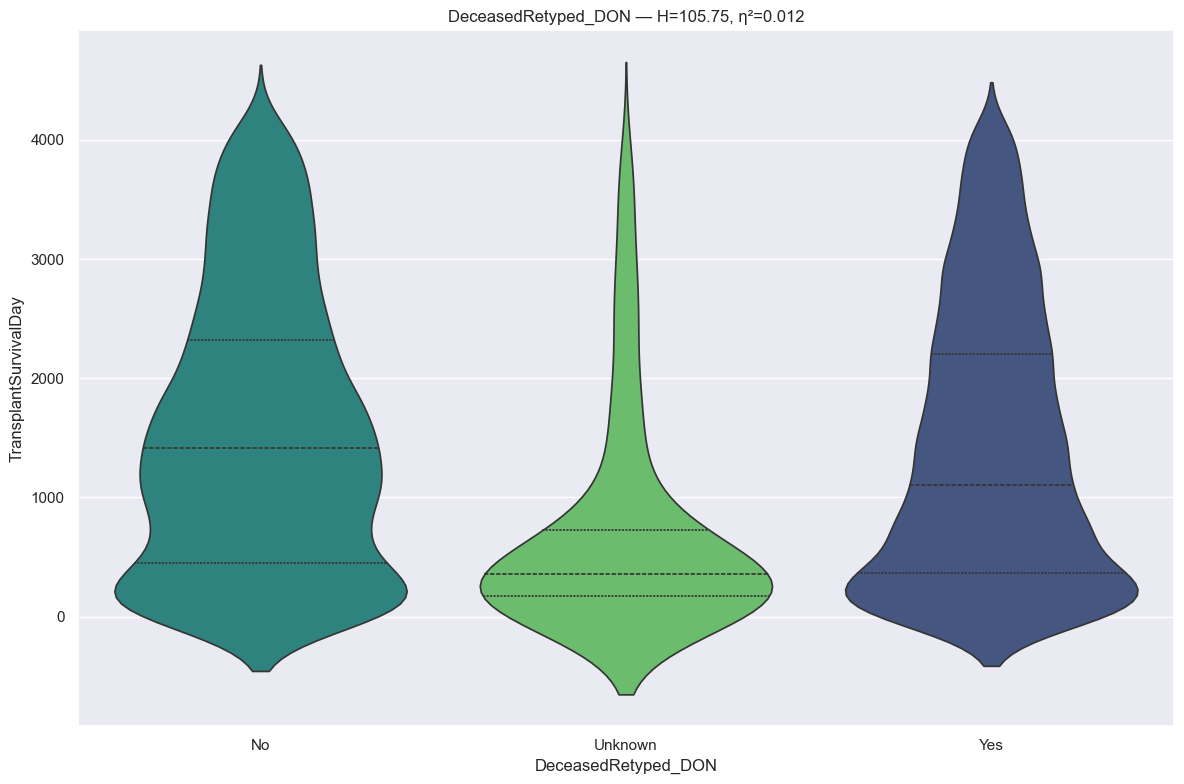

RANKING REPORT: DeceasedRetyped_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3328 records
 * Unknown                                           :    161 records
 * Yes                                               :   5444 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 105.7542 | P-value: 1.085862e-23 | Effect η²: 0.0116
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=3.3091e-22 | thr=0.0167 | r=-0.452 | *Sig*
Unknown      vs Yes          | p=6.8897e-18 | thr=0.0167 | r= 0.398 | *Sig*
No           vs Yes          | p=1.7080e-06 | thr=0.0167 | r=-0.061 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1

In [6]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [7]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DA1
* Donor-Specific Antibodies (DSAs) targeting Human Leukocyte Antigens (HLA) are the primary immunological threat in heart transplantation, often causing antibody-mediated rejection (AMR) and long-term coronary artery vasculopathy. They are detected using Luminex single-antigen bead (SAB) assays, which measure antibody strength (MFI) against donor antigens.

In [8]:
# info
feature = u.get_feature_info(df, 'AntigenDA1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDA1_DON  8933     32   2  3614

:::: NaN Count:
AntigenDA1_DON    0 



{'AntigenDA1_DON': CategoricalDtype(categories=['01:01', '01:02', '02:01', '02:02', '02:03', '02:05',
                   '02:06', '03:01', '03:02', '1', '10', '11', '11:01', '2',
                   '23', '24', '24:02', '24:03', '25', '26', '26:01', '28',
                   '29', '29:02', '3', '30', '30:01', '31', '32', '33', '33:03',
                   '34', '34:02', '36', '66', '66:01', '68', '68:02', '69',
                   '74', 'Unknown'],
 , ordered=False, categories_dtype=object)}

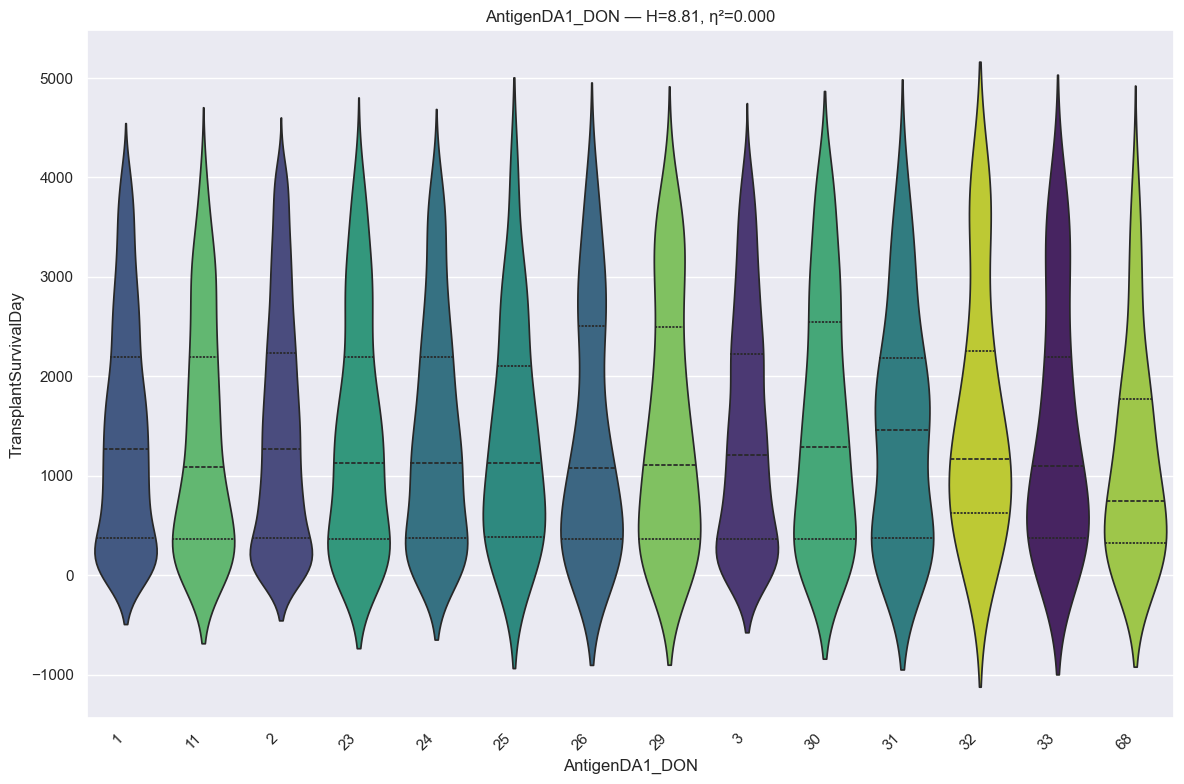

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :   2053 records
 * 11                                                :    411 records
 * 2                                                 :   3614 records
 * 23                                                :    305 records
 * 24                                                :    514 records
 * 25                                                :     62 records
 * 26                                                :    131 records
 * 29                                                :    144 records
 * 3                                                 :   1096 records
 * 30                                                :    205 records
 * 31                                                :     78 records
 * 32                                                :     44 records
 * 33                                                :     89 records
 * 68                        

In [9]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [10]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### AntigenDA2
* Donor-specific antibodies (DSA) directed against HLA class II antigens—specifically HLA-DQ—are a major concern in heart transplantation, often leading to poorer outcomes, increased antibody-mediated rejection (AMR), and cardiac allograft vasculopathy (CAV). These antibodies can be pre-existing or develop de novo (dnDSA) after transplantation. 

In [11]:
# info
feature = u.get_feature_info(df, 'AntigenDA2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDA2_DON  8933     41  24  1022

:::: NaN Count:
AntigenDA2_DON    0 



{'AntigenDA2_DON': CategoricalDtype(categories=['01:01', '02:01', '02:03', '02:05', '02:06', '03:01', '1',
                   '10', '11', '11:01', '2', '23', '24', '24:02', '24:03', '25',
                   '26', '26:01', '28', '29', '29:01', '29:02', '3', '30',
                   '30:01', '30:02', '31', '32', '33', '33:01', '33:03', '34',
                   '34:02', '36', '43', '66', '66:01', '66:02', '68', '68:01',
                   '68:02', '69', '74', '80', 'No Antigen',
                   'No second antigen detected', 'Unknown'],
 , ordered=False, categories_dtype=object)}

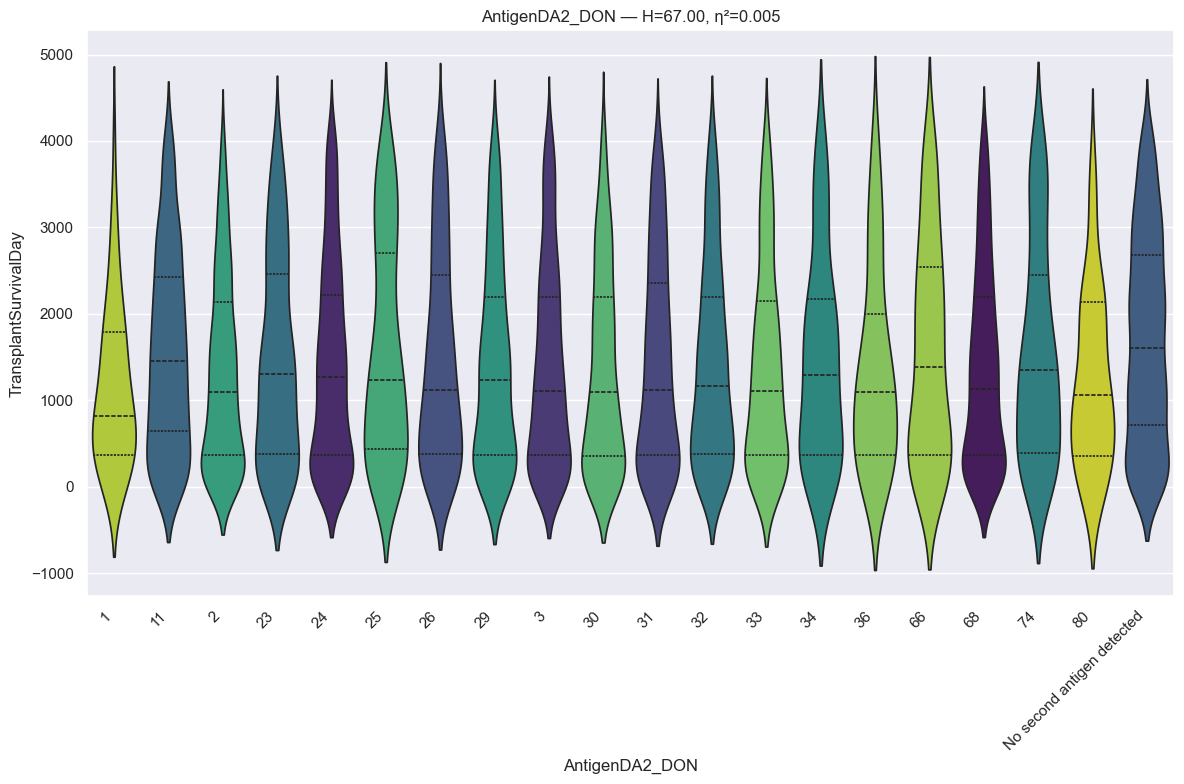

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     60 records
 * 11                                                :    549 records
 * 2                                                 :    880 records
 * 23                                                :    321 records
 * 24                                                :   1022 records
 * 25                                                :    195 records
 * 26                                                :    368 records
 * 29                                                :    476 records
 * 3                                                 :    907 records
 * 30                                                :    539 records
 * 31                                                :    465 records
 * 32                                                :    474 records
 * 33                                                :    386 records
 * 34                        

In [12]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [13]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     60 records
 * 11                                                :    549 records
 * 2                                                 :    880 records
 * 23                                                :    321 records
 * 24                                                :   1022 records
 * 25                                                :    195 records
 * 26                                                :    368 records
 * 29                                                :    476 records
 * 3                                                 :    907 records
 * 30                                                :    539 records
 * 31                                                :    465 records
 * 32                                                :    474 records
 * 33                                                :    386 records
 * 34                        

In [14]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     60 records
 * 11                                                :    549 records
 * 2                                                 :    880 records
 * 23                                                :    321 records
 * 24                                                :   1022 records
 * 25                                                :    195 records
 * 26                                                :    368 records
 * 29                                                :    476 records
 * 3                                                 :    907 records
 * 30                                                :    539 records
 * 31                                                :    465 records
 * 32                                                :    474 records
 * 33                                                :    386 records
 * 34                        

In [15]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

####  Antigen DB1
* Human Leukocyte Antigen (HLA) class I and II antibodies are critical factors in heart transplantation, serving as primary targets for immune-mediated rejection. Sensitization, caused by prior transplants, blood transfusions, or pregnancy, leads to donor-specific antibodies (DSAs). Identifying these antigens using Luminex solid-phase assays (mean fluorescent intensity, or MFI) is crucial for predicting antibody-mediated rejection (AMR) and managing high-risk candidates.

In [16]:
# info
feature = u.get_feature_info(df, 'AntigenDB1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDB1_DON  8933     67   7  1794

:::: NaN Count:
AntigenDB1_DON    0 



{'AntigenDB1_DON': CategoricalDtype(categories=['07:02', '08:01', '13', '13:02', '14', '14:01', '14:02',
                   '15', '15:01', '15:03', '15:07', '15:10', '15:16', '15:17',
                   '15:18', '18', '27', '27:04', '27:05', '35', '35:01',
                   '35:02', '35:03', '35:08', '35:12', '37', '38', '38:01',
                   '39', '39:01', '39:02', '39:06', '40', '40:01', '40:02',
                   '40:05', '40:06', '41', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '49', '50',
                   '50:01', '51', '51:01', '51:02', '52', '53', '54', '55',
                   '55:01', '56', '56:03', '57', '58', '59', '60', '61', '62',
                   '63', '64', '65', '7', '70', '703', '71', '72', '75', '76',
                   '77', '78', '8', '81', '82', 'Unknown'],
 , ordered=False, categories_dtype=object)}

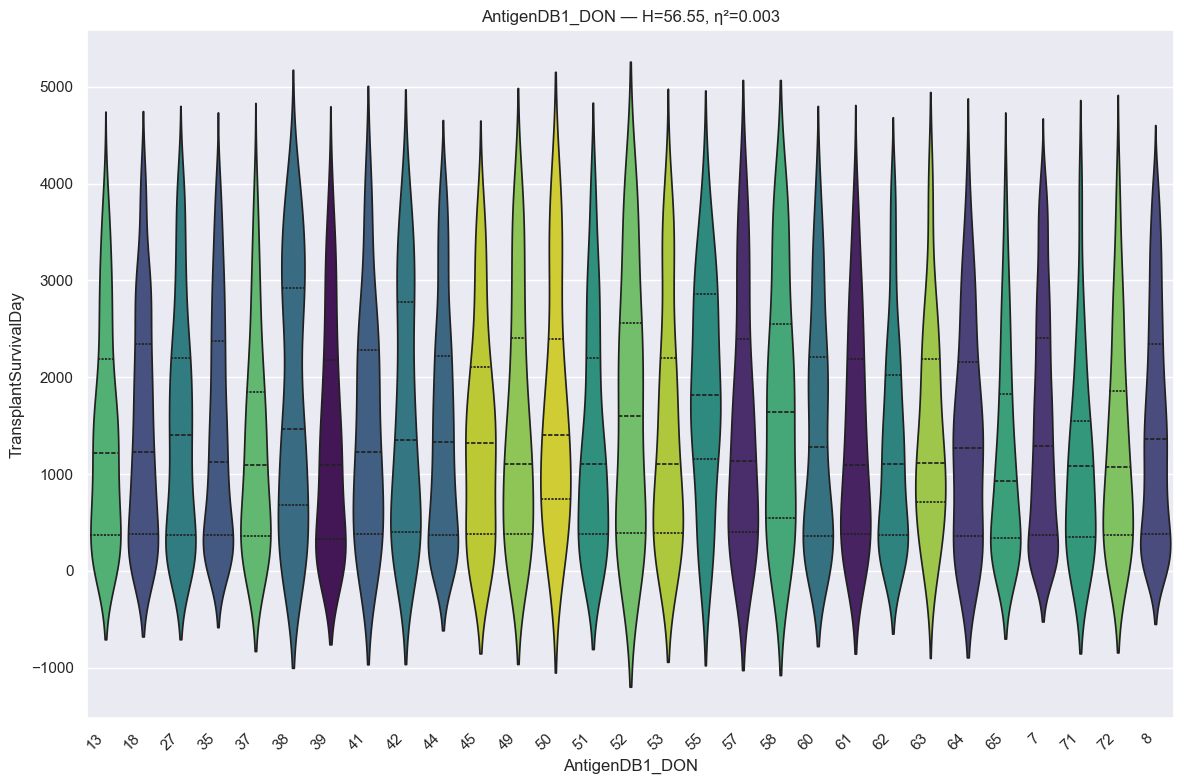

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    287 records
 * 18                                                :    453 records
 * 27                                                :    390 records
 * 35                                                :    985 records
 * 37                                                :    109 records
 * 38                                                :    130 records
 * 39                                                :    244 records
 * 41                                                :     72 records
 * 42                                                :    115 records
 * 44                                                :    787 records
 * 45                                                :    103 records
 * 49                                                :     97 records
 * 50                                                :     43 records
 * 51                        

In [17]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [18]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    287 records
 * 18                                                :    453 records
 * 27                                                :    390 records
 * 35                                                :    985 records
 * 37                                                :    109 records
 * 38                                                :    130 records
 * 39                                                :    244 records
 * 41                                                :     72 records
 * 42                                                :    115 records
 * 44                                                :    787 records
 * 45                                                :    103 records
 * 49                                                :     97 records
 * 50                                                :     43 records
 * 51                        

In [19]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    287 records
 * 18                                                :    453 records
 * 27                                                :    390 records
 * 35                                                :    985 records
 * 37                                                :    109 records
 * 38                                                :    130 records
 * 39                                                :    244 records
 * 41                                                :     72 records
 * 42                                                :    115 records
 * 44                                                :    787 records
 * 45                                                :    103 records
 * 49                                                :     97 records
 * 50                                                :     43 records
 * 51                        

In [20]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DB2
* The presence of pre-existing antibodies (sensitization) against Human Leukocyte Antigens (HLA) poses a major challenge in heart transplantation, as these antibodies can lead to antibody-mediated rejection (AMR) and donor-specific antibodies (DSA). The "Antigen DB 2" likely refers to the management of HLA class II antibodies (like HLA-DR), which are critical to evaluate, particularly in high-risk patients.

In [21]:
# info
feature = u.get_feature_info(df, 'AntigenDB2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDB2_DON  8933     76  44  1284

:::: NaN Count:
AntigenDB2_DON    0 



{'AntigenDB2_DON': CategoricalDtype(categories=['07:02', '08:01', '12', '13', '13:02', '14', '14:01',
                   '14:02', '15', '15:01', '15:10', '15:16', '15:17', '17',
                   '18', '22', '27', '27:05', '27:08', '35', '35:01', '35:02',
                   '35:03', '35:08', '35:12', '37', '38', '38:01', '39',
                   '39:01', '39:02', '39:05', '39:06', '40', '40:01', '40:02',
                   '40:05', '41', '41:01', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '48:01',
                   '49', '50', '50:01', '51', '51:01', '51:02', '52', '53',
                   '54', '55', '55:01', '56', '56:01', '57', '57:01', '57:03',
                   '58', '59', '60', '61', '62', '63', '64', '65', '67', '7',
                   '70', '71', '72', '73', '75', '76', '77', '78', '8', '81',
                   '82', '82:01', 'No second antigen detected', 'Unknown'],
 , ordered=False, categories_dtype=object)}

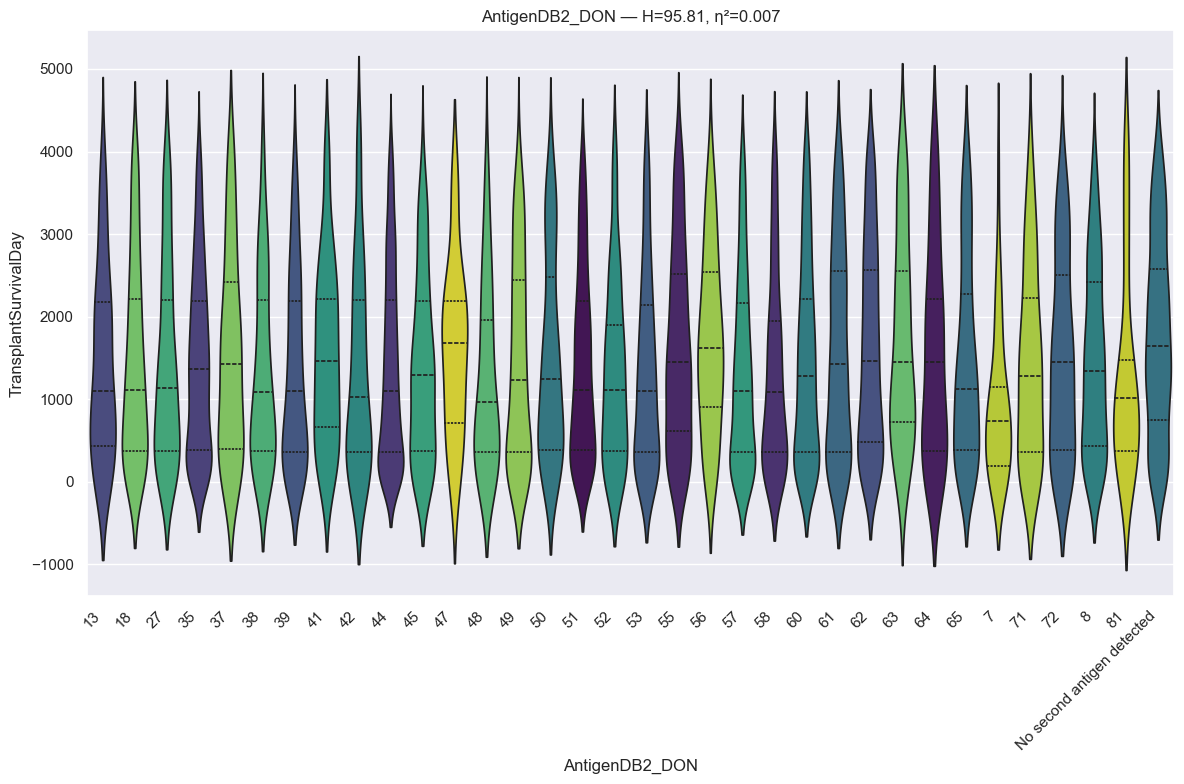

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :     71 records
 * 18                                                :    223 records
 * 27                                                :    204 records
 * 35                                                :    609 records
 * 37                                                :    100 records
 * 38                                                :    133 records
 * 39                                                :    224 records
 * 41                                                :    112 records
 * 42                                                :     80 records
 * 44                                                :   1284 records
 * 45                                                :    168 records
 * 47                                                :     39 records
 * 48                                                :     79 records
 * 49                        

In [22]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [23]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :     71 records
 * 18                                                :    223 records
 * 27                                                :    204 records
 * 35                                                :    609 records
 * 37                                                :    100 records
 * 38                                                :    133 records
 * 39                                                :    224 records
 * 41                                                :    112 records
 * 42                                                :     80 records
 * 44                                                :   1284 records
 * 45                                                :    168 records
 * 47                                                :     39 records
 * 48                                                :     79 records
 * 49                        

In [24]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DR1
* HLA-DR antigen matching is crucial in heart transplantation, as mismatches (particularly HLA-DRB1) are associated with increased risk of mortality, antibody-mediated rejection, and chronic cardiac allograft vasculopathy. Minimizing HLA-DR mismatches improves survival and reduces the incidence of rejection episodes.

In [25]:
# info
feature = u.get_feature_info(df, 'AntigenDDR1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDDR1_DON  8933     36   4  2170

:::: NaN Count:
AntigenDDR1_DON    0 



{'AntigenDDR1_DON': CategoricalDtype(categories=['01:01', '01:02', '01:03', '03:01', '03:02', '04:01',
                   '04:02', '04:03', '04:04', '04:05', '04:07', '04:11',
                   '08:01', '08:02', '09:01', '1', '10', '103', '11', '11:01',
                   '11:03', '11:04', '12', '12:01', '13', '13:01', '13:02',
                   '13:03', '13:05', '14', '14:02', '14:04', '14:54', '15',
                   '15:01', '16', '17', '18', '3', '4', '7', '8', '9',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

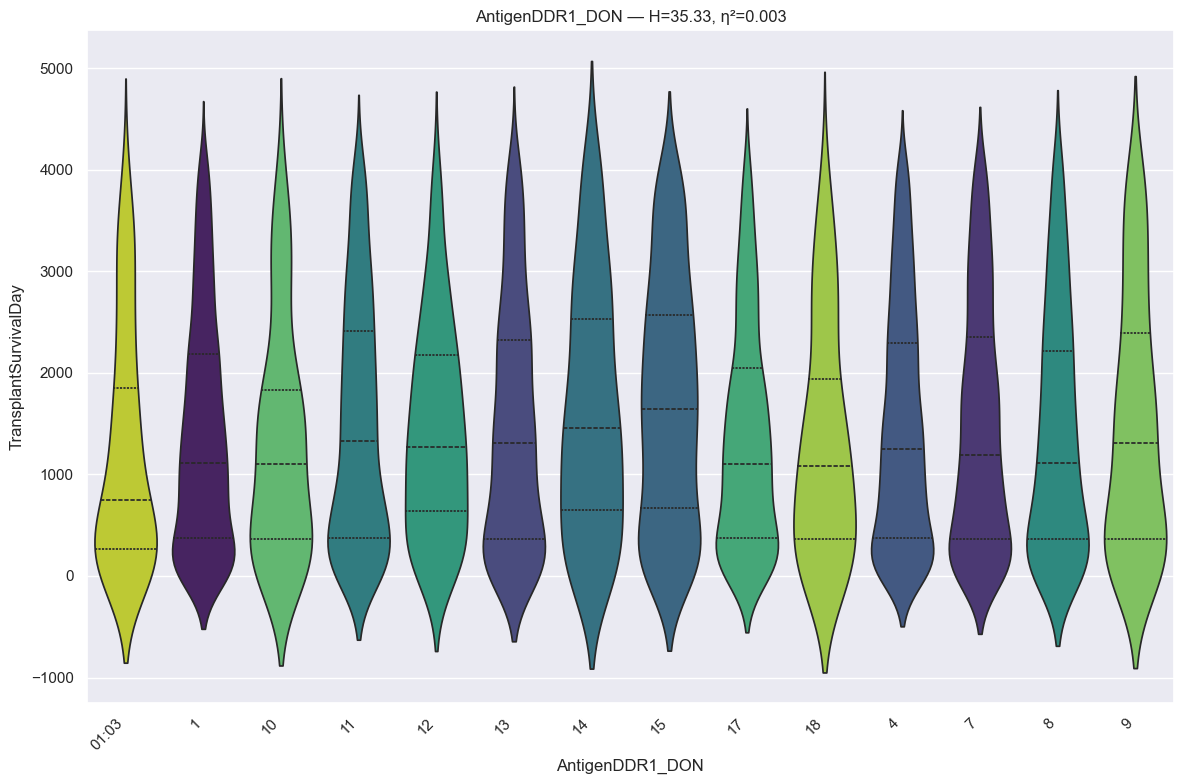

RANKING REPORT: AntigenDDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    150 records
 * 1                                                 :   1514 records
 * 10                                                :    107 records
 * 11                                                :    749 records
 * 12                                                :    152 records
 * 13                                                :    690 records
 * 14                                                :    127 records
 * 15                                                :    380 records
 * 17                                                :    891 records
 * 18                                                :     76 records
 * 4                                                 :   2170 records
 * 7                                                 :   1221 records
 * 8                                                 :    455 records
 * 9                        

In [26]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [27]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    150 records
 * 1                                                 :   1514 records
 * 10                                                :    107 records
 * 11                                                :    749 records
 * 12                                                :    152 records
 * 13                                                :    690 records
 * 14                                                :    127 records
 * 15                                                :    380 records
 * 17                                                :    891 records
 * 18                                                :     76 records
 * 4                                                 :   2170 records
 * 7                                                 :   1221 records
 * 8                                                 :    455 records
 * 9                        

In [28]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DR2
* HLA-DR2 (a component of HLA class II) antigen status can influence heart transplant outcomes by acting as a marker for sensitization or increased immune reactivity, potentially leading to poorer graft survival, particularly if mismatched. While HLA-DQ is often cited as a more critical target for chronic rejection, DR mismatches are associated with increased cardiac allograft vasculopathy (CAV). 

In [29]:
# info
feature = u.get_feature_info(df, 'AntigenDDR2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDDR2_DON  8933     38  15  1805

:::: NaN Count:
AntigenDDR2_DON    0 



{'AntigenDDR2_DON': CategoricalDtype(categories=['01:01', '01:03', '03:01', '04:01', '04:04', '04:05',
                   '04:07', '08:01', '08:02', '09:01', '1', '10', '103', '11',
                   '11:01', '11:03', '11:04', '12', '12:01', '12:02', '13',
                   '13:01', '13:02', '13:03', '13:05', '14', '14:01', '14:02',
                   '14:04', '14:06', '14:54', '15', '15:01', '15:02', '15:03',
                   '16', '16:01', '16:02', '17', '18', '3', '4', '5', '7', '8',
                   '9', 'No second antigen detected', 'Unknown'],
 , ordered=False, categories_dtype=object)}

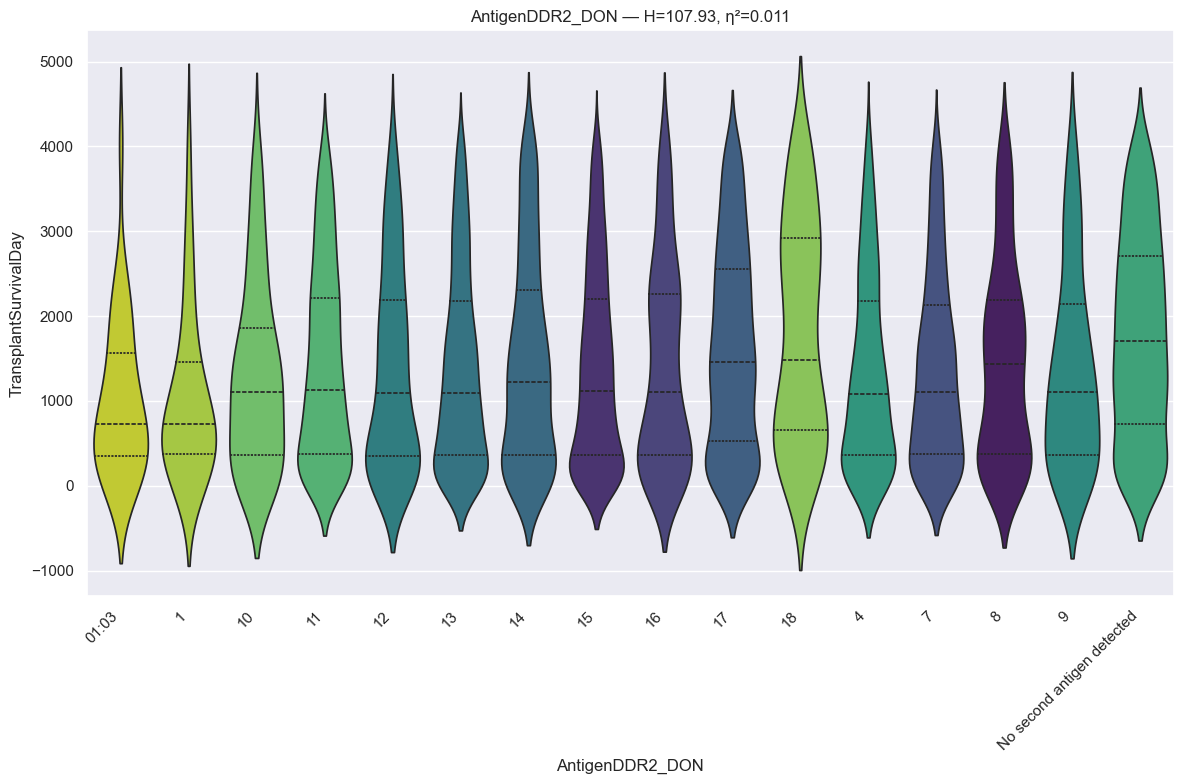

RANKING REPORT: AntigenDDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :     31 records
 * 1                                                 :     35 records
 * 10                                                :    107 records
 * 11                                                :    883 records
 * 12                                                :    236 records
 * 13                                                :   1443 records
 * 14                                                :    500 records
 * 15                                                :   1805 records
 * 16                                                :    283 records
 * 17                                                :    893 records
 * 18                                                :    115 records
 * 4                                                 :    625 records
 * 7                                                 :    772 records
 * 8                        

In [30]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [31]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :     31 records
 * 1                                                 :     35 records
 * 10                                                :    107 records
 * 11                                                :    883 records
 * 12                                                :    236 records
 * 13                                                :   1443 records
 * 14                                                :    500 records
 * 15                                                :   1805 records
 * 16                                                :    283 records
 * 17                                                :    893 records
 * 18                                                :    115 records
 * 4                                                 :    625 records
 * 7                                                 :    772 records
 * 8                        

In [32]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Citizenship

In [33]:
# info
feature = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique         top  freq
Citizenship_DON  8933      6  US Citizen  8251

:::: NaN Count:
Citizenship_DON    0 



{'Citizenship_DON': CategoricalDtype(categories=['NON-RESIDENT ALIEN',
                   'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant',
                   'Non-US Citizen/US Resident', 'RESIDENT ALIEN', 'US Citizen',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

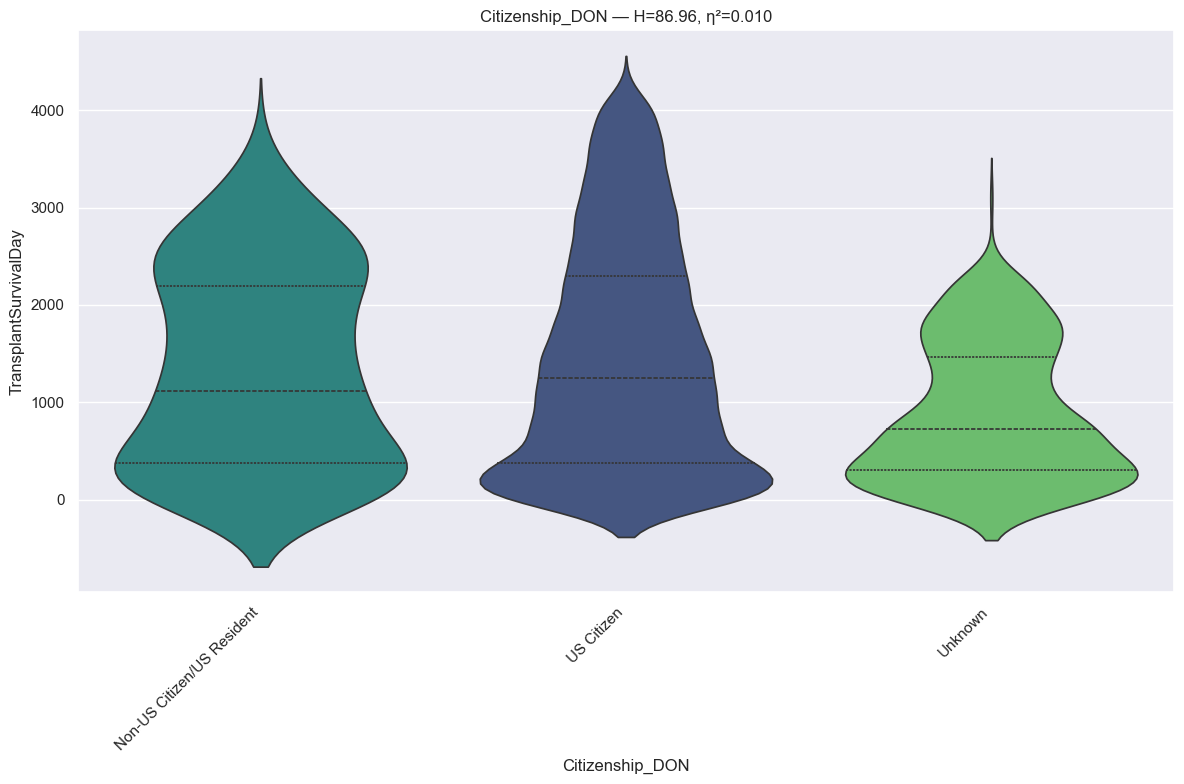

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Non-US Citizen/US Resident                        :    219 records
 * US Citizen                                        :   8251 records
 * Unknown                                           :    409 records
BYPASSED CATEGORIES (n < min_n):
 * NON-RESIDENT ALIEN                                :      7 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     22 records
 * RESIDENT ALIEN                                    :     25 records
--------------------------------------------------------------------------------
Kruskal H: 86.9593 | P-value: 1.309268e-19 | Effect η²: 0.0096
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
US Citizen   vs Unknown      | p=1.4938e-20 | thr=0.0167 | r=-0.272 | *Sig*
Non-US Citizen/US Resident vs Unknown      | p=3.2949e-08 | t

In [34]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [35]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Non-US Citizen/US Resident                        :    219 records
 * US Citizen                                        :   8251 records
 * Unknown                                           :    409 records
BYPASSED CATEGORIES (n < min_n):
 * NON-RESIDENT ALIEN                                :      7 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     22 records
 * RESIDENT ALIEN                                    :     25 records
--------------------------------------------------------------------------------
Kruskal H: 86.9593 | P-value: 1.309268e-19 | Effect η²: 0.0096
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED 

In [36]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Past Cocaine Use

In [37]:
# info
feature = u.get_feature_info(df, 'PastCocaineUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top  freq
PastCocaineUse_DON  8933      3  No  7111

:::: NaN Count:
PastCocaineUse_DON    0 



{'PastCocaineUse_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

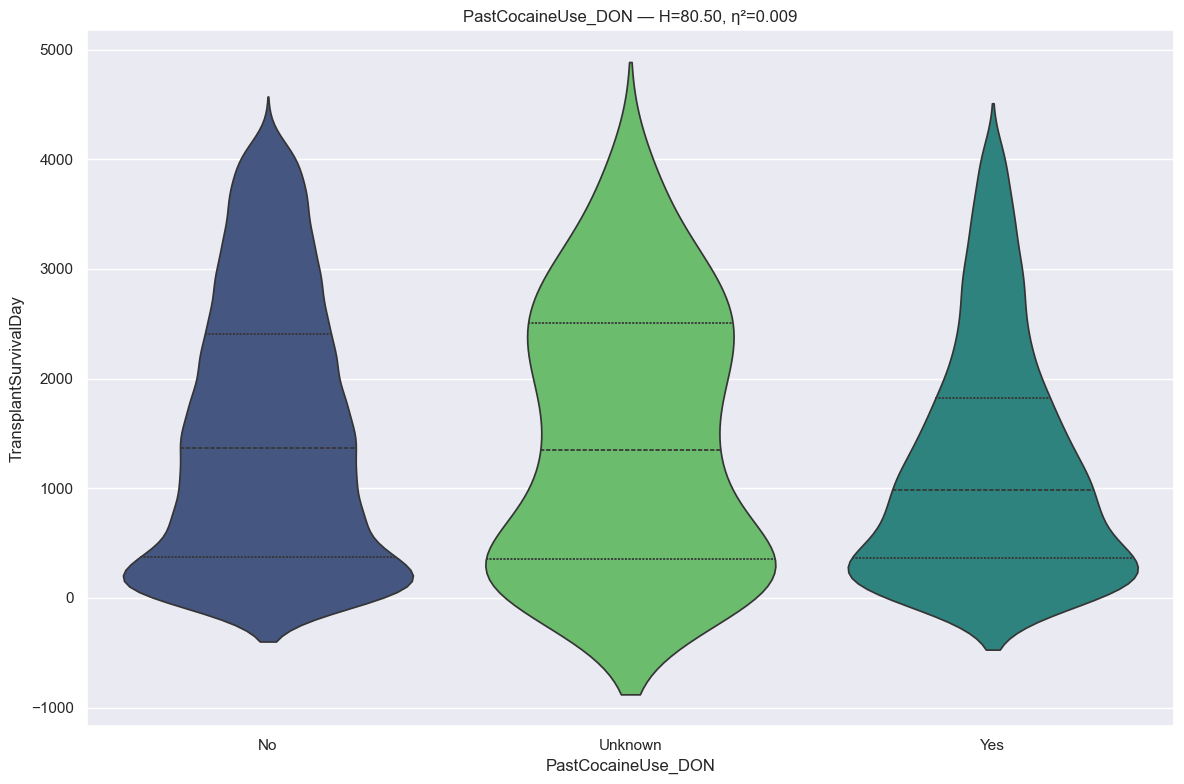

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7111 records
 * Unknown                                           :    140 records
 * Yes                                               :   1682 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 80.5044 | P-value: 3.301407e-18 | Effect η²: 0.0088
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.6918e-19 | thr=0.0167 | r=-0.141 | *Sig*
Unknown      vs Yes          | p=3.1289e-02 | thr=0.0167 | r=-0.109 | Not Sig
No           vs Unknown      | p=6.4315e-01 | thr=0.0167 | r=-0.023 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group

In [38]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [39]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7111 records
 * Unknown                                           :    140 records
 * Yes                                               :   1682 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 80.5044 | P-value: 3.301407e-18 | Effect η²: 0.0088
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Group_2 (1 categories)
  - Yes



In [40]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Ethnicity

In [41]:
# info
feature = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique                  top  freq
Ethnicity_DON  8933      7  White, Non-Hispanic  6028

:::: NaN Count:
Ethnicity_DON    0 



{'Ethnicity_DON': CategoricalDtype(categories=['Amer Ind/Alaska Native', 'Asian', 'Black', 'Hispanic',
                   'Multiracial', 'Native Hawaiian/other Pacific Islander',
                   'White, Non-Hispanic'],
 , ordered=False, categories_dtype=object)}

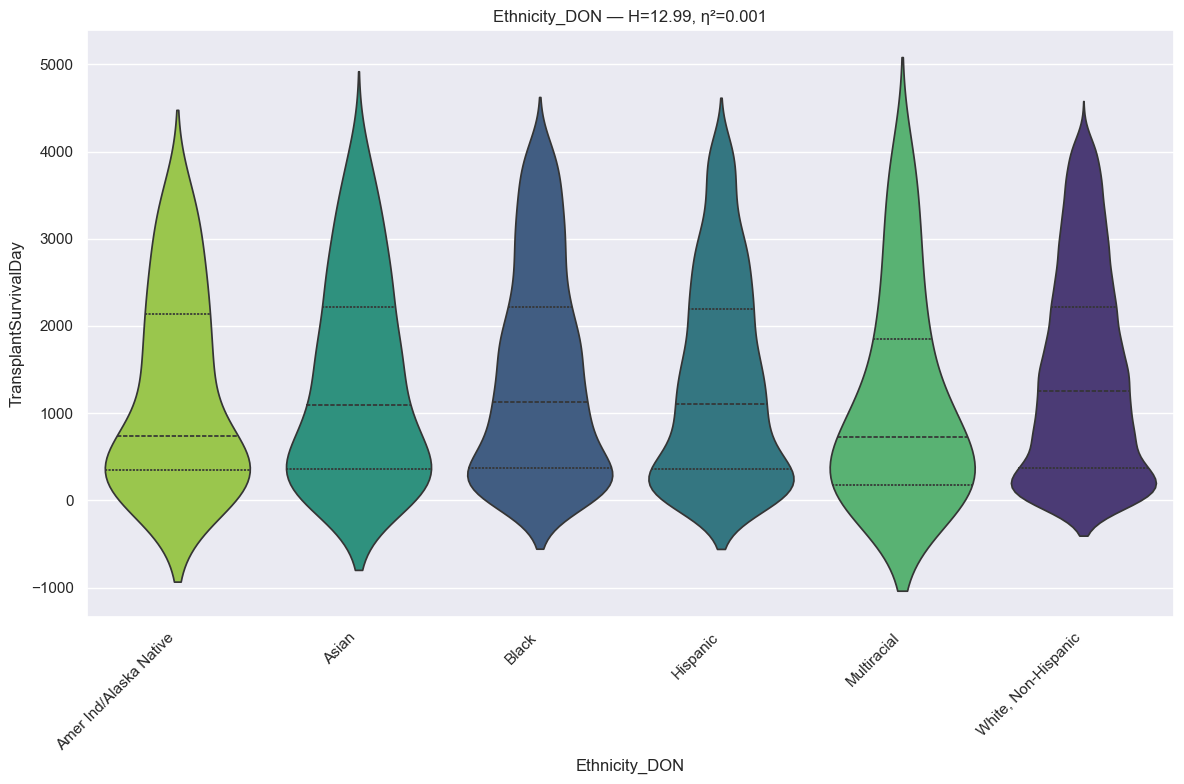

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :     70 records
 * Asian                                             :    193 records
 * Black                                             :   1356 records
 * Hispanic                                          :   1208 records
 * Multiracial                                       :     61 records
 * White, Non-Hispanic                               :   6028 records
BYPASSED CATEGORIES (n < min_n):
 * Native Hawaiian/other Pacific Islander            :     17 records
--------------------------------------------------------------------------------
Kruskal H: 12.9869 | P-value: 2.350212e-02 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Multiracial  vs White, Non-Hispanic | p=1.5874e-02 | thr=0.0033 | r= 0.179 | Not Sig
Black        

In [42]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [43]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :     70 records
 * Asian                                             :    193 records
 * Black                                             :   1356 records
 * Hispanic                                          :   1208 records
 * Multiracial                                       :     61 records
 * White, Non-Hispanic                               :   6028 records
BYPASSED CATEGORIES (n < min_n):
 * Native Hawaiian/other Pacific Islander            :     17 records
--------------------------------------------------------------------------------
Kruskal H: 12.9869 | P-value: 2.350212e-02 | Effect η²: 0.0009
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

::

In [44]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Hepatitis B Core Antibody
* A positive Hepatitis B core antibody (HBcAb or anti-HBc) test indicates exposure to the hepatitis B virus (HBV), either from a current or past infection. Unlike surface antibodies, it does not provide immunity. It is a critical marker for diagnosing acute, chronic, or resolved hepatitis B. 

In [45]:
# info
feature = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                             count unique       top  freq
Hepatitis_B_CoreAntibody_DON  8933      3  Negative  8744

:::: NaN Count:
Hepatitis_B_CoreAntibody_DON    0 



{'Hepatitis_B_CoreAntibody_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

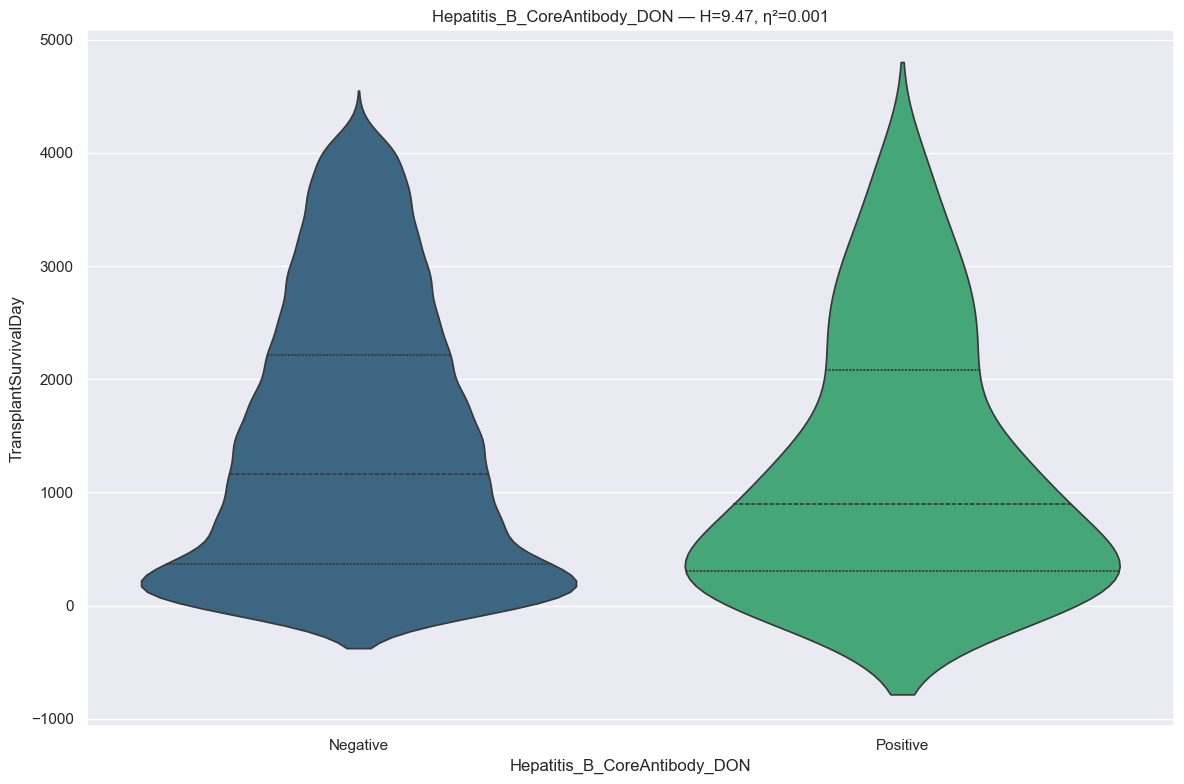

RANKING REPORT: Hepatitis_B_CoreAntibody_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8744 records
 * Positive                                          :    184 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      5 records
--------------------------------------------------------------------------------
Kruskal H: 9.4669 | P-value: 2.092120e-03 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=2.0922e-03 | thr=0.0500 | r=-0.132 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

>>> Group_2 (1 categories)
  - Positive

>>> Other (1 categories)
  - Not Done

Hepatitis_B_CoreAntibody_DON

In [46]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [47]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Surface Antigen HEP B
* Hepatitis B surface antigen (HBsAg) is a protein on the surface of the hepatitis B virus (HBV) used to detect active infections. A positive or "reactive" result indicates acute or chronic HBV infection, meaning the person is infectious. It appears 6-16 weeks after exposure; persistence beyond 6 months indicates chronic infection.

In [48]:
# info
feature = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique       top  freq
SurfaceAntigenHEP_B_DON  8933      4  Negative  8916

:::: NaN Count:
SurfaceAntigenHEP_B_DON    0 



{'SurfaceAntigenHEP_B_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Positive',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

In [49]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

[WARNING] Cannot perform statistical comparison for SurfaceAntigenHEP_B_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

SurfaceAntigenHEP_B_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Negative         1440.579969                1145.0                 4174.0                    0.0          8916
               Positive          690.428571                 653.0                 1780.0                   45.0             7
               Not Done         1151.000000                 935.5                 2556.0                  365.0             6
                Unknown         1527.500000                1327.5                 3093.0                  362.0             4


In [50]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** Unable to determine statistical significance due to small sample size, removing this feature is reasonable due to its extreme sparsity and imbalance.

#### Blood Group

In [51]:
# info
feature = u.get_feature_info(df, 'BloodGroup_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
BloodGroup_DON  8933      8   O  4717

:::: NaN Count:
BloodGroup_DON    0 



{'BloodGroup_DON': CategoricalDtype(categories=['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O'], ordered=False, categories_dtype=object)}

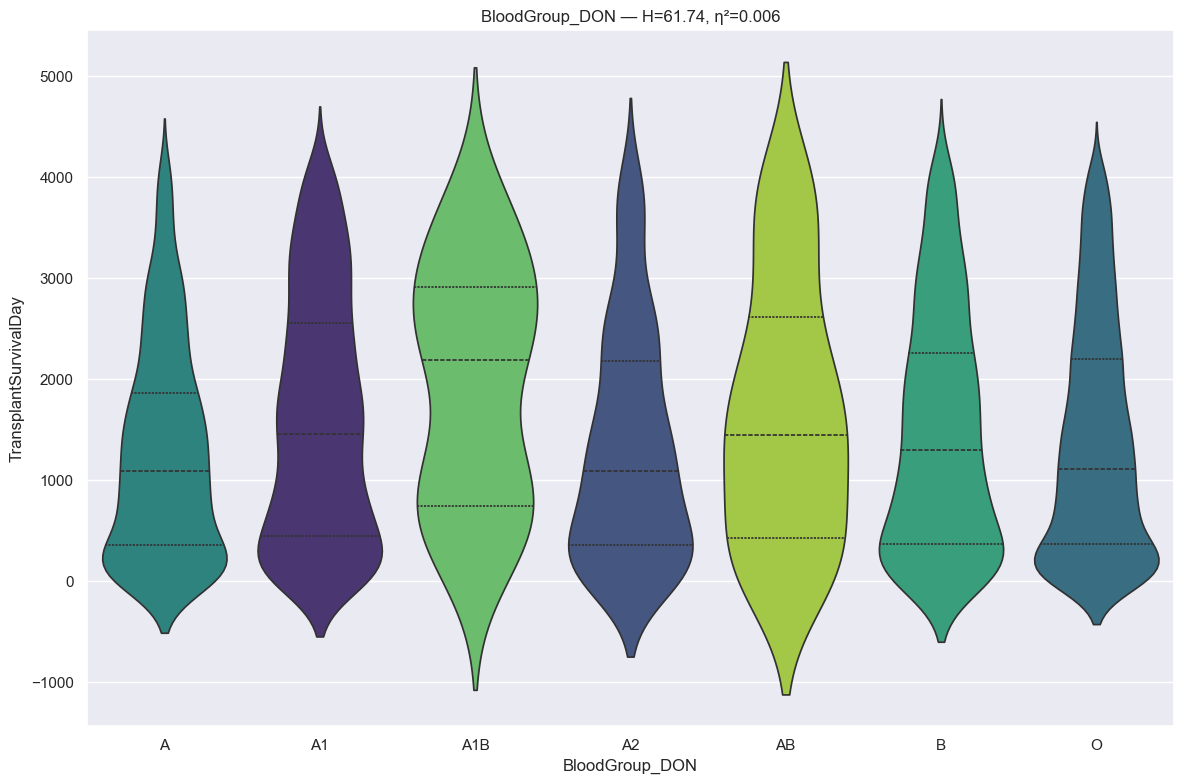

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   1234 records
 * A1                                                :   1685 records
 * A1B                                               :     41 records
 * A2                                                :    263 records
 * AB                                                :     63 records
 * B                                                 :    912 records
 * O                                                 :   4717 records
BYPASSED CATEGORIES (n < min_n):
 * A2B                                               :     18 records
--------------------------------------------------------------------------------
Kruskal H: 61.7401 | P-value: 1.992868e-11 | Effect η²: 0.0063
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
A            vs A1         

In [52]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [53]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   1234 records
 * A1                                                :   1685 records
 * A1B                                               :     41 records
 * A2                                                :    263 records
 * AB                                                :     63 records
 * B                                                 :    912 records
 * O                                                 :   4717 records
BYPASSED CATEGORIES (n < min_n):
 * A2B                                               :     18 records
--------------------------------------------------------------------------------
Kruskal H: 61.7401 | P-value: 1.992868e-11 | Effect η²: 0.0063
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output 

In [54]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Heavy Alcohol Use

In [55]:
# info
feature = u.get_feature_info(df, 'HeavyAlcoholUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
HeavyAlcoholUse_DON  8933      3  No  7702

:::: NaN Count:
HeavyAlcoholUse_DON    0 



{'HeavyAlcoholUse_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

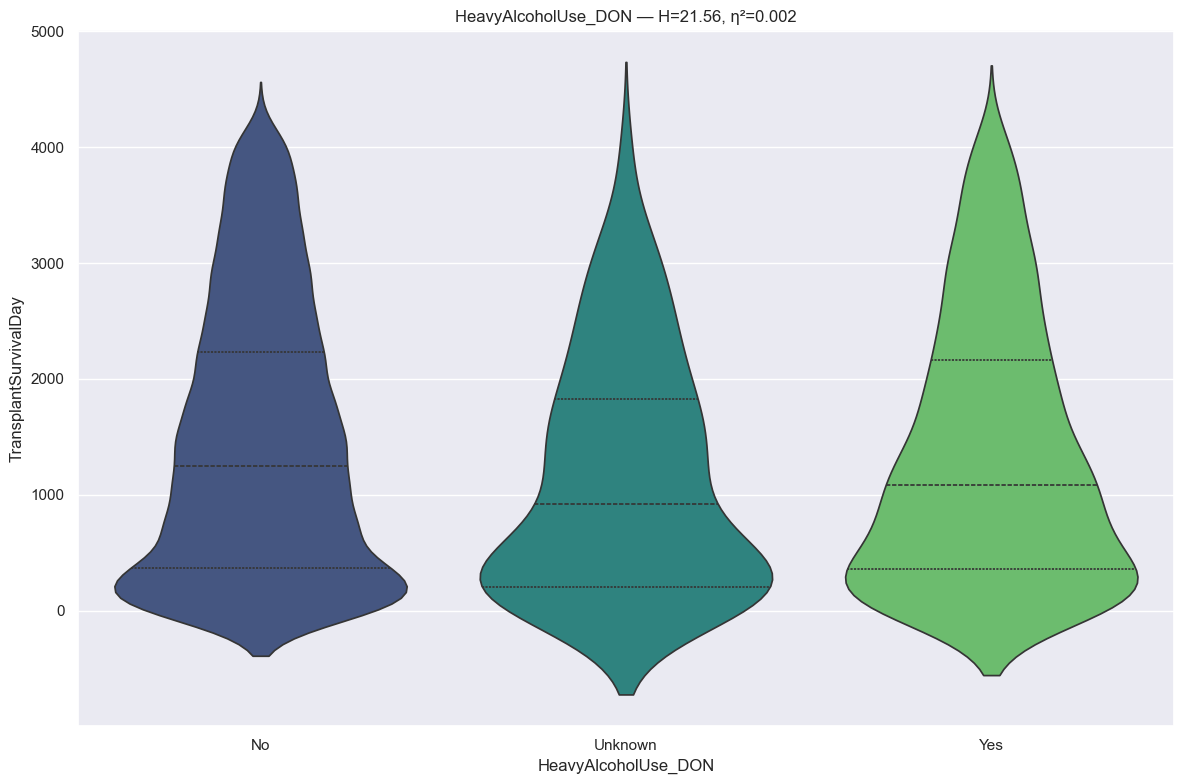

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7702 records
 * Unknown                                           :    178 records
 * Yes                                               :   1053 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 21.5642 | P-value: 2.076800e-05 | Effect η²: 0.0022
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.2410e-04 | thr=0.0167 | r=-0.066 | *Sig*
No           vs Unknown      | p=1.1010e-03 | thr=0.0167 | r=-0.143 | *Sig*
Unknown      vs Yes          | p=9.6270e-02 | thr=0.0167 | r= 0.078 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_

In [56]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [57]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7702 records
 * Unknown                                           :    178 records
 * Yes                                               :   1053 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 21.5642 | P-value: 2.076800e-05 | Effect η²: 0.0022
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Unknown

>>> Group_3 (1 categories)
  - Yes



In [58]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Deceased Or Living

In [59]:
# info
feature = u.get_feature_info(df, 'DeceasedOrLiving_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique             top  freq
DeceasedOrLiving_DON  8933      2  Deceased Donor  8932

:::: NaN Count:
DeceasedOrLiving_DON    0 



{'DeceasedOrLiving_DON': CategoricalDtype(categories=['Deceased Donor', 'Living Donor'], ordered=False, categories_dtype=object)}

In [60]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

[WARNING] Cannot perform statistical comparison for DeceasedOrLiving_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Deceased Donor

DeceasedOrLiving_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
      Deceased Donor         1439.793215                1143.5                 4174.0                    0.0          8932
        Living Donor         1827.000000                1827.0                 1827.0                 1827.0             1


In [61]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** Unable to determine statistical significance due to small sample size, removing this feature is reasonable due to its extreme sparsity and imbalance.

#### Gender

In [62]:
# add to remove list
remove_cols.extend(['Gender_DON'])

#### Residency State

In [63]:
# info
feature = u.get_feature_info(df, 'ResidencyState', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top freq
ResidencyState_DON  8933     54  CA  809

:::: NaN Count:
ResidencyState_DON    0 



{'ResidencyState_DON': CategoricalDtype(categories=['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE',
                   'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
                   'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND',
                   'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
                   'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'Unknown', 'VA',
                   'VT', 'WA', 'WI', 'WV', 'WY', 'ZZ'],
 , ordered=False, categories_dtype=object)}

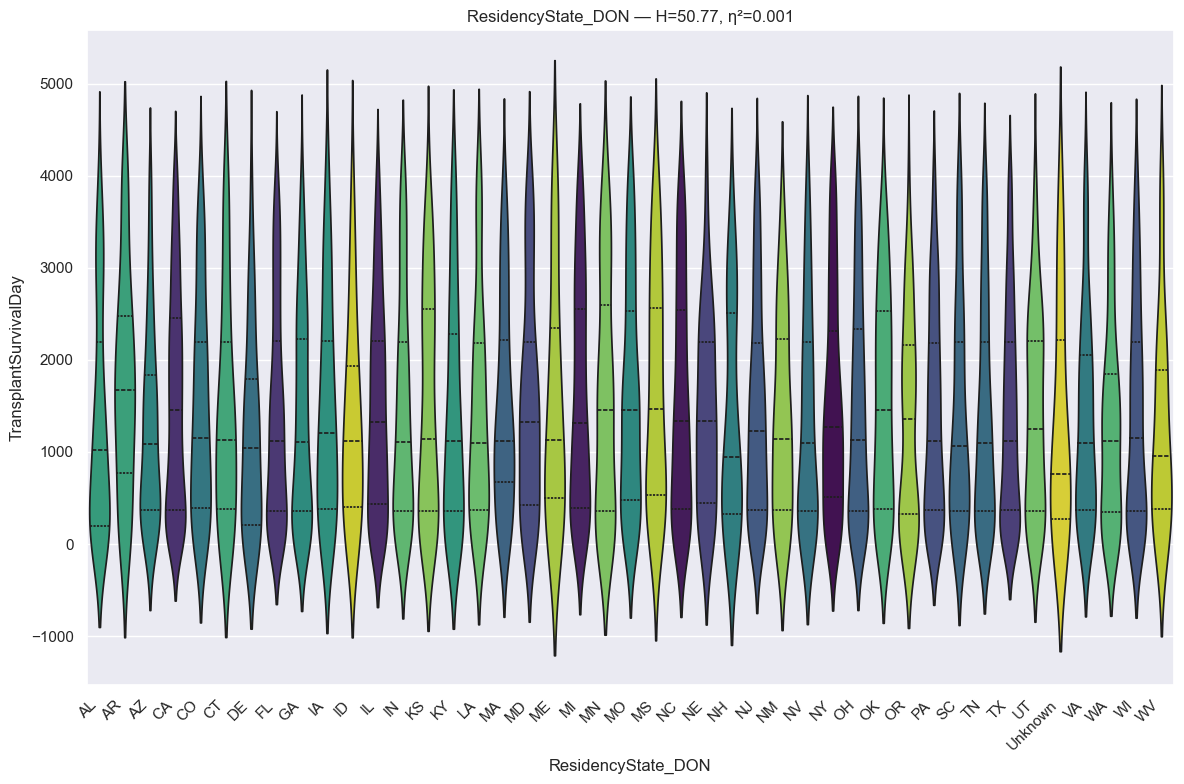

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AL                                                :    141 records
 * AR                                                :     66 records
 * AZ                                                :    206 records
 * CA                                                :    809 records
 * CO                                                :    141 records
 * CT                                                :     71 records
 * DE                                                :     61 records
 * FL                                                :    574 records
 * GA                                                :    299 records
 * IA                                                :     78 records
 * ID                                                :     44 records
 * IL                                                :    369 records
 * IN                                                :    233 records
 * KS                    

In [64]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [65]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Antibody HEP C
* Research shows that getting a kidney from a hepatitis C-positive donor does not lower a patient's or the kidney's survival for up to ten years after transplant. However, there may still be some risk, especially if the donor's virus type differs from the patients.'

In [66]:
# info
feature = u.get_feature_info(df, 'Antibody_HEP_C', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
Antibody_HEP_C_DON  8933      4  Negative  8486

:::: NaN Count:
Antibody_HEP_C_DON    0 



{'Antibody_HEP_C_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

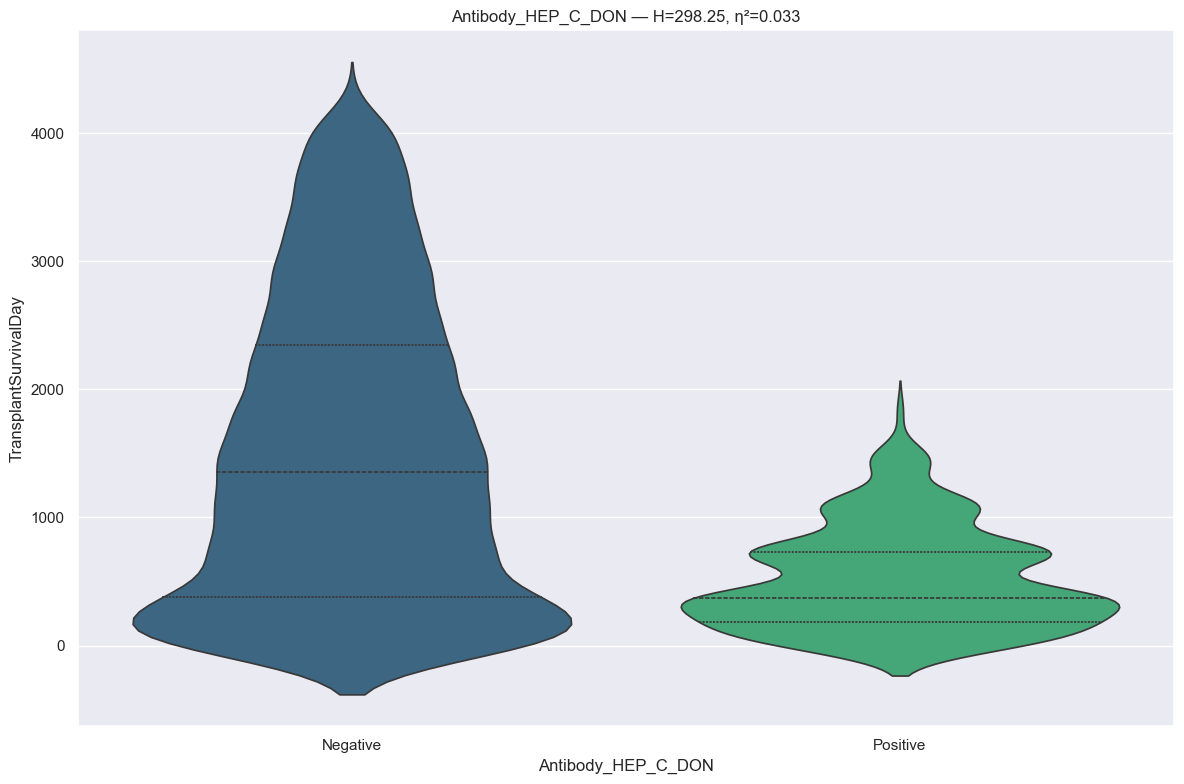

RANKING REPORT: Antibody_HEP_C_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8486 records
 * Positive                                          :    445 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      1 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 298.2501 | P-value: 7.925267e-67 | Effect η²: 0.0333
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=7.9266e-67 | thr=0.0500 | r=-0.485 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

>>> Group_2 (1 categories)
  - Positive

>>> O

In [67]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [68]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Non Heart Beating

In [69]:
# info
feature = u.get_feature_info(df, 'NonHeartBeating', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
NonHeartBeating_DON  8933      3  No  8896

:::: NaN Count:
NonHeartBeating_DON    0 



{'NonHeartBeating_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

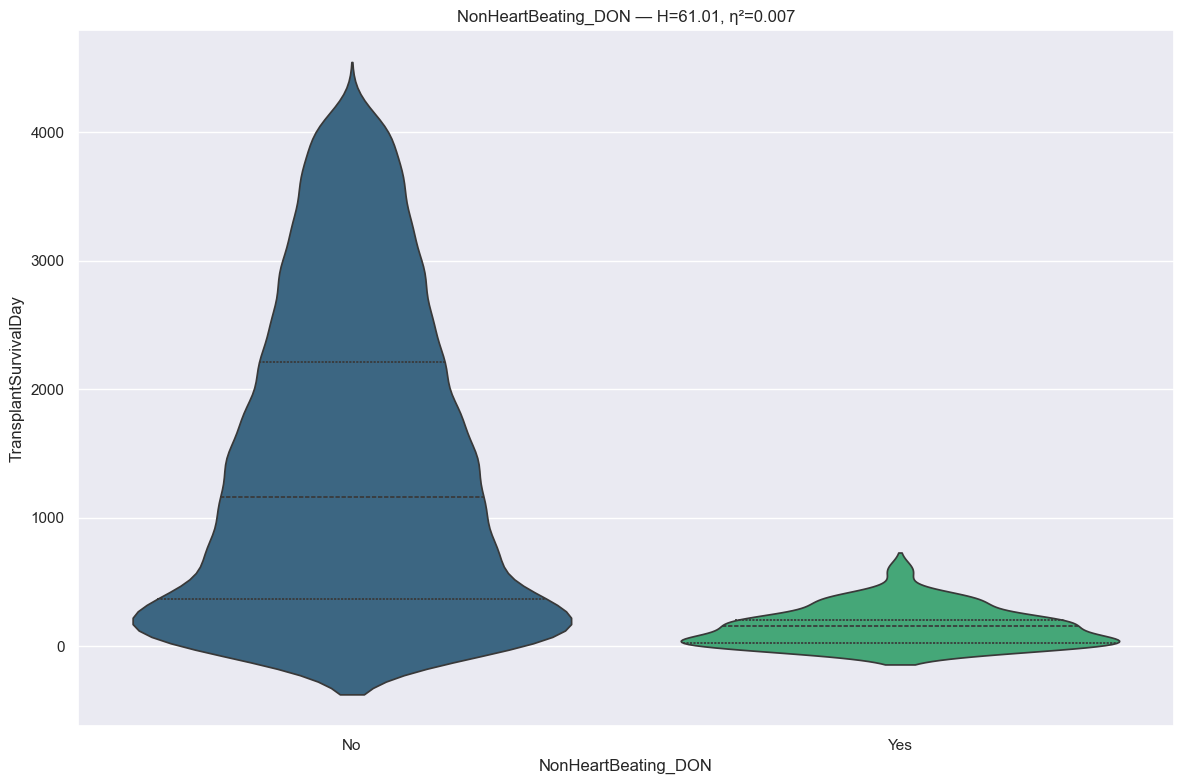

RANKING REPORT: NonHeartBeating_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8896 records
 * Yes                                               :     36 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 61.0094 | P-value: 5.680335e-15 | Effect η²: 0.0067
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.6818e-15 | thr=0.0500 | r=-0.753 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

NonHeartBeating_DON  mean_survival_days  median_

In [70]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [71]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Anti-Hypertensive
* Antihypertensives are medications designed to lower high blood pressure (hypertension), reducing the risk of stroke, heart failure, and kidney disease. Common types include diuretics, ACE inhibitors, ARBs, and calcium channel blockers. They function by widening vessels, slowing heart rate, or removing excess salt/fluid. Common side effects include fatigue, dizziness, and headache. 

In [72]:
# info
feature = u.get_feature_info(df, 'AntiHypertensive_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
AntiHypertensive_DON  8933      3  No  5942

:::: NaN Count:
AntiHypertensive_DON    0 



{'AntiHypertensive_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

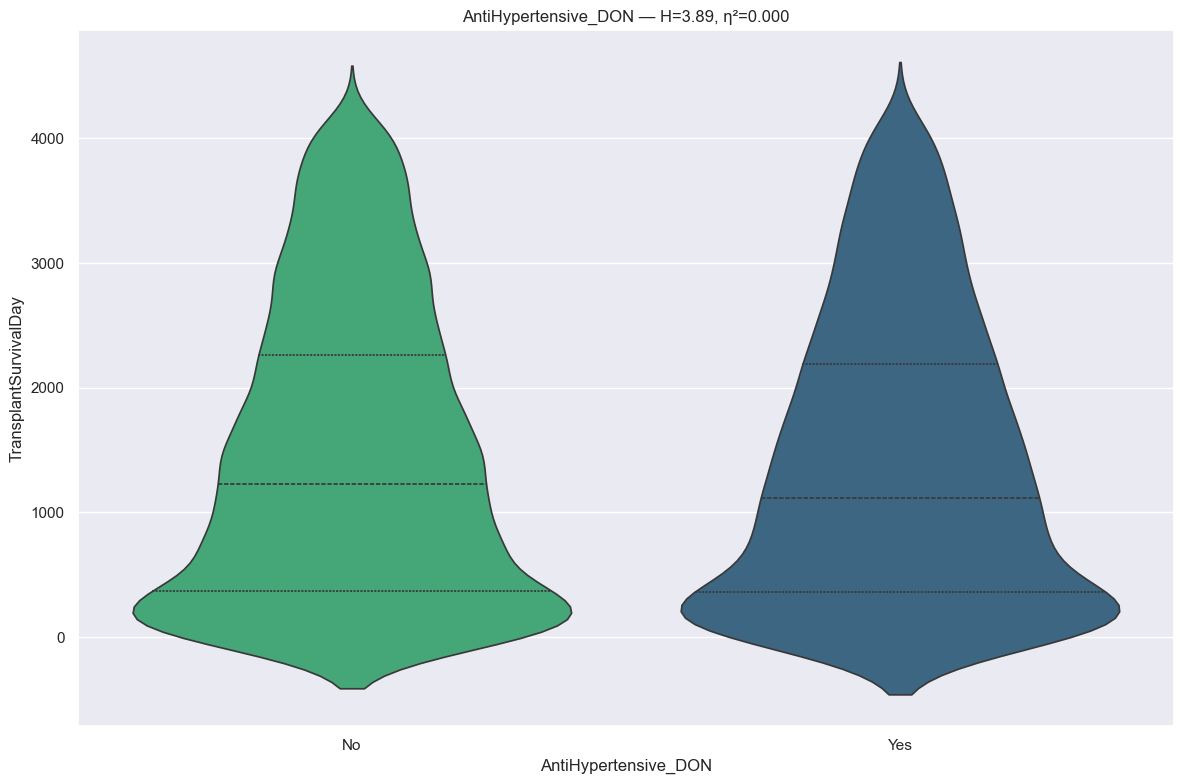

RANKING REPORT: AntiHypertensive_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5942 records
 * Yes                                               :   2974 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     17 records
--------------------------------------------------------------------------------
Kruskal H: 3.8915 | P-value: 4.853178e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.8532e-02 | thr=0.0500 | r=-0.026 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

AntiHypertensive_DON  mean_survival_days  median

In [73]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [74]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Blood Infection Source

In [75]:
# info
feature = u.get_feature_info(df, 'BloodInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique top  freq
BloodInfectionSource_DON  8933      3  No  8027

:::: NaN Count:
BloodInfectionSource_DON    0 



{'BloodInfectionSource_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

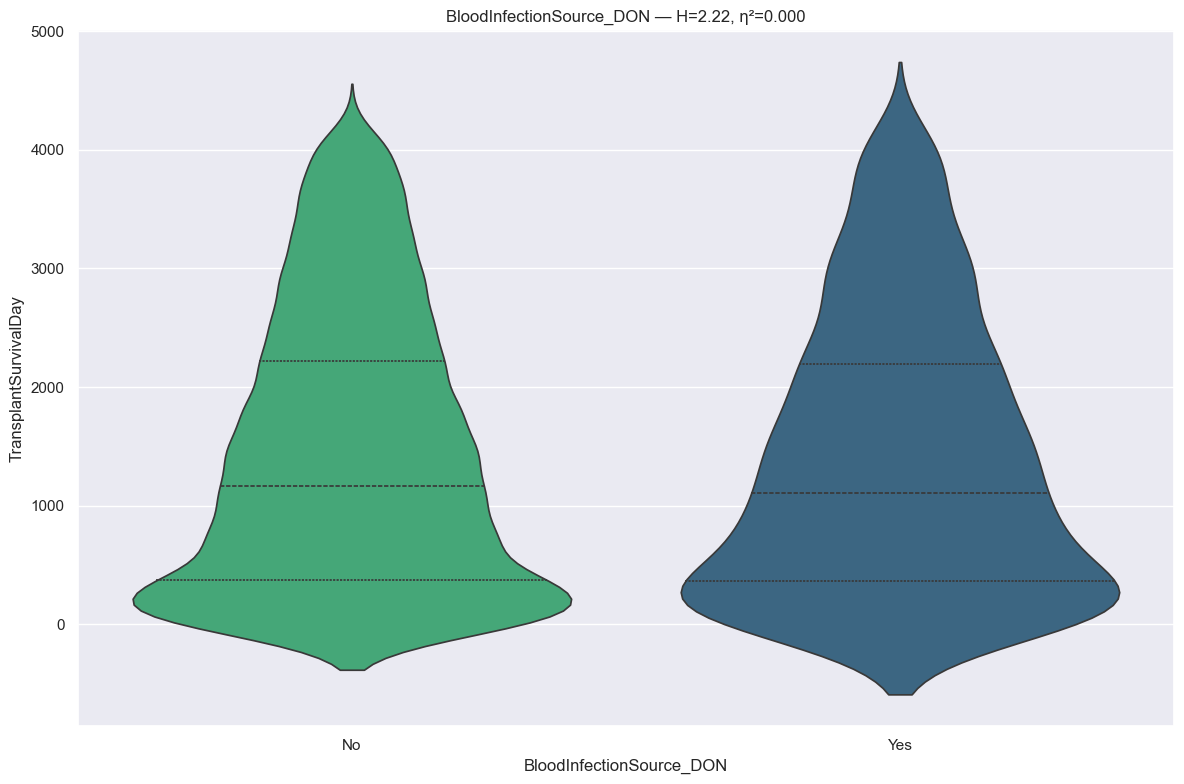

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8027 records
 * Yes                                               :    905 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 2.2192 | P-value: 1.363075e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.3631e-01 | thr=0.0500 | r=-0.030 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Unknown

BloodInfectionSource_DON  mean_survival_days  median_survival_days  ma

In [76]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [77]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8027 records
 * Yes                                               :    905 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 2.2192 | P-value: 1.363075e-01 | Effect η²: 0.0001
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.3631e-01 | fdr_alpha=0.05 | r=-0.030 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Unknown



In [78]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### OtherInfectionSource_DON

In [79]:
# info
feature = u.get_feature_info(df, 'OtherInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique top  freq
OtherInfectionSource_DON  8933      3  No  6090

:::: NaN Count:
OtherInfectionSource_DON    0 



{'OtherInfectionSource_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

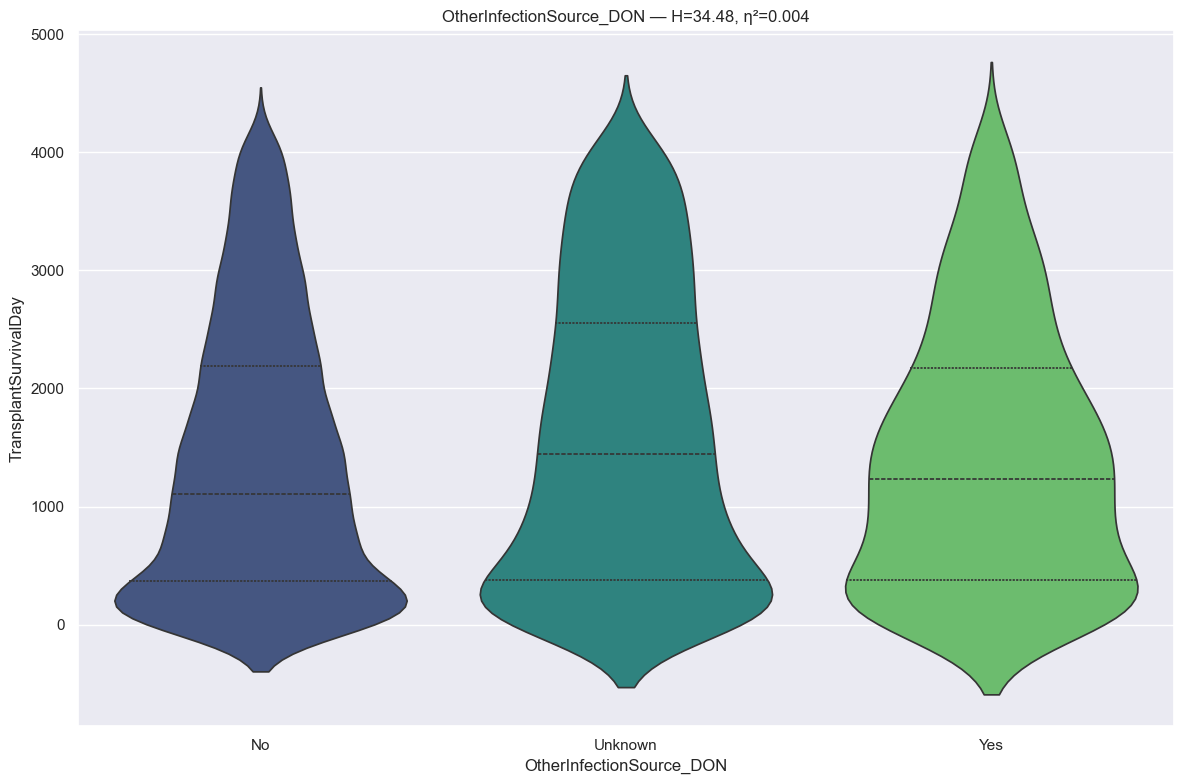

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6090 records
 * Unknown                                           :   2158 records
 * Yes                                               :    685 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 34.4806 | P-value: 3.255654e-08 | Effect η²: 0.0036
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=5.0525e-09 | thr=0.0167 | r= 0.085 | *Sig*
Unknown      vs Yes          | p=5.7433e-03 | thr=0.0167 | r=-0.070 | *Sig*
No           vs Yes          | p=4.1251e-01 | thr=0.0167 | r= 0.019 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> G

In [80]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [81]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6090 records
 * Unknown                                           :   2158 records
 * Yes                                               :    685 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 34.4806 | P-value: 3.255654e-08 | Effect η²: 0.0036
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Unknown      | p=5.0525e-09 | thr=0.0167 | r= 0.085 | *Sig*
Unknown      vs Yes          | p=5.7433e-03 | thr=0.0250 | r=-0.070 | *Sig*
No           vs Yes          | p=4.1251e-01 | thr=0.0500 | r= 0.019 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> 

In [82]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6090 records
 * Unknown                                           :   2158 records
 * Yes                                               :    685 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 34.4806 | P-value: 3.255654e-08 | Effect η²: 0.0036
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Unknown      | p=5.0525e-09 | fdr_alpha=0.05 | r= 0.085 | *Sig*
Unknown      vs Yes          | p=5.7433e-03 | fdr_alpha=0.05 | r=-0.070 | *Sig*
No           vs Yes          | p=4.1251e-01 | fdr_alpha=0.05 | r= 0.019 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::

In [83]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Diuretics
* Diuretics, or "water pills," help kidneys remove excess salt and water, primarily treating high blood pressure, heart failure, and edema (swelling) by increasing urine output. Common types include thiazide, loop, and potassium-sparing diuretics. Side effects often involve dizziness, electrolyte imbalances, and increased urination.

In [84]:
# info
feature = u.get_feature_info(df, 'Diuretics', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique  top  freq
Diuretics_DON  8933      3  Yes  6341

:::: NaN Count:
Diuretics_DON    0 



{'Diuretics_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

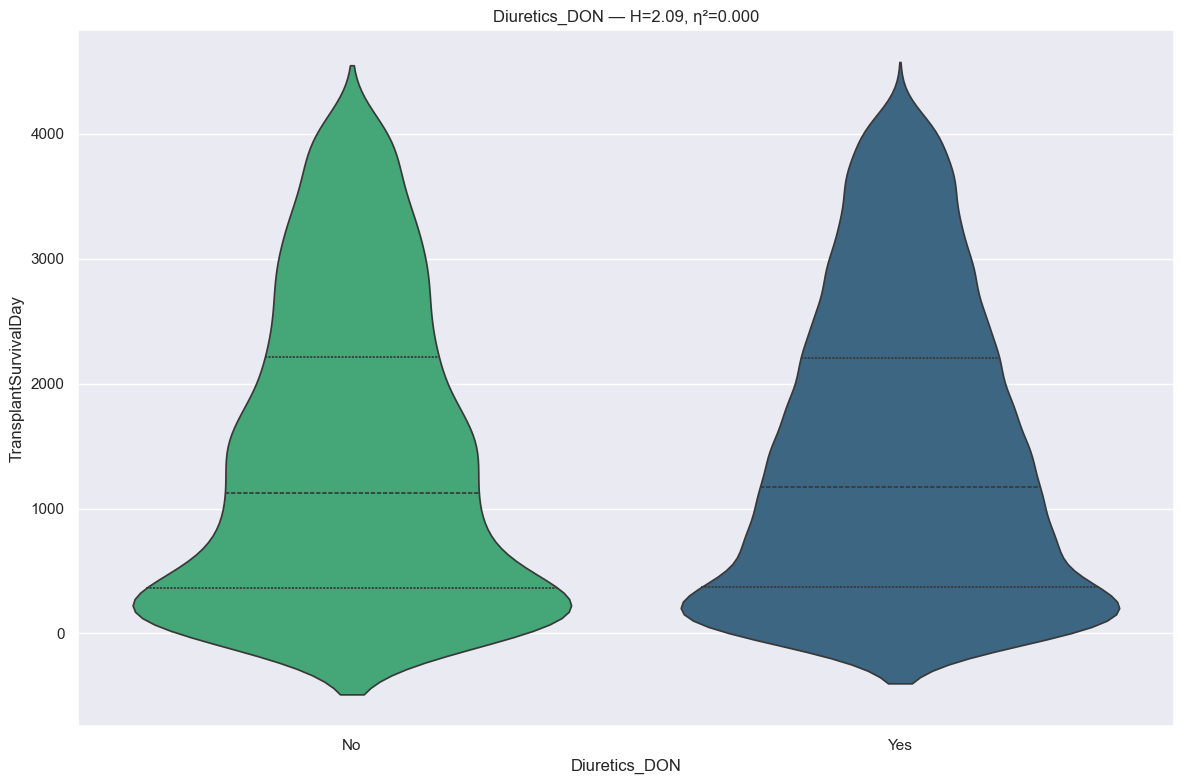

RANKING REPORT: Diuretics_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2576 records
 * Yes                                               :   6341 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     16 records
--------------------------------------------------------------------------------
Kruskal H: 2.0919 | P-value: 1.480823e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.4808e-01 | thr=0.0500 | r= 0.020 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Unknown

Diuretics_DON  mean_survival_days  median_survival_days  maximum_survival_days  m

In [85]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [86]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature has no meaningful association with survival (tiny effect, non-significant), and the Unknown group is negligible and can be dropped.

#### Steroids Use

In [87]:
# info
feature = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique  top  freq
SteroidsUse_DON  8933      3  Yes  6400

:::: NaN Count:
SteroidsUse_DON    0 



{'SteroidsUse_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

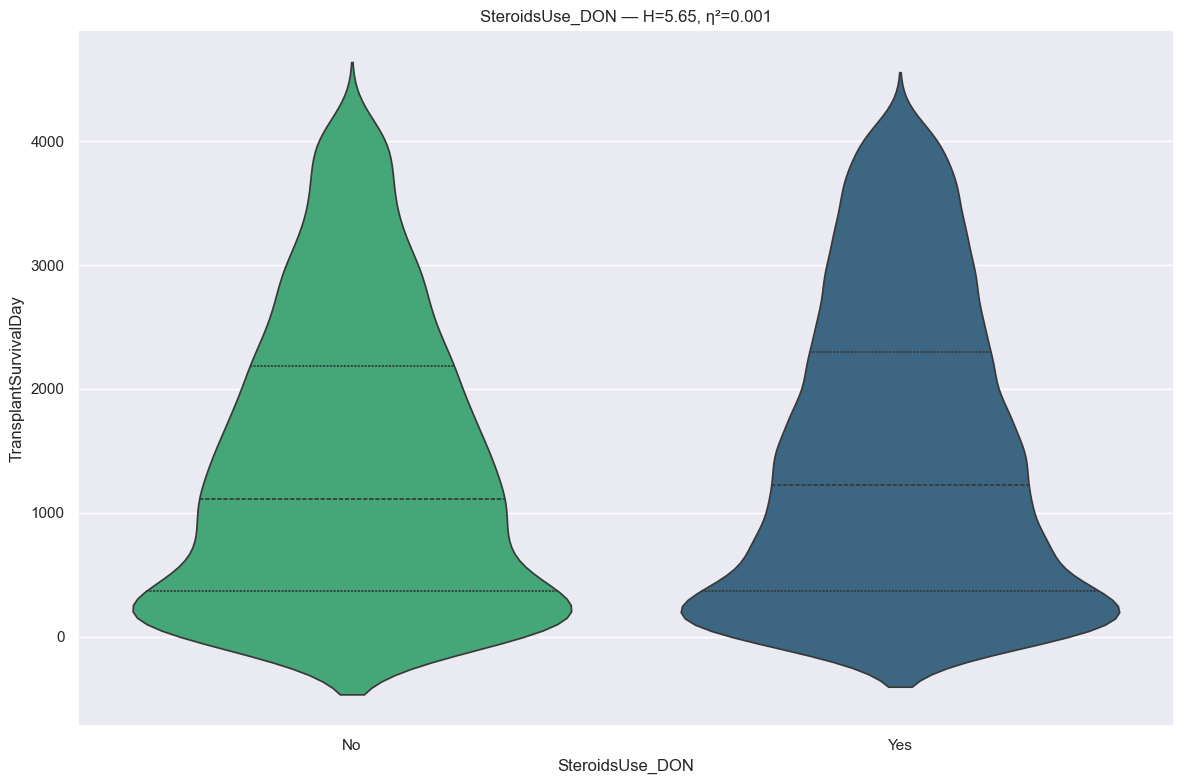

RANKING REPORT: SteroidsUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2509 records
 * Yes                                               :   6400 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     24 records
--------------------------------------------------------------------------------
Kruskal H: 5.6484 | P-value: 1.747153e-02 | Effect η²: 0.0005
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.7472e-02 | thr=0.0500 | r= 0.032 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

SteroidsUse_DON  mean_survival_days  median_survival_

In [88]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [89]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Triiodothyronine T3
* Triiodothyronine ($T_{3}$) is a vital thyroid hormone produced by the thyroid gland and by conversion from thyroxine ($T_{4}$), primarily regulating metabolism, body temperature, heart rate, and growth. It acts as the more active form of thyroid hormone. Normal adult ($T_{3}$) levels generally range from 70–205 nanograms per deciliter (ng/dL). 

In [90]:
# info
feature = u.get_feature_info(df, 'TriiodothyronineT3', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top  freq
TriiodothyronineT3_DON  8933      3  No  8875

:::: NaN Count:
TriiodothyronineT3_DON    0 



{'TriiodothyronineT3_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

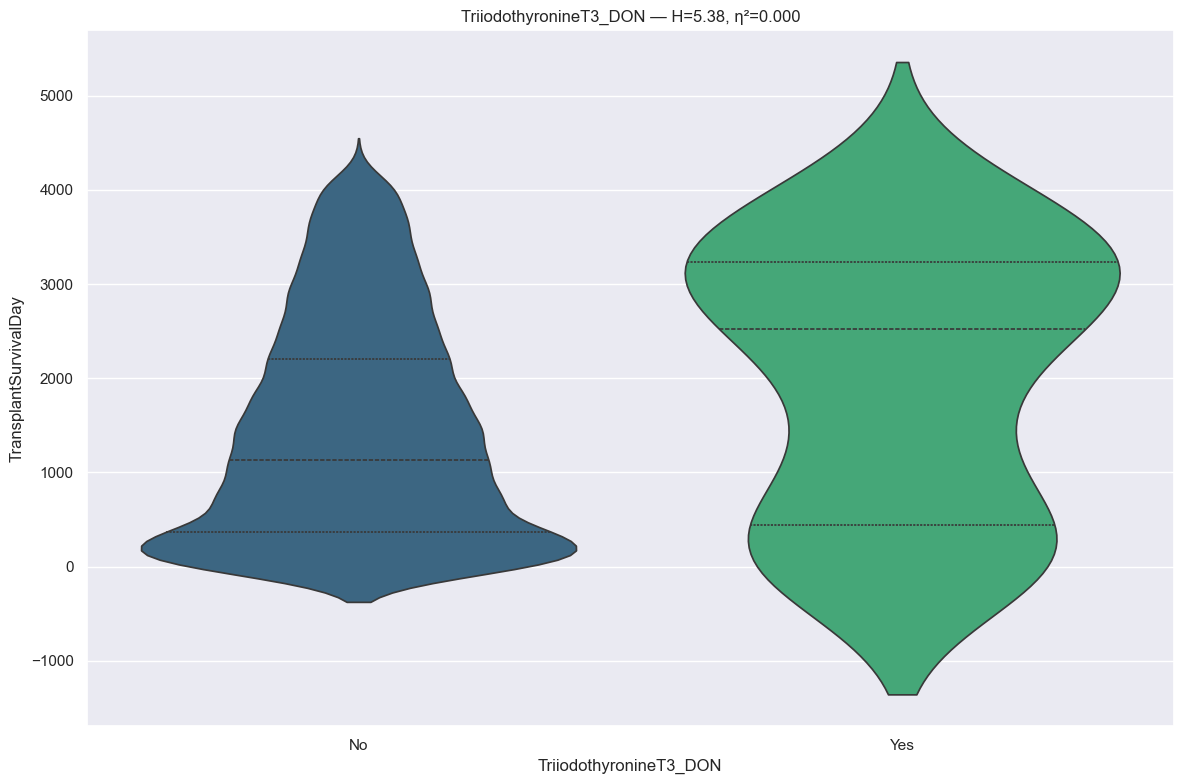

RANKING REPORT: TriiodothyronineT3_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8875 records
 * Yes                                               :     41 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     17 records
--------------------------------------------------------------------------------
Kruskal H: 5.3795 | P-value: 2.037521e-02 | Effect η²: 0.0005
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.0377e-02 | thr=0.0500 | r= 0.210 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

TriiodothyronineT3_DON  mean_survival_days  me

In [91]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [92]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Thyroxine T4
* Thyroxine $(T_{4}$) is a primary hormone produced by the thyroid gland, essential for regulating metabolism, heart rate, temperature, and brain development. It acts as a prohormone, converting to the more active $(T_{3})$ in tissues. Normal Free $(T_{4}$) levels are generally 0.8–1.9 ng/dL, while abnormalities cause hyperthyroidism (high) or hypothyroidism (low). 

In [93]:
# info
feature = u.get_feature_info(df, 'ThyroxineT4', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique  top  freq
ThyroxineT4_DON  8933      3  Yes  5805

:::: NaN Count:
ThyroxineT4_DON    0 



{'ThyroxineT4_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

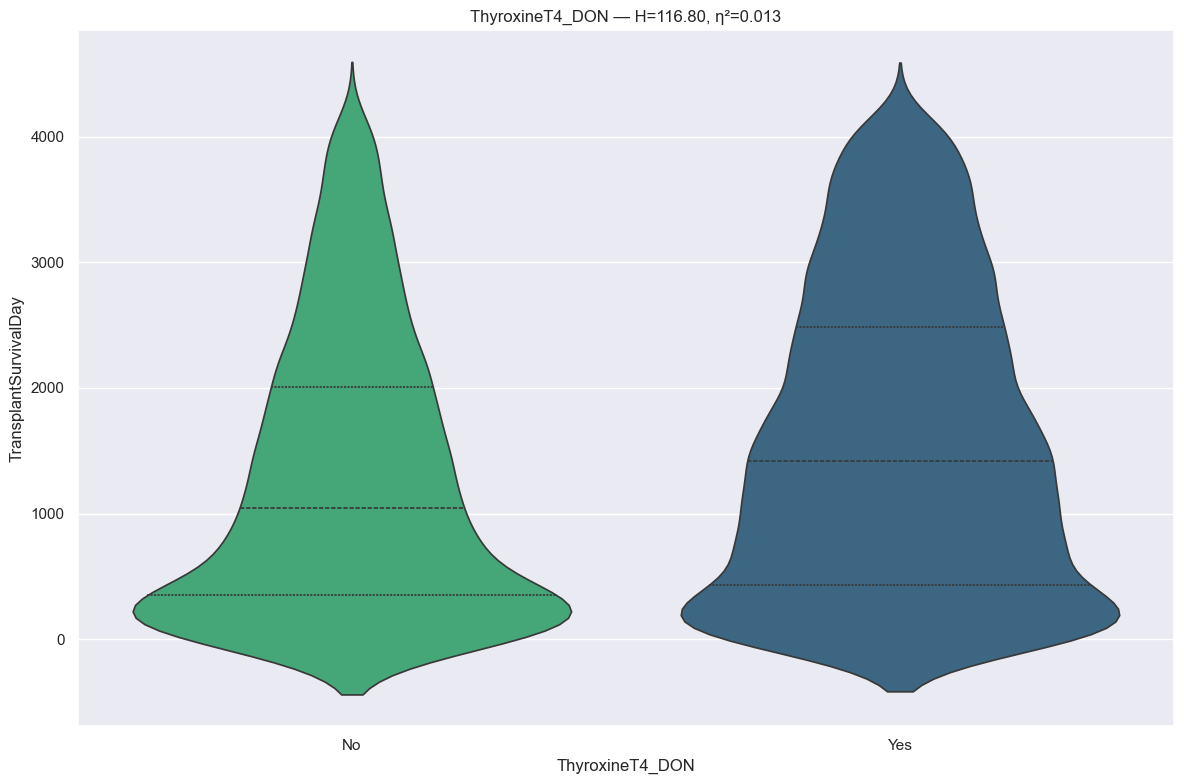

RANKING REPORT: ThyroxineT4_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3112 records
 * Yes                                               :   5805 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     16 records
--------------------------------------------------------------------------------
Kruskal H: 116.8043 | P-value: 3.168371e-27 | Effect η²: 0.0130
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.1685e-27 | thr=0.0500 | r= 0.139 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

ThyroxineT4_DON  mean_survival_days  median_surviva

In [94]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [95]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Pulmonary Infection
* Pulmonary infections are infections in the lungs or airways caused by bacteria, viruses, or fungi, leading to inflammation and symptoms like cough, fever, chest pain, and difficulty breathing. Common types include pneumonia and bronchitis, often treated with antibiotics, antiviral medication, or self-care, depending on the cause.

In [96]:
# info
feature = u.get_feature_info(df, 'PulmonaryInfection', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top  freq
PulmonaryInfection_DON  8933      3  Yes  5870

:::: NaN Count:
PulmonaryInfection_DON    0 



{'PulmonaryInfection_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

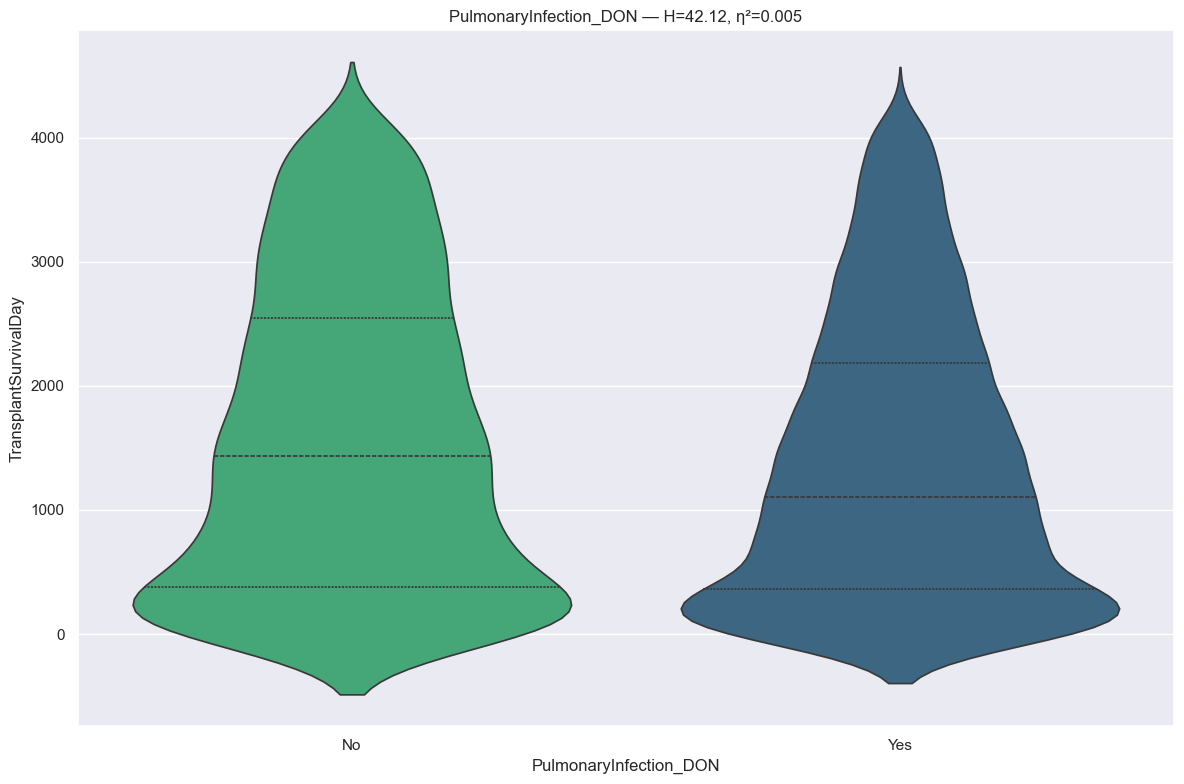

RANKING REPORT: PulmonaryInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3062 records
 * Yes                                               :   5870 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 42.1222 | P-value: 8.574488e-11 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=8.5747e-11 | thr=0.0500 | r=-0.084 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

PulmonaryInfection_DON  mean_survival_days  m

In [97]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [98]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### PULM INF CONF
* Pulmonary Function Tests (PFTs) are essential diagnostic tools that assess lung function by measuring volumes and flow, helping distinguish between obstructive diseases (e.g., COPD) and restrictive diseases (e.g., fibrosis). These tests measure FEV1, FVC, and flow-volume loops to guide treatment plans.

In [99]:
# info
feature = u.get_feature_info(df, 'PULM_INF_CONF_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique      top  freq
PULM_INF_CONF_DON  8933      3  Unknown  7033

:::: NaN Count:
PULM_INF_CONF_DON    0 



{'PULM_INF_CONF_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

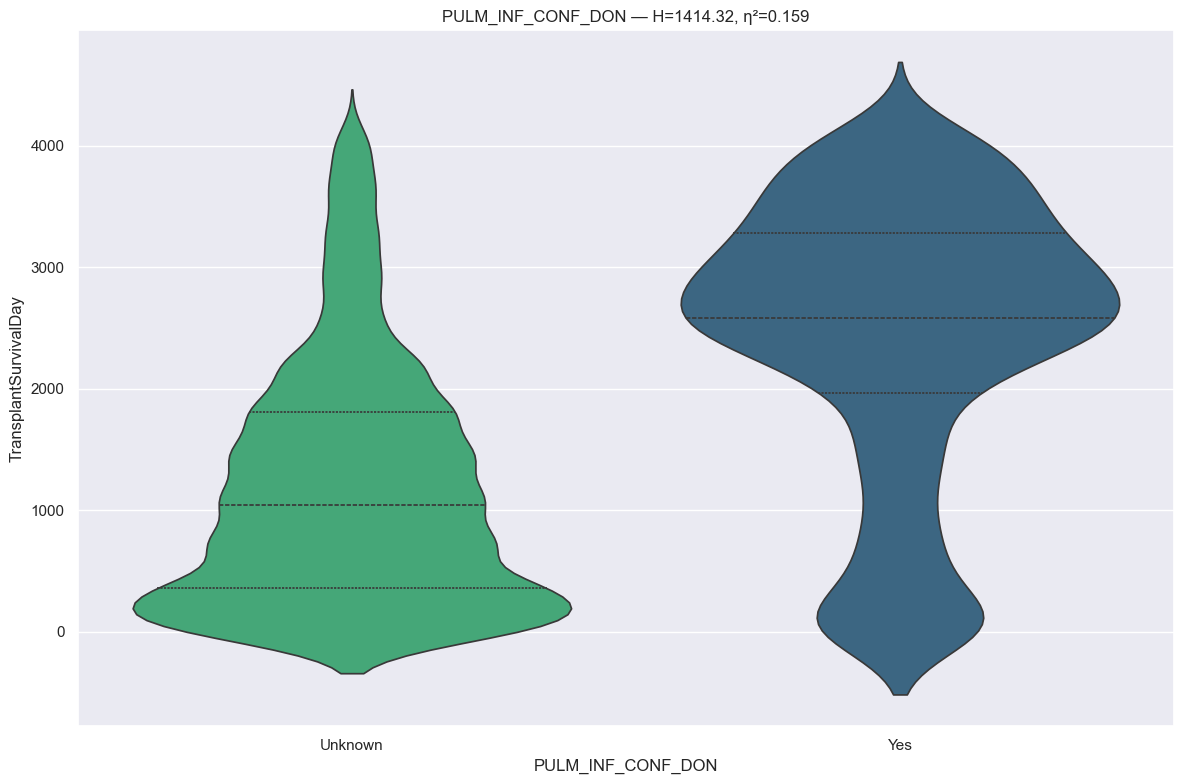

RANKING REPORT: PULM_INF_CONF_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Unknown                                           :   7033 records
 * Yes                                               :   1876 records
BYPASSED CATEGORIES (n < min_n):
 * No                                                :     24 records
--------------------------------------------------------------------------------
Kruskal H: 1414.3153 | P-value: 1.628123e-309 | Effect η²: 0.1587
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=1.6284e-309 | thr=0.0500 | r= 0.564 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Unknown

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - No

PULM_INF_CONF_DON  mean_survival_days  median_

In [100]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [101]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Urine Infection

In [102]:
# info
feature = u.get_feature_info(df, 'UrineInfection', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top  freq
UrineInfection_DON  8933      3  No  6695

:::: NaN Count:
UrineInfection_DON    0 



{'UrineInfection_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

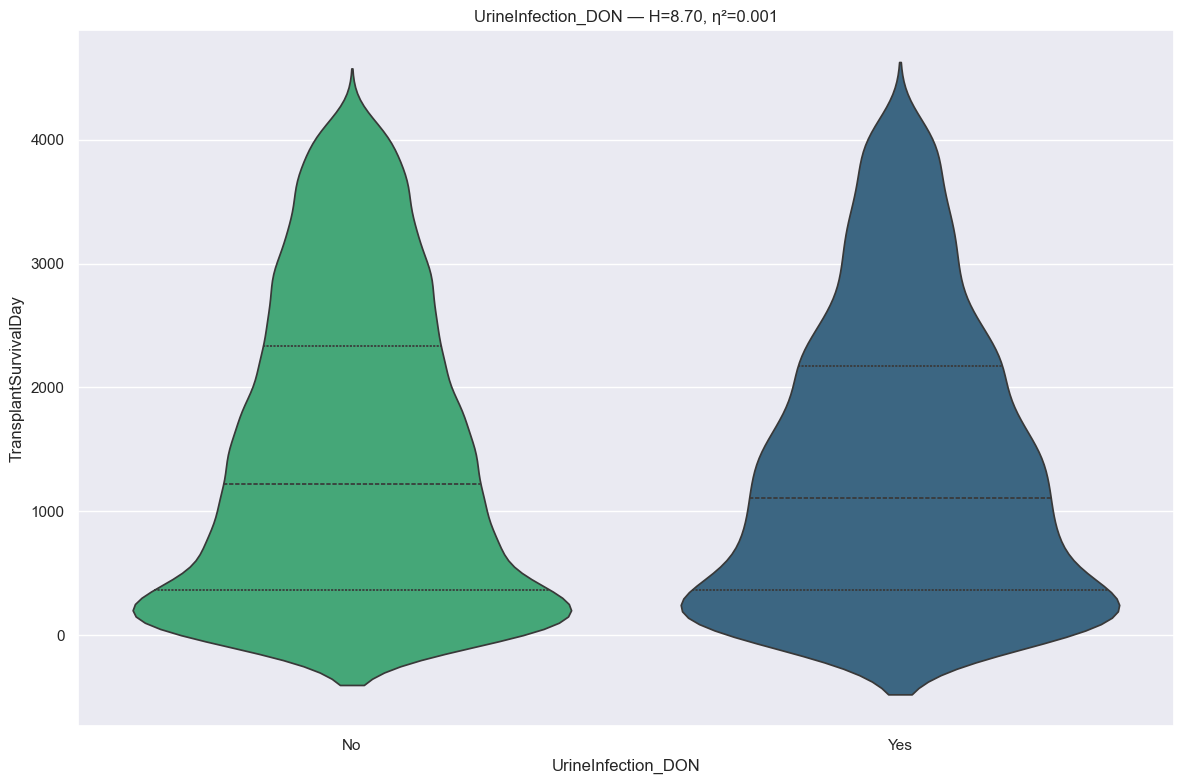

RANKING REPORT: UrineInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6695 records
 * Yes                                               :   2237 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 8.6990 | P-value: 3.183882e-03 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.1839e-03 | thr=0.0500 | r=-0.042 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

UrineInfection_DON  mean_survival_days  median_sur

In [103]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [104]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Vasodilators
* Vasodilators are medications that widen blood vessels by relaxing smooth muscle cells in vessel walls, improving blood flow, and reducing blood pressure. They are primarily used to treat hypertension, heart failure, and angina. Common types include hydralazine, minoxidil, and nitroprusside. Common side effects include dizziness, headaches, flushing, and rapid heartbeat.

In [105]:
# info
feature = u.get_feature_info(df, 'Vasodilators', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique top  freq
Vasodilators_DON  8933      3  No  7454

:::: NaN Count:
Vasodilators_DON    0 



{'Vasodilators_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

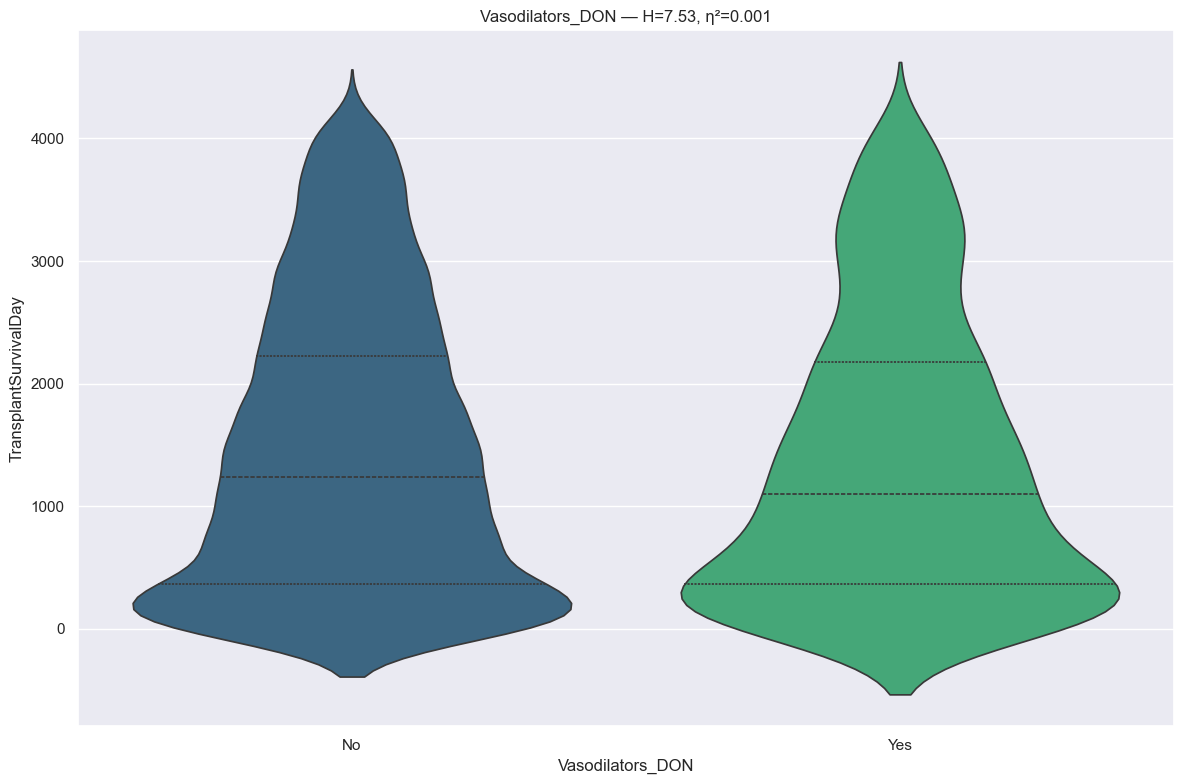

RANKING REPORT: Vasodilators_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7454 records
 * Yes                                               :   1461 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     18 records
--------------------------------------------------------------------------------
Kruskal H: 7.5290 | P-value: 6.071389e-03 | Effect η²: 0.0007
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.0715e-03 | thr=0.0500 | r=-0.045 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

Vasodilators_DON  mean_survival_days  median_surviva

In [106]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [107]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antibody Result RPR VDRL
* RPR (Rapid Plasma Reagin) and VDRL (Venereal Disease Research Laboratory) are essential non-treponemal screening tests used to detect active syphilis infection in both donors and recipients. A positive (reactive) RPR/VDRL result requires confirmation with a treponemal-specific test (such as TP-PA), as non-treponemal tests can yield false positives due to other conditions, including autoimmune disorders or infections.

In [108]:
# info
feature = u.get_feature_info(df, 'AntibodyResultRPR_VDRL', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                           count unique       top  freq
AntibodyResultRPR_VDRL_DON  8933      4  Negative  8688

:::: NaN Count:
AntibodyResultRPR_VDRL_DON    0 



{'AntibodyResultRPR_VDRL_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Positive',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

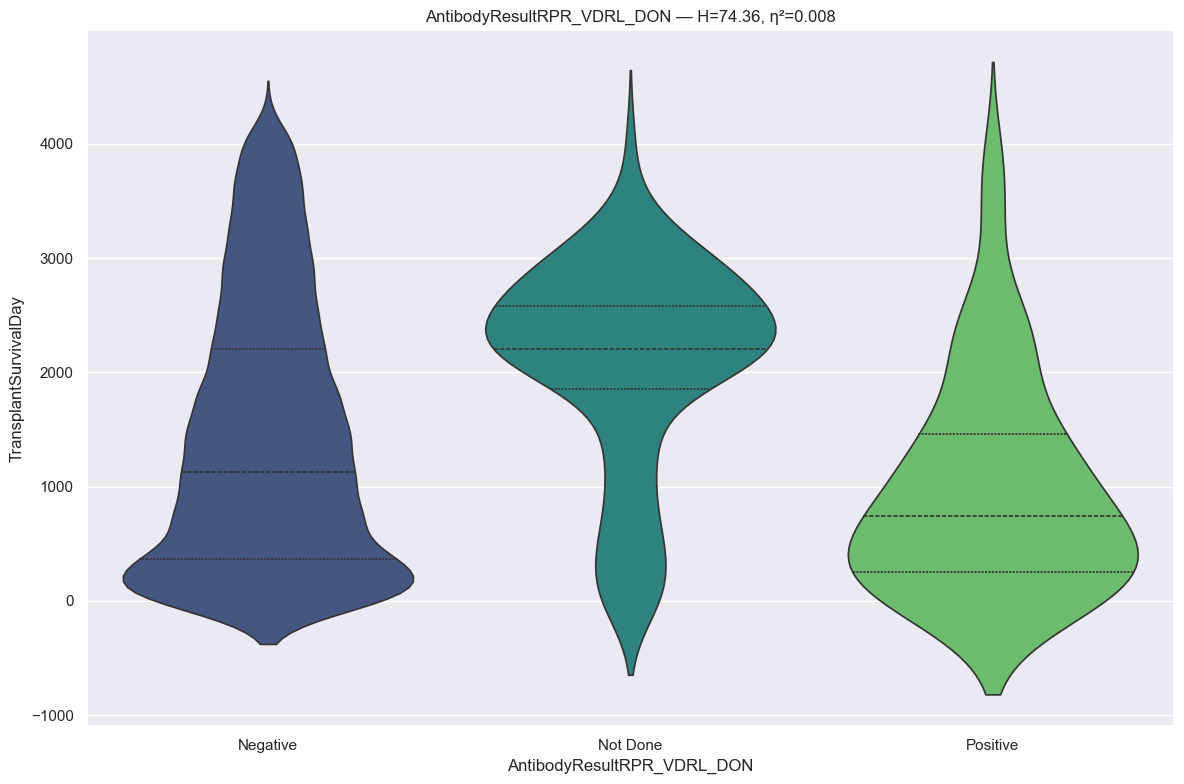

RANKING REPORT: AntibodyResultRPR_VDRL_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8688 records
 * Not Done                                          :    175 records
 * Positive                                          :     63 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 74.3558 | P-value: 7.142316e-17 | Effect η²: 0.0081
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=7.8623e-16 | thr=0.0167 | r= 0.355 | *Sig*
Not Done     vs Positive     | p=5.2220e-12 | thr=0.0167 | r=-0.587 | *Sig*
Negative     vs Positive     | p=2.9995e-03 | thr=0.0167 | r=-0.217 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::

In [109]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [110]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Infection Clinical
* Clinical infection occurs when pathogenic microorganisms—bacteria, viruses, fungi, or parasites—enter the body, multiply, and trigger a host immune response, causing symptoms like fever, fatigue, and pain. These diseases spread through person-to-person contact, contaminated food/water, surfaces, or insect bites. Treatments include antibiotics, antivirals, or antifungals, often guided by diagnostic tests like blood tests, urine tests, or throat swabs.

In [111]:
# info
feature = u.get_feature_info(df, 'InfectionClinical', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top  freq
InfectionClinical_DON  8933      3  Yes  6775

:::: NaN Count:
InfectionClinical_DON    0 



{'InfectionClinical_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

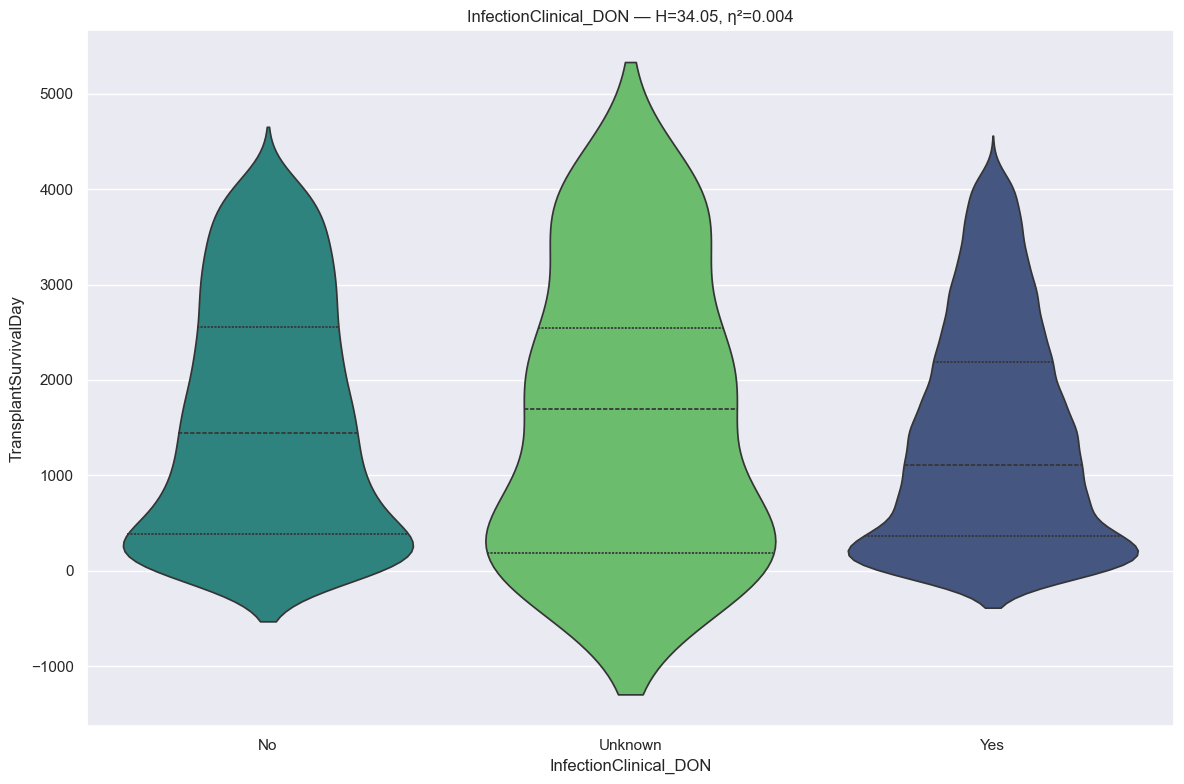

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2105 records
 * Unknown                                           :     53 records
 * Yes                                               :   6775 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 34.0472 | P-value: 4.043358e-08 | Effect η²: 0.0036
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.6032e-09 | thr=0.0167 | r=-0.084 | *Sig*
Unknown      vs Yes          | p=5.5046e-01 | thr=0.0167 | r=-0.048 | Not Sig
No           vs Unknown      | p=7.9941e-01 | thr=0.0167 | r=-0.020 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Gr

In [112]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [113]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04}  # more relaxed & retain these small-but-important differences
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2105 records
 * Unknown                                           :     53 records
 * Yes                                               :   6775 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 34.0472 | P-value: 4.043358e-08 | Effect η²: 0.0036
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.6032e-09 | thr=0.0167 | r=-0.084 | *Sig*
Unknown      vs Yes          | p=5.5046e-01 | thr=0.0250 | r=-0.048 | Not Sig
No           vs Unknown      | p=7.9941e-01 | thr=0.0500 | r=-0.020 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> G

In [114]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cocaine Use

In [115]:
# info
feature = u.get_feature_info(df, '^CocaineUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique      top  freq
CocaineUse_DON  8933      3  Unknown  7475

:::: NaN Count:
CocaineUse_DON    0 



{'CocaineUse_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

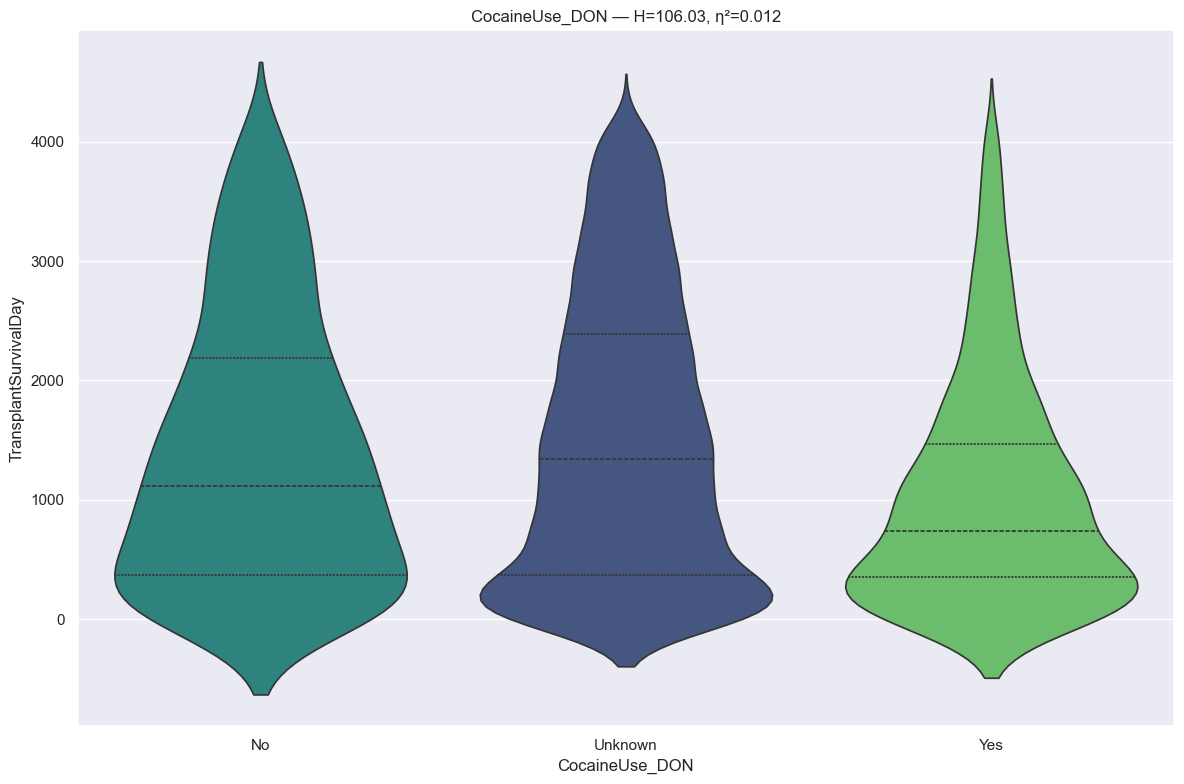

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    581 records
 * Unknown                                           :   7475 records
 * Yes                                               :    877 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 106.0347 | P-value: 9.437696e-24 | Effect η²: 0.0117
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=9.5297e-25 | thr=0.0167 | r=-0.212 | *Sig*
No           vs Yes          | p=1.2647e-09 | thr=0.0167 | r=-0.188 | *Sig*
No           vs Unknown      | p=2.1459e-01 | thr=0.0167 | r= 0.031 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2

In [116]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [117]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    581 records
 * Unknown                                           :   7475 records
 * Yes                                               :    877 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 106.0347 | P-value: 9.437696e-24 | Effect η²: 0.0117
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Group_2 (1 categories)
  - Yes



In [118]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Other Drug Use

In [119]:
# info
feature = u.get_feature_info(df, '^OtherDrugUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique      top  freq
OtherDrugUse_DON  8933      3  Unknown  5202

:::: NaN Count:
OtherDrugUse_DON    0 



{'OtherDrugUse_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

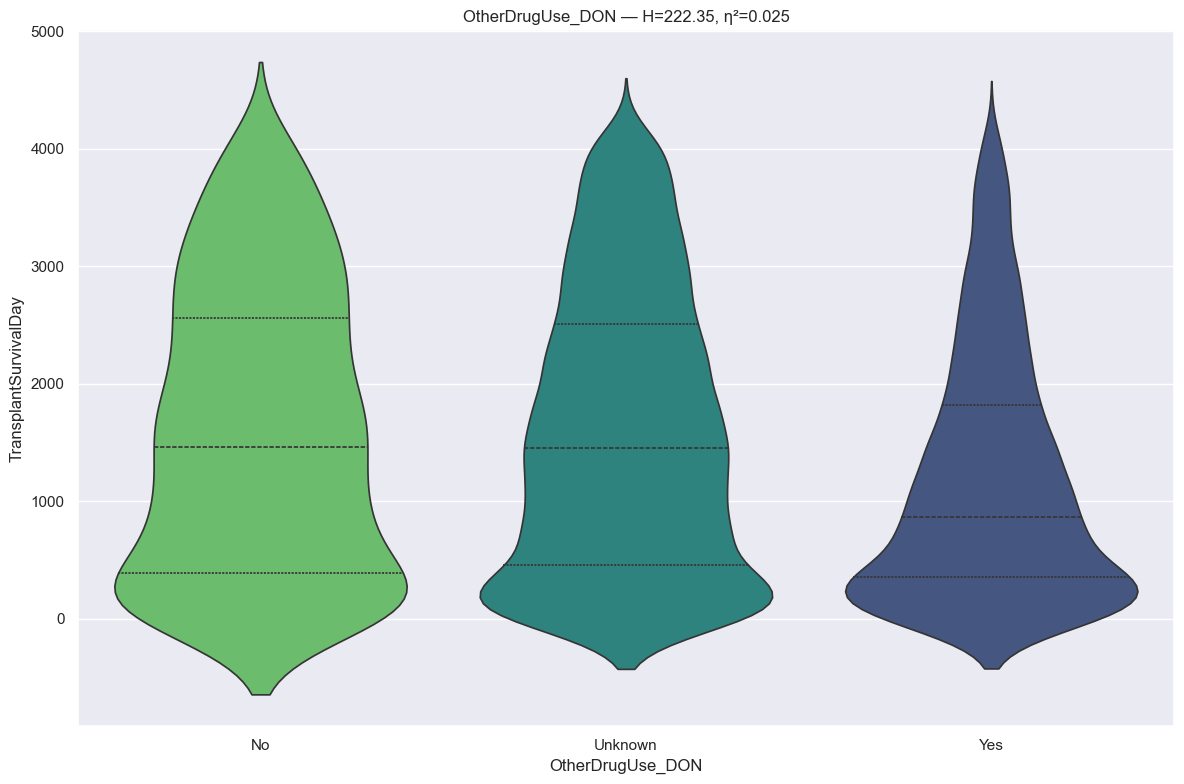

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    751 records
 * Unknown                                           :   5202 records
 * Yes                                               :   2980 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 222.3472 | P-value: 5.222925e-49 | Effect η²: 0.0247
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=7.2613e-48 | thr=0.0167 | r=-0.193 | *Sig*
No           vs Yes          | p=1.1070e-16 | thr=0.0167 | r=-0.196 | *Sig*
No           vs Unknown      | p=6.5290e-01 | thr=0.0167 | r=-0.010 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 

In [120]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [121]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    751 records
 * Unknown                                           :   5202 records
 * Yes                                               :   2980 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 222.3472 | P-value: 5.222925e-49 | Effect η²: 0.0247
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Group_2 (1 categories)
  - Yes



In [122]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer ExtraCranial
* Extracranial germ cell tumors (GCTs) are cancers that develop outside the brain, frequently occurring in children and young adults on the sacrum, coccyx, chest, or abdomen. They are classified as benign (mature teratoma) or malignant. Treatment options often include a combination of surgery, cisplatin-based chemotherapy (such as BEP), and radiation therapy.

In [123]:
# info
feature = u.get_feature_info(df, 'CancerExtraCranial', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top  freq
CancerExtraCranial_DON  8933      3  No  8859

:::: NaN Count:
CancerExtraCranial_DON    0 



{'CancerExtraCranial_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

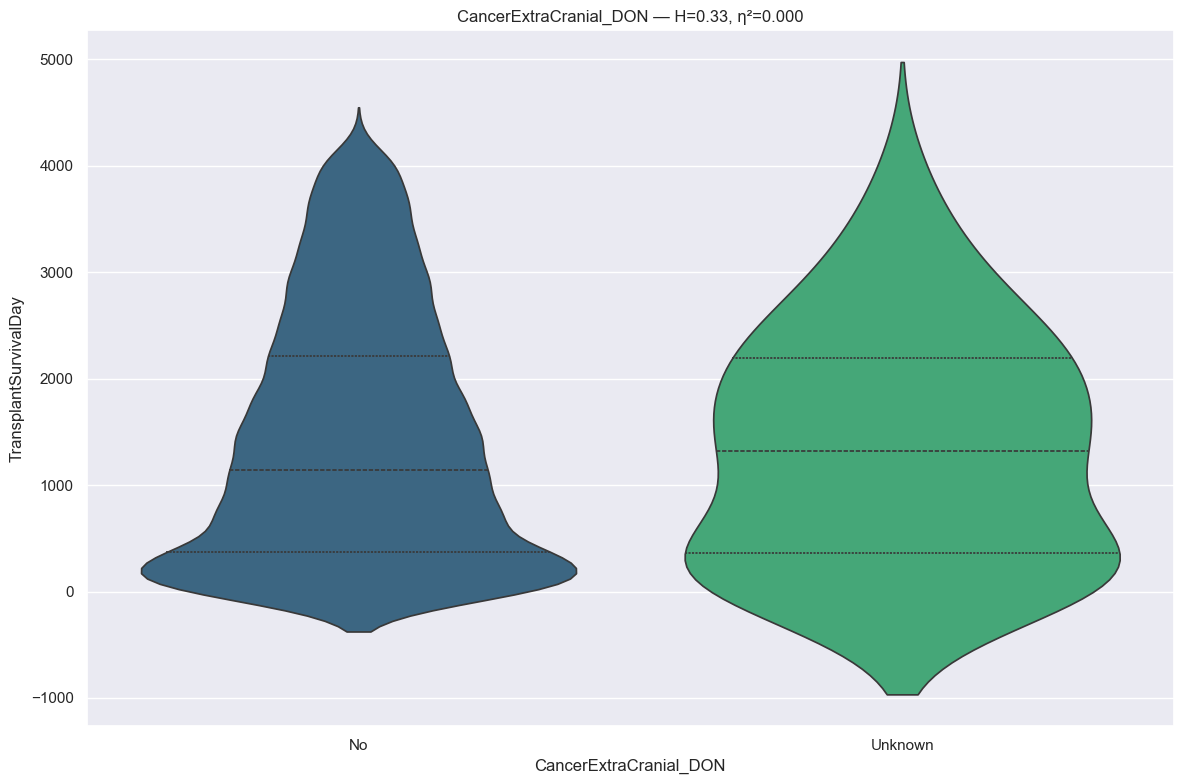

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8859 records
 * Unknown                                           :     58 records
BYPASSED CATEGORIES (n < min_n):
 * Yes                                               :     16 records
--------------------------------------------------------------------------------
Kruskal H: 0.3311 | P-value: 5.649844e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=5.6500e-01 | thr=0.0500 | r=-0.044 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (1 categories)
  - Yes

CancerExtraCranial_DON  mean_survival_days  median_survival_days  maximu

In [124]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [125]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.05, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8859 records
 * Unknown                                           :     58 records
BYPASSED CATEGORIES (n < min_n):
 * Yes                                               :     16 records
--------------------------------------------------------------------------------
Kruskal H: 0.3311 | P-value: 5.649844e-01 | Effect η²: 0.0000
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (1 categories)
  - Yes



In [126]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer Site

In [127]:
# info
feature = u.get_feature_info(df, 'CancerSite', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
CancerSite_DON  8933     21  NO  8664

:::: NaN Count:
CancerSite_DON    0 



{'CancerSite_DON': CategoricalDtype(categories=['BREAST', 'CNS TUMOR - ASTROCYTOMA',
                   'CNS TUMOR - GLIOBLASTOMA MULTIFORME',
                   'CNS TUMOR - MEDULLOBLASTOMA', 'CNS TUMOR - MENINGIOMA',
                   'CNS TUMOR - NEUROBLASTOMA', 'CNS TUMOR - OTHER',
                   'GASTROINTESTINAL - COLO-RECTAL',
                   'GASTROINTESTINAL - STOMACH', 'GENITOURINARY - BLADDER',
                   'GENITOURINARY - KIDNEY', 'GENITOURINARY - OVARIAN',
                   'GENITOURINARY - PENIS, TESTICULAR',
                   'GENITOURINARY - PROSTATE', 'GENITOURINARY - UNKNOWN',
                   'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA',
                   'GENITOURINARY - UTERINE BODY ENDOMETRIAL',
                   'GENITOURINARY - UTERINE CERVIX', 'GENITOURINARY - VULVA',
                   'LEUKEMIA/LYMPHOMA', 'NO', 'OTHER, SPECIFY',
                   'SKIN - MELANOMA', 'SKIN - SQUAMOUS, BASAL CELL', 'THYROID',
                   'Unknown']

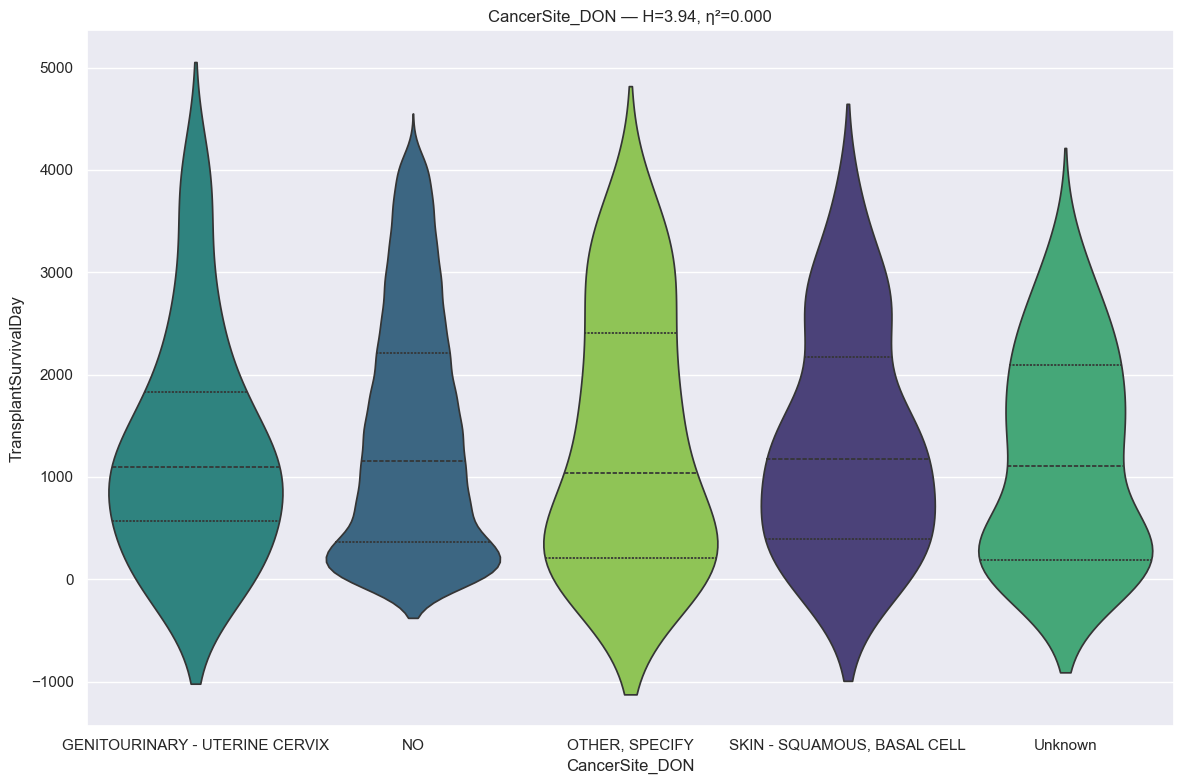

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * GENITOURINARY - UTERINE CERVIX                    :     48 records
 * NO                                                :   8664 records
 * OTHER, SPECIFY                                    :     46 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     44 records
 * Unknown                                           :     50 records
BYPASSED CATEGORIES (n < min_n):
 * BREAST                                            :     11 records
 * CNS TUMOR - ASTROCYTOMA                           :      3 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :      3 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :     19 records
 * CNS TUMOR - NEUROBLASTOMA                         :      2 records
 * CNS TUMOR - OTHER                                 :      6 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      1 reco

In [128]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [129]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Cigarette History

In [130]:
# info
feature = u.get_feature_info(df, 'CigaretteHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
CigaretteHistory_DON  8933      3  No  7672

:::: NaN Count:
CigaretteHistory_DON    0 



{'CigaretteHistory_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

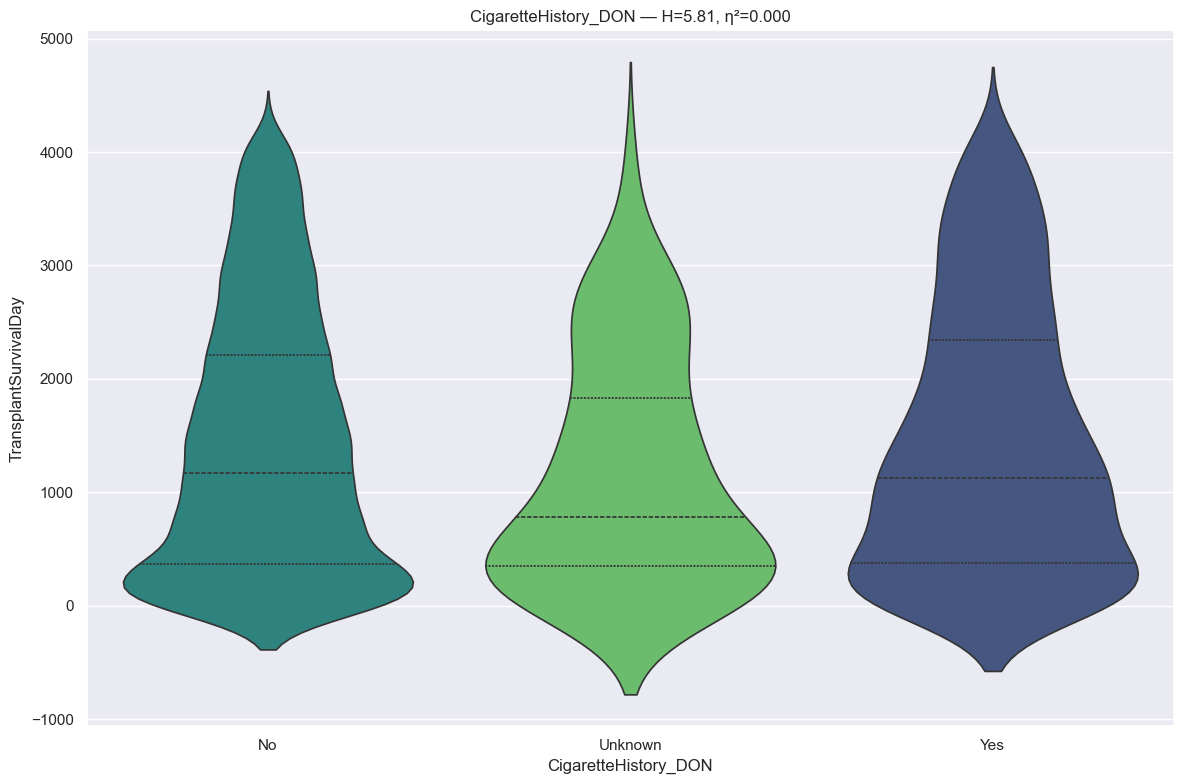

RANKING REPORT: CigaretteHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7672 records
 * Unknown                                           :    120 records
 * Yes                                               :   1141 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 5.8085 | P-value: 5.479045e-02 | Effect η²: 0.0004
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=1.7322e-02 | thr=0.0167 | r= 0.132 | Not Sig
No           vs Unknown      | p=1.7854e-02 | thr=0.0167 | r=-0.126 | Not Sig
No           vs Yes          | p=7.3341e-01 | thr=0.0167 | r= 0.006 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Gr

In [131]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [132]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Hypertension History
* Hypertension, or high blood pressure, is a chronic condition where blood forces against artery walls too strongly, often caused by lifestyle factors (poor diet, lack of exercise) or genetics.

In [133]:
# info
feature = u.get_feature_info(df, 'HypertensionHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique top  freq
HypertensionHistory_DON  8933      3  No  7066

:::: NaN Count:
HypertensionHistory_DON    0 



{'HypertensionHistory_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

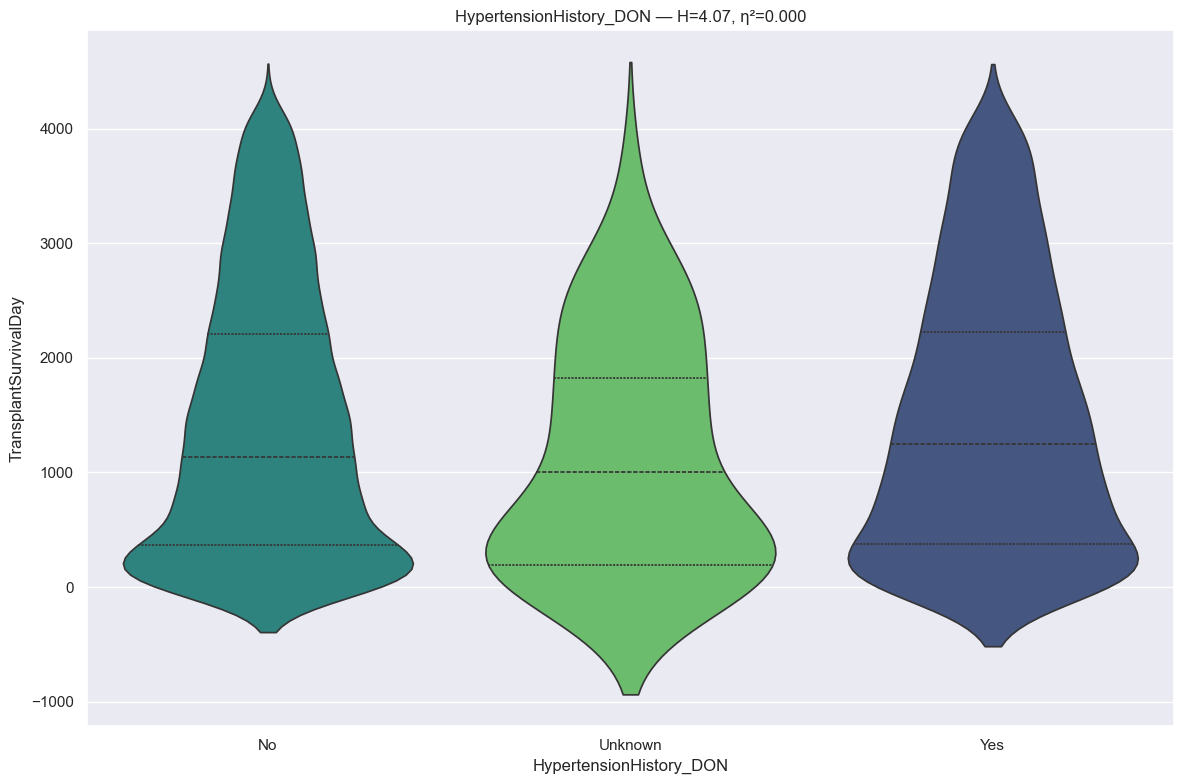

RANKING REPORT: HypertensionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7066 records
 * Unknown                                           :     47 records
 * Yes                                               :   1820 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 4.0657 | P-value: 1.309644e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=6.1284e-02 | thr=0.0167 | r= 0.160 | Not Sig
No           vs Unknown      | p=8.6815e-02 | thr=0.0167 | r=-0.145 | Not Sig
No           vs Yes          | p=3.1650e-01 | thr=0.0167 | r= 0.015 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>>

In [134]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [135]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Cancer Intra-Cranial
* Intracranial cancer involves tumors within the skull, either originating in the brain (primary) or spreading from elsewhere (metastatic). Key symptoms include severe headaches, seizures, nausea, vision changes, and personality shifts, which often progress quickly. Diagnosis involves imaging (MRI/CT), while treatments include surgery, radiation, and chemotherapy.

In [136]:
# info
feature = u.get_feature_info(df, 'CancerIntraCranial', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top  freq
CancerIntraCranial_DON  8933      3  No  8841

:::: NaN Count:
CancerIntraCranial_DON    0 



{'CancerIntraCranial_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

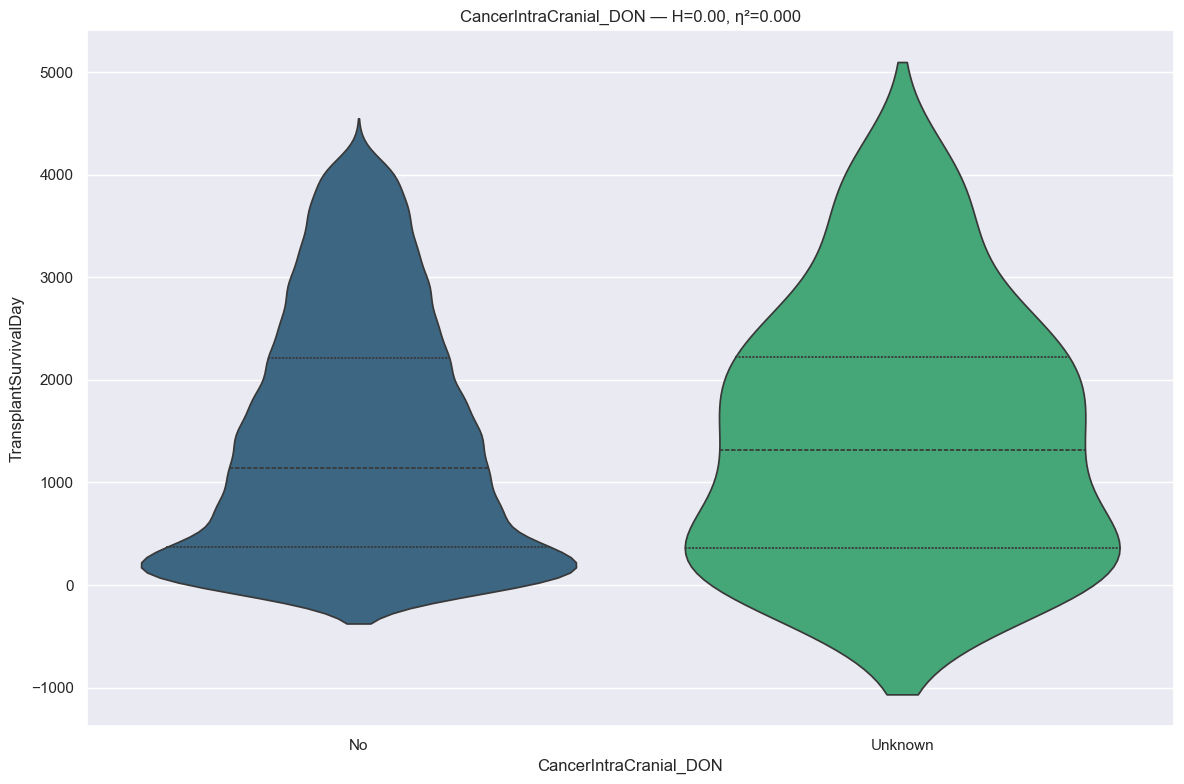

RANKING REPORT: CancerIntraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8841 records
 * Unknown                                           :     65 records
BYPASSED CATEGORIES (n < min_n):
 * Yes                                               :     27 records
--------------------------------------------------------------------------------
Kruskal H: 0.0000 | P-value: 9.990342e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=9.9905e-01 | thr=0.0500 | r= 0.000 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (1 categories)
  - Yes

CancerIntraCranial_DON  mean_survival_days  median_survival_days  maximu

In [137]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [138]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Cancer History

In [139]:
# info
feature = u.get_feature_info(df, 'CancerHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique top  freq
CancerHistory_DON  8933      3  No  8664

:::: NaN Count:
CancerHistory_DON    0 



{'CancerHistory_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

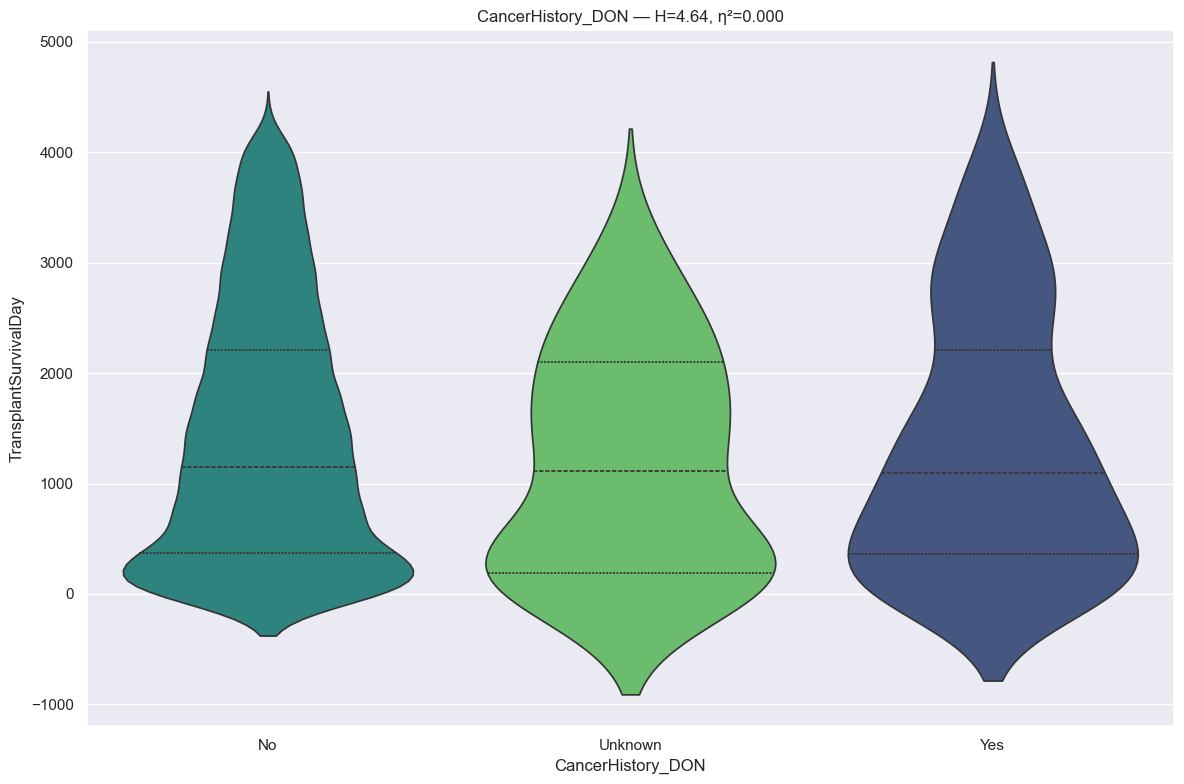

RANKING REPORT: CancerHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8664 records
 * Unknown                                           :     50 records
 * Yes                                               :    219 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 4.6391 | P-value: 9.831914e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.1211e-01 | thr=0.0167 | r=-0.063 | Not Sig
No           vs Unknown      | p=1.4055e-01 | thr=0.0167 | r=-0.121 | Not Sig
Unknown      vs Yes          | p=5.5973e-01 | thr=0.0167 | r= 0.053 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group

In [140]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [141]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Diabetes History
* Diabetes is a chronic condition characterized by high blood sugar (glucose) levels caused by a lack of insulin or the body’s inability to use it properly. Type 2 is the most common form, driven by insulin resistance, lifestyle factors, and genetics, while Type 1 is autoimmune. Common symptoms include frequent urination, extreme thirst, unexplained weight loss, and fatigue. While there is no cure, it is managed through lifestyle changes (diet/exercise) and medication, with complications like heart disease, nerve damage, and kidney issues possible if poorly managed.

In [142]:
# info
feature = u.get_feature_info(df, 'DiabetesHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
DiabetesHistory_DON  8933      6  No  8431

:::: NaN Count:
DiabetesHistory_DON    0 



{'DiabetesHistory_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes, 0-5 Years', 'Yes, 6-10 Years',
                   'Yes, >10 Years', 'Yes, Duration Unknown'],
 , ordered=False, categories_dtype=object)}

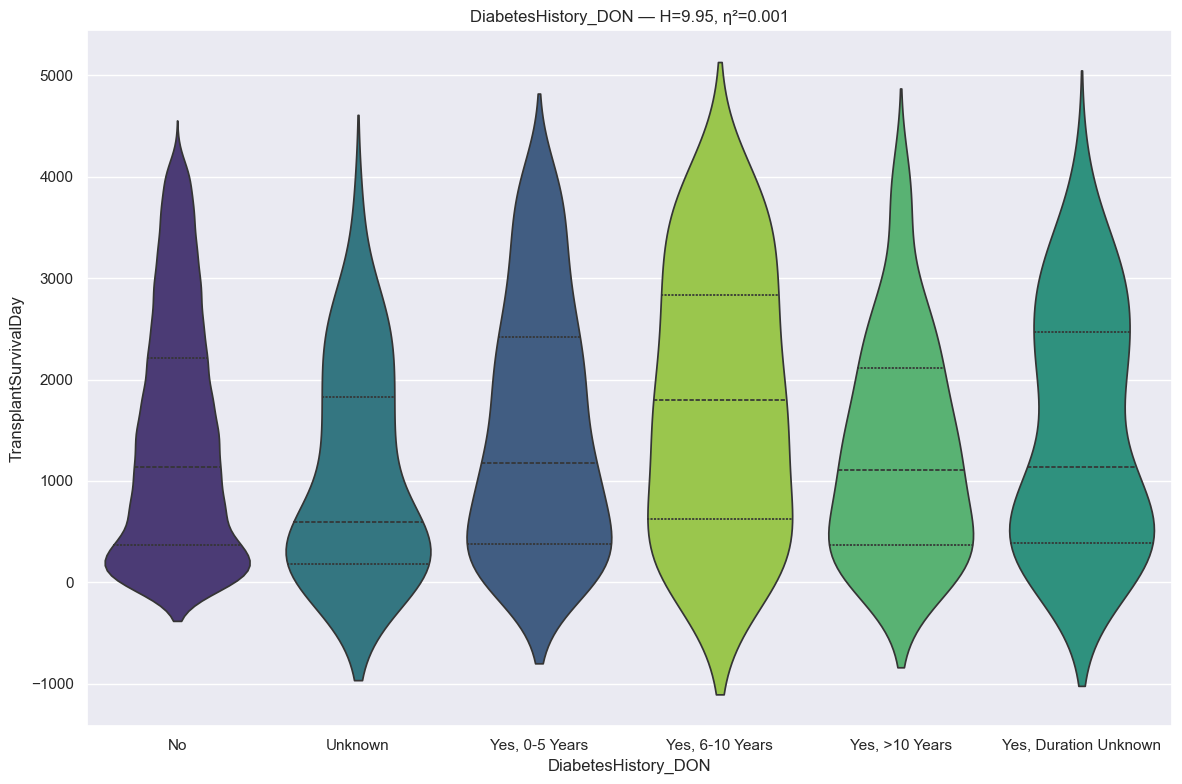

RANKING REPORT: DiabetesHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8431 records
 * Unknown                                           :     42 records
 * Yes, 0-5 Years                                    :    244 records
 * Yes, 6-10 Years                                   :     62 records
 * Yes, >10 Years                                    :     96 records
 * Yes, Duration Unknown                             :     58 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 9.9479 | P-value: 7.672545e-02 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes, 6-10 Years | p=7.0804e-03 | thr=0.0033 | r= 0.313 | Not Sig
Yes, 6-10 Years vs Yes, >10 Years | p=2.3969e-02 | thr=0.0033 | r=-0.213 | Not Sig
No    

In [143]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [144]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature has no statistically significant effect with no significant survival differences between categories except for one category, but with a small sample size. It is non-informative and should be removed.

#### Diabetes
* Diabetes is a chronic condition characterized by high blood sugar (glucose) levels caused by a lack of insulin or the body’s inability to use it properly. Type 2 is the most common form, driven by insulin resistance, lifestyle factors, and genetics, while Type 1 is autoimmune. Common symptoms include frequent urination, extreme thirst, unexplained weight loss, and fatigue. While there is no cure, it is managed through lifestyle changes (diet/exercise) and medication, with complications like heart disease, nerve damage, and kidney issues possible if poorly managed.

In [145]:
# info
feature = u.get_feature_info(df, 'Diabetes_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

             count unique top  freq
Diabetes_DON  8933      3  No  8431

:::: NaN Count:
Diabetes_DON    0 



{'Diabetes_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

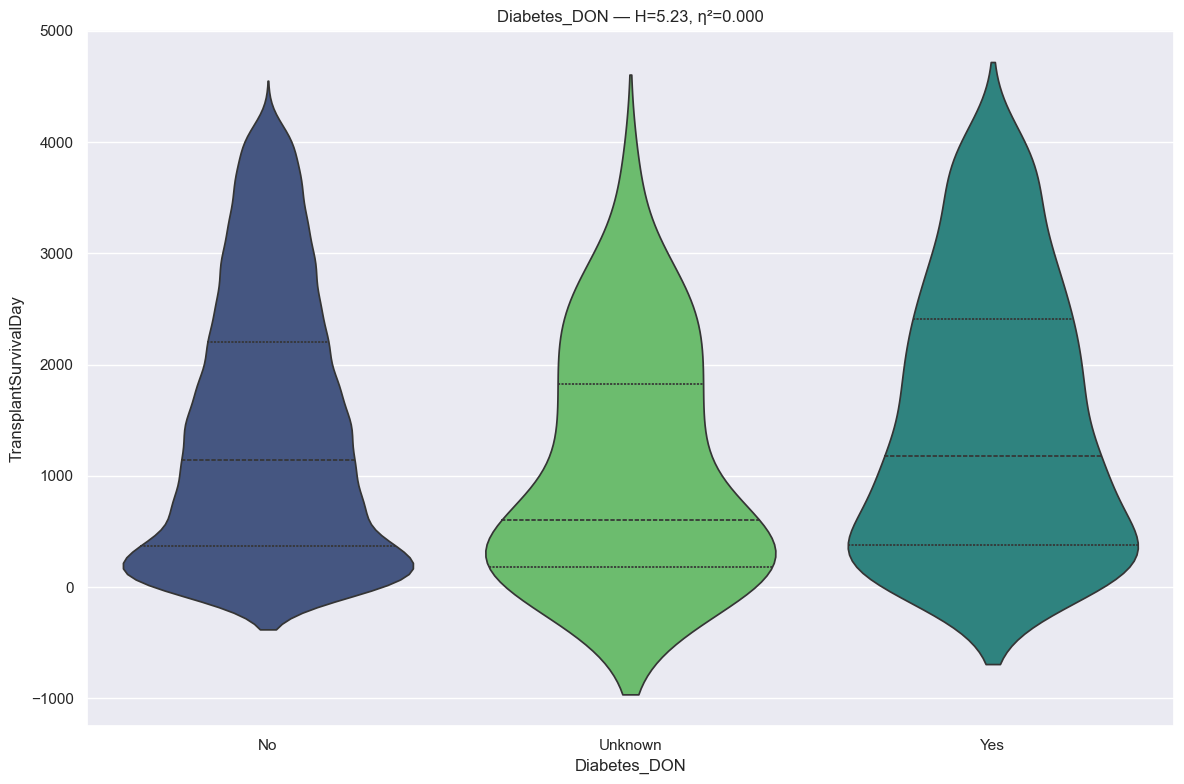

RANKING REPORT: Diabetes_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8431 records
 * Unknown                                           :     42 records
 * Yes                                               :    460 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 5.2251 | P-value: 7.334758e-02 | Effect η²: 0.0004
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=2.9905e-02 | thr=0.0167 | r= 0.202 | Not Sig
No           vs Unknown      | p=5.7233e-02 | thr=0.0167 | r=-0.170 | Not Sig
No           vs Yes          | p=2.1507e-01 | thr=0.0167 | r= 0.034 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2

In [146]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [147]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature has no statistically significant effect with no significant survival differences between categories except for one category, but with a small sample size. It is non-informative and should be removed.

#### Past Other Drug Use

In [148]:
# info
feature = u.get_feature_info(df, 'PastOtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
PastOtherDrugUse_DON  8933      3  No  4750

:::: NaN Count:
PastOtherDrugUse_DON    0 



{'PastOtherDrugUse_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

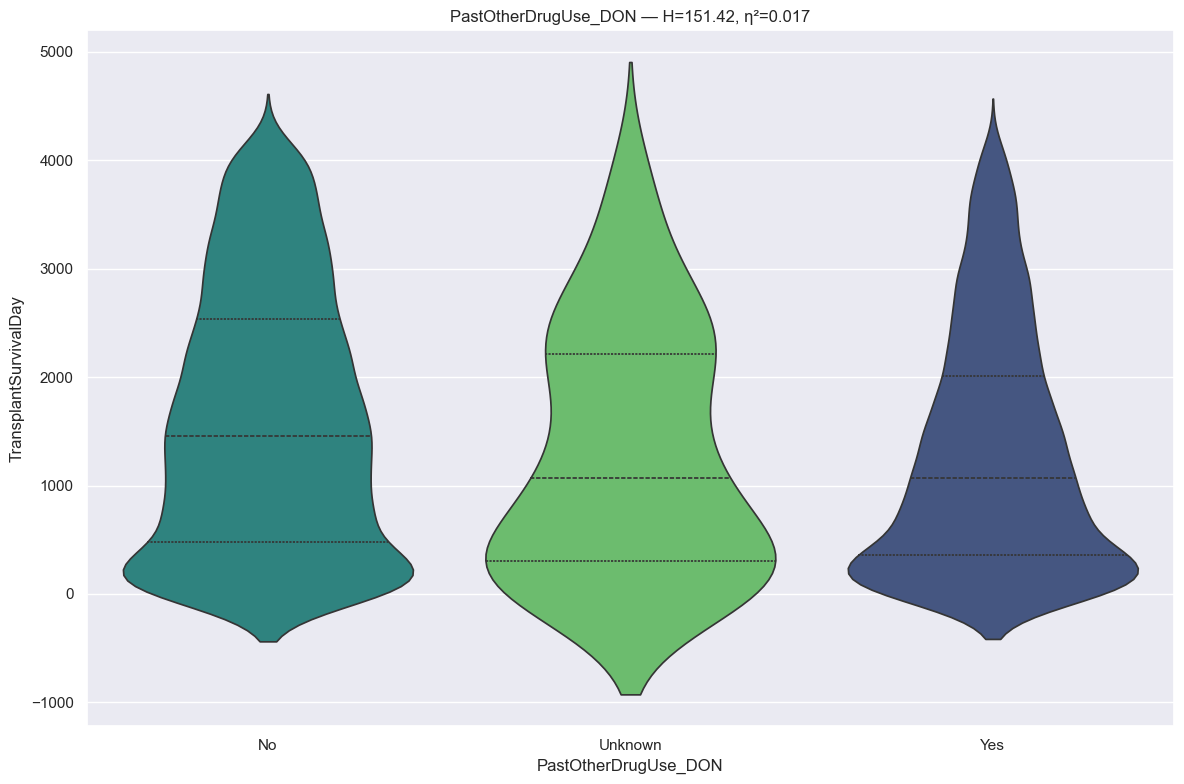

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4750 records
 * Unknown                                           :     92 records
 * Yes                                               :   4091 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 151.4249 | P-value: 1.313744e-33 | Effect η²: 0.0167
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.9287e-34 | thr=0.0167 | r=-0.151 | *Sig*
No           vs Unknown      | p=1.5435e-02 | thr=0.0167 | r=-0.147 | *Sig*
Unknown      vs Yes          | p=9.0145e-01 | thr=0.0167 | r= 0.008 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Grou

In [149]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [150]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": False,}  # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4750 records
 * Unknown                                           :     92 records
 * Yes                                               :   4091 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 151.4249 | P-value: 1.313744e-33 | Effect η²: 0.0167
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.9287e-34 | thr=0.0167 | r=-0.151 | *Sig*
No           vs Unknown      | p=1.5435e-02 | thr=0.0250 | r=-0.147 | *Sig*
Unknown      vs Yes          | p=9.0145e-01 | thr=0.0500 | r= 0.008 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Gro

In [151]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False,}  # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4750 records
 * Unknown                                           :     92 records
 * Yes                                               :   4091 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 151.4249 | P-value: 1.313744e-33 | Effect η²: 0.0167
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.9287e-34 | fdr_alpha=0.05 | r=-0.151 | *Sig*
No           vs Unknown      | p=1.5435e-02 | fdr_alpha=0.05 | r=-0.147 | *Sig*
Unknown      vs Yes          | p=9.0145e-01 | fdr_alpha=0.05 | r= 0.008 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES :::::::::::::::::::::::::::::

In [152]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer Skin

In [153]:
# info
feature = u.get_feature_info(df, 'CancerSkin', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
CancerSkin_DON  8933      3  No  8865

:::: NaN Count:
CancerSkin_DON    0 



{'CancerSkin_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

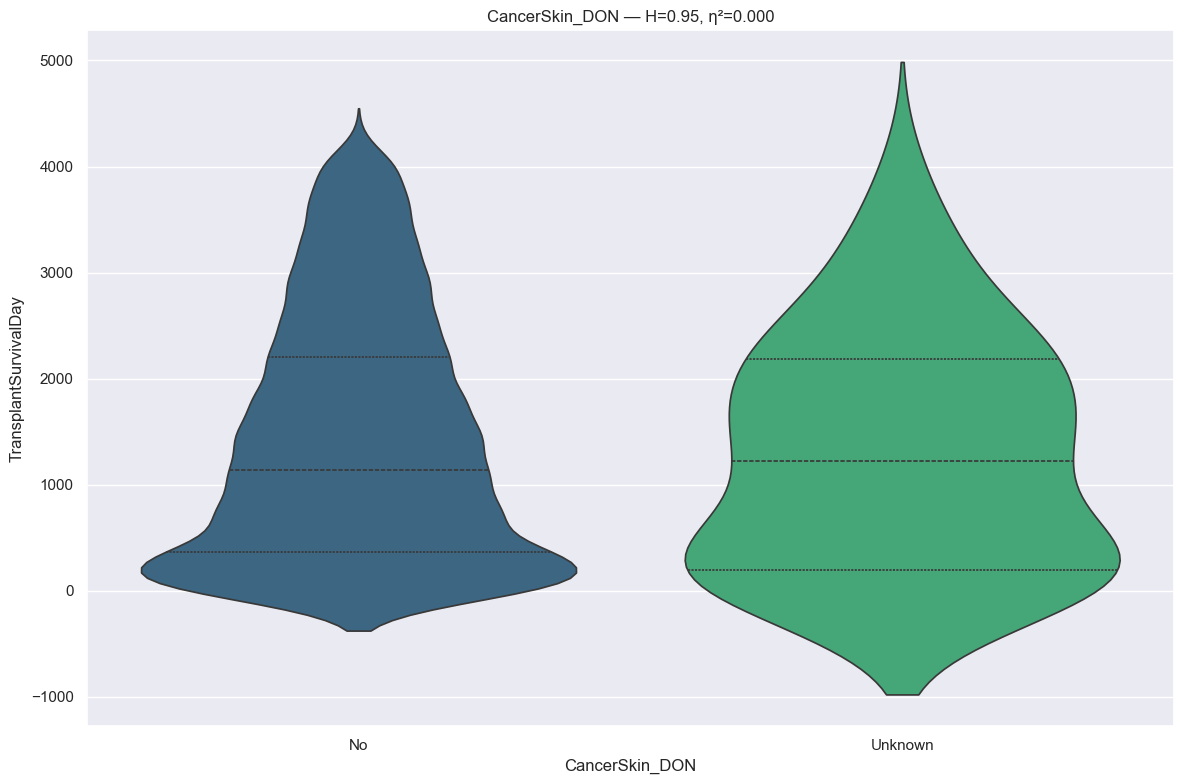

RANKING REPORT: CancerSkin_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8865 records
 * Unknown                                           :     57 records
BYPASSED CATEGORIES (n < min_n):
 * Yes                                               :     11 records
--------------------------------------------------------------------------------
Kruskal H: 0.9499 | P-value: 3.297471e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=3.2976e-01 | thr=0.0500 | r=-0.075 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (1 categories)
  - Yes

CancerSkin_DON  mean_survival_days  median_survival_days  maximum_survival_days 

In [154]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [155]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is uninformative for survival due to the extremely small number of positive cases and a negligible effect size.

#### Serology Anti CMV
* Serology Anti-CMV tests detect IgG and IgM antibodies to diagnose current, past, or reactivated Cytomegalovirus (CMV) infection. Typically measured by ELISA, IgM indicates recent infection, while IgG indicates past or latent infection and immunity. These tests are crucial for pregnant women, immunocompromised individuals, and transplant candidates

In [156]:
# info
feature = u.get_feature_info(df, 'SerologyAntiCMV', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top  freq
SerologyAntiCMV_DON  8933      5  Positive  6068

:::: NaN Count:
SerologyAntiCMV_DON    0 



{'SerologyAntiCMV_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Positive',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

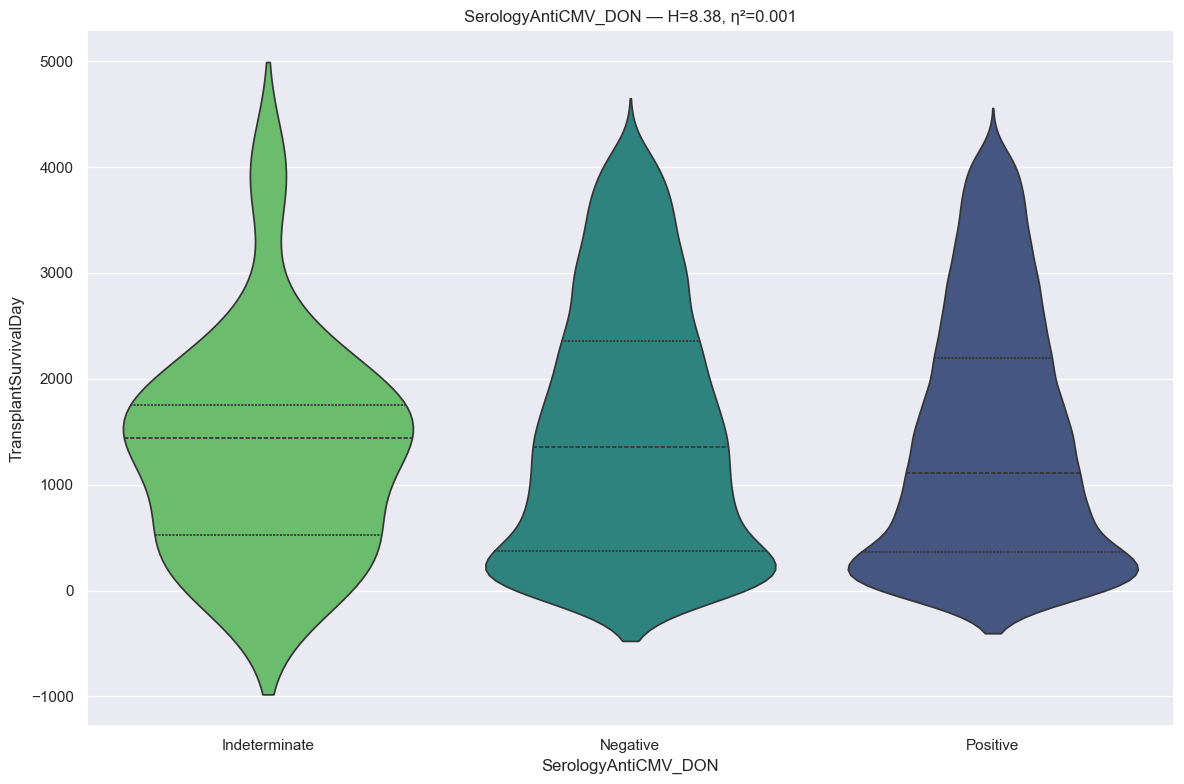

RANKING REPORT: SerologyAntiCMV_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     33 records
 * Negative                                          :   2822 records
 * Positive                                          :   6068 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      7 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 8.3771 | P-value: 1.516834e-02 | Effect η²: 0.0007
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=4.1858e-03 | thr=0.0167 | r=-0.038 | *Sig*
Indeterminate vs Negative     | p=4.8752e-01 | thr=0.0167 | r= 0.070 | Not Sig
Indeterminate vs Positive     | p=7.8244e-01 | thr=0.0167 | r= 0.028 | Not Sig

In [157]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [158]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is uninformative for survival due to the extremely small number of Not Done & Unknown cases and a negligible effect size.

#### Cause Of Death

In [159]:
# info
feature = u.get_feature_info(df, 'CauseOfDeath', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique     top  freq
CauseOfDeath_DON  8933      6  ANOXIA  3643

:::: NaN Count:
CauseOfDeath_DON    0 



{'CauseOfDeath_DON': CategoricalDtype(categories=['ANOXIA', 'CEREBROVASCULAR/STROKE', 'CNS TUMOR',
                   'HEAD TRAUMA', 'OTHER SPECIFY', 'Unknown'],
 , ordered=False, categories_dtype=object)}

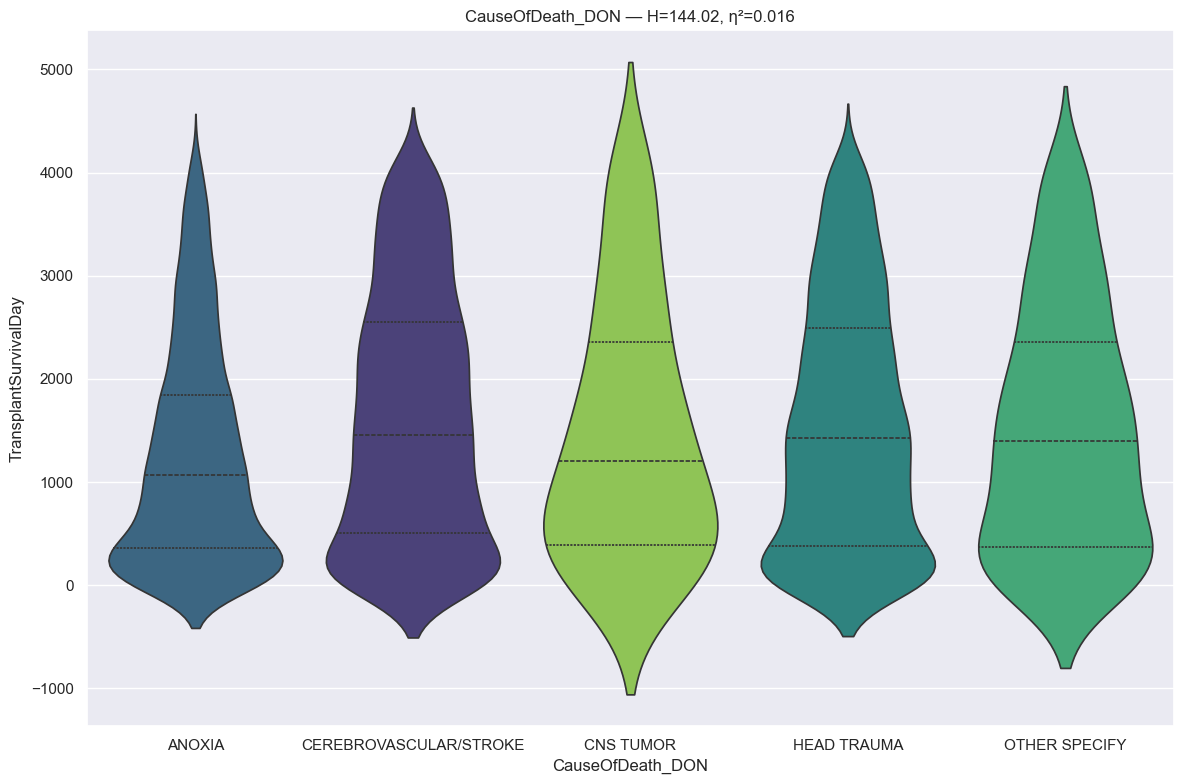

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3643 records
 * CEREBROVASCULAR/STROKE                            :   2476 records
 * CNS TUMOR                                         :     66 records
 * HEAD TRAUMA                                       :   2520 records
 * OTHER SPECIFY                                     :    227 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 144.0155 | P-value: 3.897694e-30 | Effect η²: 0.0157
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.0274e-28 | thr=0.0050 | r= 0.167 | *Sig*
ANOXIA       vs HEAD TRAUMA  | p=1.1325e-17 | thr=0.0050 | r= 0.128 | *Sig*
AN

In [160]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [161]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3643 records
 * CEREBROVASCULAR/STROKE                            :   2476 records
 * CNS TUMOR                                         :     66 records
 * HEAD TRAUMA                                       :   2520 records
 * OTHER SPECIFY                                     :    227 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 144.0155 | P-value: 3.897694e-30 | Effect η²: 0.0157
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.0274e-28 | thr=0.0050 | r= 0.167 | *Sig*
ANOXIA       vs HEAD TRAUMA  | p=1.1325e-17 | thr=0.0056 | r= 0.128 | *Sig*
A

In [162]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3643 records
 * CEREBROVASCULAR/STROKE                            :   2476 records
 * CNS TUMOR                                         :     66 records
 * HEAD TRAUMA                                       :   2520 records
 * OTHER SPECIFY                                     :    227 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 144.0155 | P-value: 3.897694e-30 | Effect η²: 0.0157
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.0274e-28 | fdr_alpha=0.05 | r= 0.167 | *Sig*
ANOXIA       vs HEAD TRAUMA  | p=1.1325e-17 | fdr_alpha=0.05 | r= 0.128 | *

In [163]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Synthetic AntiDiuretic Hormone
* Synthetic Antidiuretic Hormone (ADH), or vasopressin, mimics the natural hormone to manage body water balance by increasing water reabsorption in the kidneys. Common synthetic forms include vasopressin and desmopressin (DDAVP), which are used to treat diabetes insipidus, nocturnal enuresis, and low blood pressure. These drugs are essential to maintain fluid homeostasis, often administered intravenously or intranasally.

In [164]:
# info
feature = u.get_feature_info(df, 'SyntheticAntiDiureticHormone', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                 count unique top  freq
SyntheticAntiDiureticHormone_DON  8933      3  No  7664

:::: NaN Count:
SyntheticAntiDiureticHormone_DON    0 



{'SyntheticAntiDiureticHormone_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

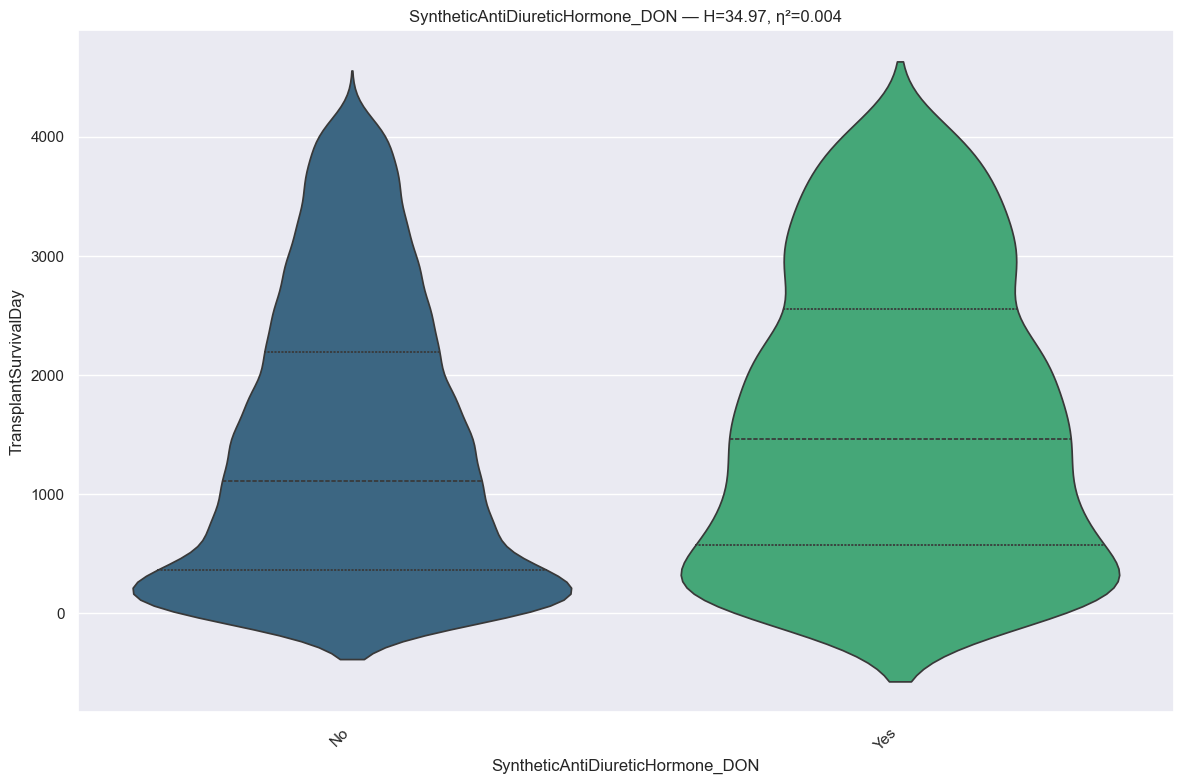

RANKING REPORT: SyntheticAntiDiureticHormone_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7664 records
 * Yes                                               :   1251 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     18 records
--------------------------------------------------------------------------------
Kruskal H: 34.9721 | P-value: 3.344665e-09 | Effect η²: 0.0038
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

SyntheticAntiDiureticHormone_DON  mean_survival_days  median_survival_d

In [165]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [166]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Death Circumstance

In [167]:
# info
feature = u.get_feature_info(df, 'DeathCircumstance', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique                        top  freq
DeathCircumstance_DON  8933      8  DEATH FROM NATURAL CAUSES  3305

:::: NaN Count:
DeathCircumstance_DON    0 



{'DeathCircumstance_DON': CategoricalDtype(categories=['Accident, Non-MVA', 'CHILD-ABUSE',
                   'DEATH FROM NATURAL CAUSES', 'HOMICIDE', 'MVA',
                   'NONE OF THE ABOVE', 'SUICIDE', 'Unknown'],
 , ordered=False, categories_dtype=object)}

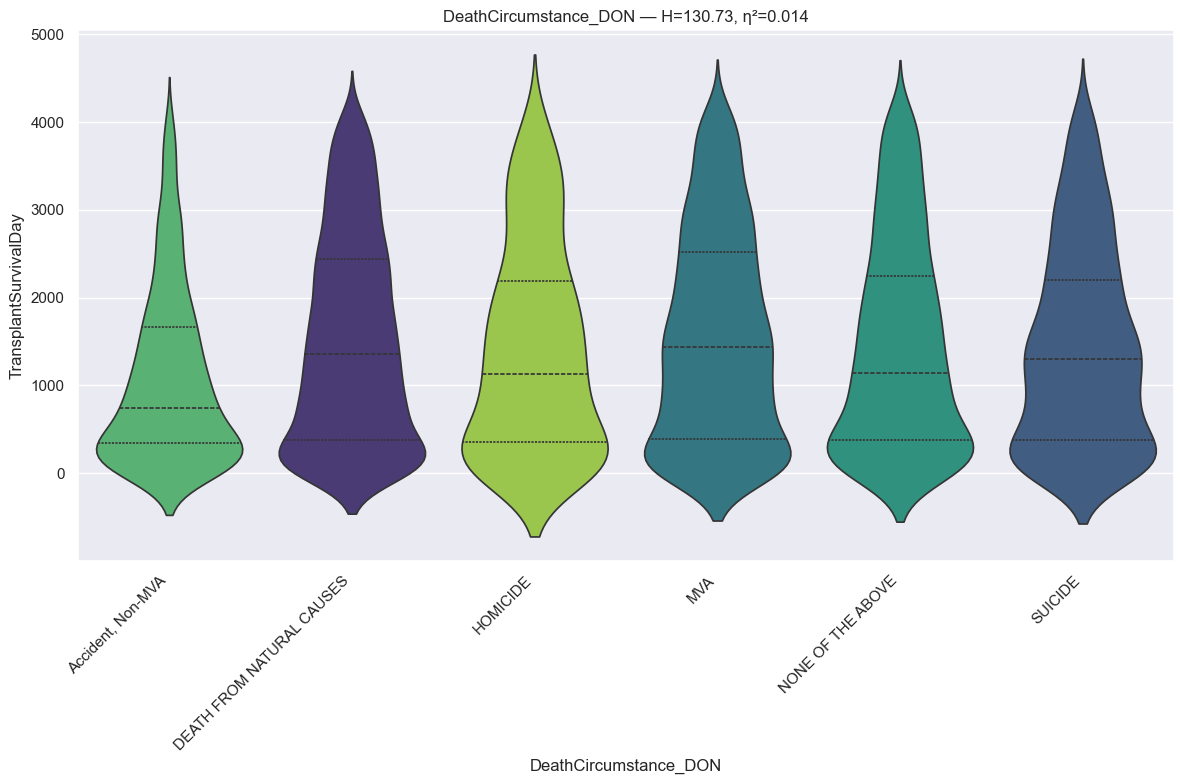

RANKING REPORT: DeathCircumstance_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Accident, Non-MVA                                 :   1242 records
 * DEATH FROM NATURAL CAUSES                         :   3305 records
 * HOMICIDE                                          :    373 records
 * MVA                                               :   1613 records
 * NONE OF THE ABOVE                                 :   1436 records
 * SUICIDE                                           :    958 records
BYPASSED CATEGORIES (n < min_n):
 * CHILD-ABUSE                                       :      1 records
 * Unknown                                           :      5 records
--------------------------------------------------------------------------------
Kruskal H: 130.7317 | P-value: 1.664520e-26 | Effect η²: 0.0141
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Accident, Non-MVA v

In [168]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [169]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: DeathCircumstance_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Accident, Non-MVA                                 :   1242 records
 * DEATH FROM NATURAL CAUSES                         :   3305 records
 * HOMICIDE                                          :    373 records
 * MVA                                               :   1613 records
 * NONE OF THE ABOVE                                 :   1436 records
 * SUICIDE                                           :    958 records
BYPASSED CATEGORIES (n < min_n):
 * CHILD-ABUSE                                       :      1 records
 * Unknown                                           :      5 records
--------------------------------------------------------------------------------
Kruskal H: 130.7317 | P-value: 1.664520e-26 | Effect η²: 0.0141
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
Accident, Non-MVA 

In [170]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Death Mechanism

In [171]:
# info
feature = u.get_feature_info(df, 'DeathMechanism', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique                             top  freq
DeathMechanism_DON  8933     13  INTRACRANIAL HEMORRHAGE/STROKE  2524

:::: NaN Count:
DeathMechanism_DON    0 



{'DeathMechanism_DON': CategoricalDtype(categories=['ASPHYXIATION', 'BLUNT INJURY', 'CARDIOVASCULAR',
                   'DEATH FROM NATURAL CAUSES', 'DROWNING', 'DRUG INTOXICATION',
                   'ELECTRICAL', 'GUNSHOT WOUND',
                   'INTRACRANIAL HEMORRHAGE/STROKE', 'NONE OF THE ABOVE',
                   'SEIZURE', 'STAB', 'Unknwn'],
 , ordered=False, categories_dtype=object)}

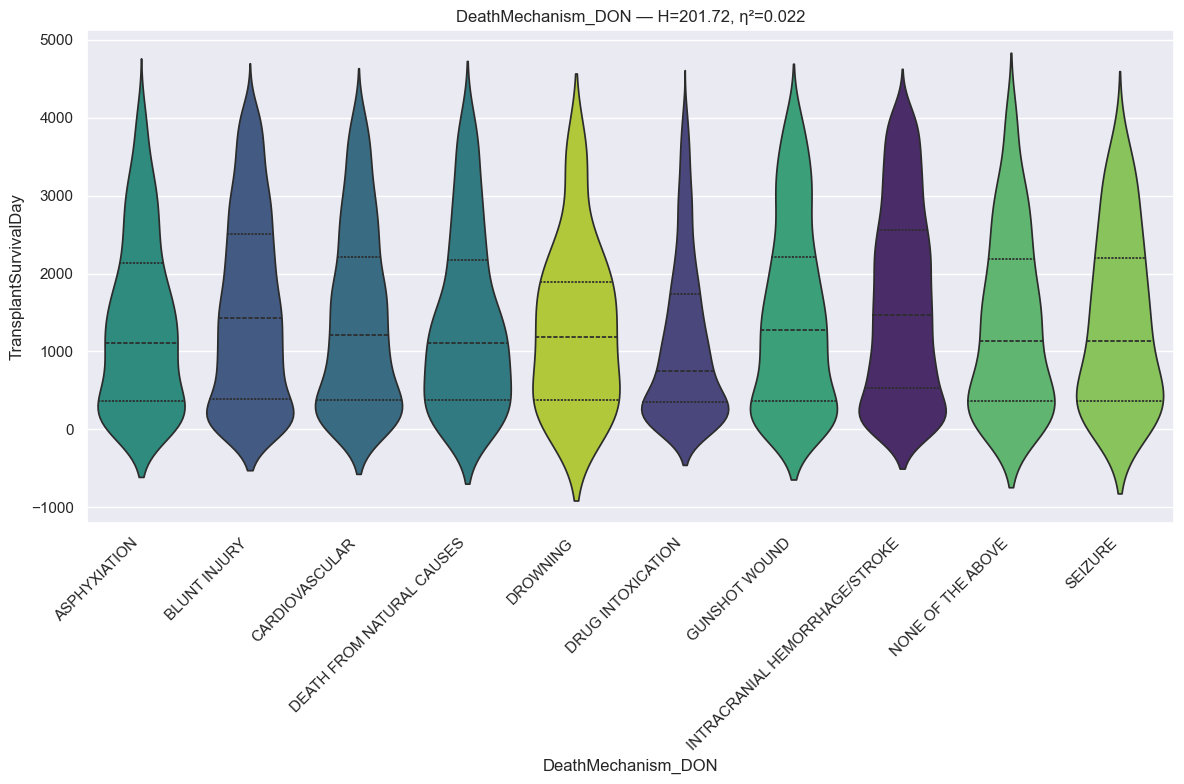

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    532 records
 * BLUNT INJURY                                      :   1819 records
 * CARDIOVASCULAR                                    :   1001 records
 * DEATH FROM NATURAL CAUSES                         :    317 records
 * DROWNING                                          :     58 records
 * DRUG INTOXICATION                                 :   1667 records
 * GUNSHOT WOUND                                     :    639 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2524 records
 * NONE OF THE ABOVE                                 :    239 records
 * SEIZURE                                           :    125 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * STAB                                              :      8 records
 * Unknwn                                            :      3 

In [172]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [173]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    532 records
 * BLUNT INJURY                                      :   1819 records
 * CARDIOVASCULAR                                    :   1001 records
 * DEATH FROM NATURAL CAUSES                         :    317 records
 * DROWNING                                          :     58 records
 * DRUG INTOXICATION                                 :   1667 records
 * GUNSHOT WOUND                                     :    639 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2524 records
 * NONE OF THE ABOVE                                 :    239 records
 * SEIZURE                                           :    125 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * STAB                                              :      8 records
 * Unknwn                                            :      3 

In [174]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Heparin Management
* Heparin is a fast-acting, injectable anticoagulant ("blood thinner") used to treat or prevent blood clots in conditions like deep vein thrombosis (DVT), pulmonary embolism, and atrial fibrillation. It works by inhibiting coagulation factors, with intravenous (IV) administration taking effect immediately and subcutaneous injections taking 1-2 hours to take effect. Major risks include bleeding, skin irritation, and rare HIT syndrome. 

In [175]:
# info
feature = u.get_feature_info(df, 'HeparinManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top  freq
HeparinManagement_DON  8933      3  Yes  8772

:::: NaN Count:
HeparinManagement_DON    0 



{'HeparinManagement_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

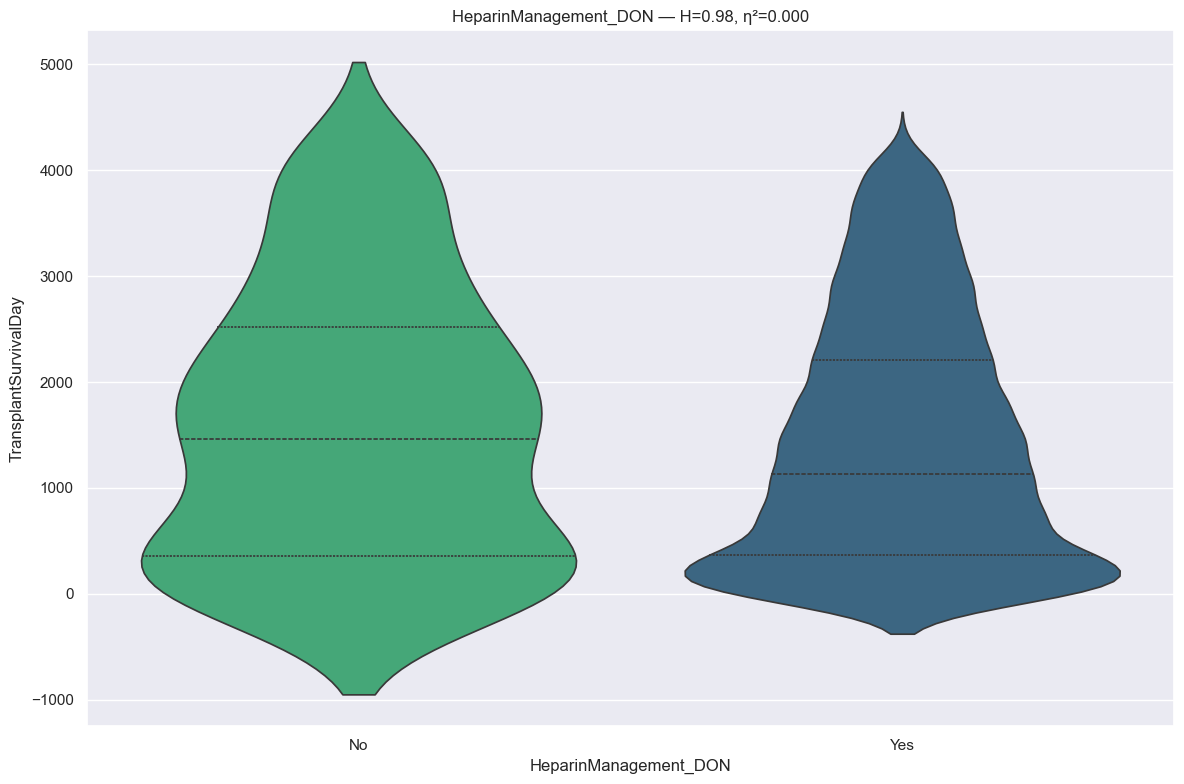

RANKING REPORT: HeparinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    147 records
 * Yes                                               :   8772 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 0.9833 | P-value: 3.213741e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.2138e-01 | thr=0.0500 | r=-0.048 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Unknown

HeparinManagement_DON  mean_survival_days  median_survival_days  maximum_

In [176]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [177]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is not statistically significant and uninformative for survival due to the negligible effect size of Unknown cases.

#### Arginnie Management
* L-arginine is an amino acid used to manage cardiovascular conditions like high blood pressure, angina, and erectile dysfunction by promoting vasodilation (widening of blood vessels) via nitric oxide production. Generally safe, daily doses often range from 2.5 to 9 grams, with potential benefits for metabolic health, wound healing, and immune support, though long-term efficacy is not fully established.

In [178]:
# info
feature = u.get_feature_info(df, 'ArginnieManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top  freq
ArginnieManagement_DON  8933      3  Yes  5908

:::: NaN Count:
ArginnieManagement_DON    0 



{'ArginnieManagement_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

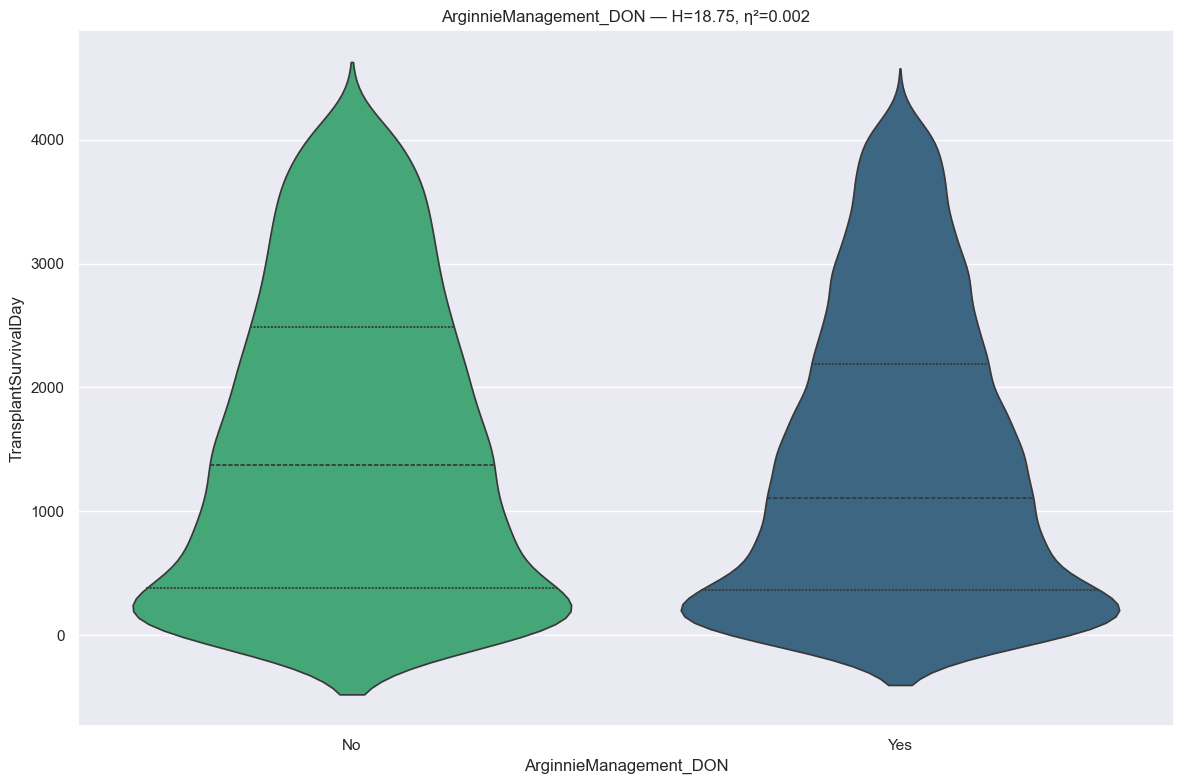

RANKING REPORT: ArginnieManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3009 records
 * Yes                                               :   5908 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     16 records
--------------------------------------------------------------------------------
Kruskal H: 18.7473 | P-value: 1.492352e-05 | Effect η²: 0.0020
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.4924e-05 | thr=0.0500 | r=-0.056 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

ArginnieManagement_DON  mean_survival_days  m

In [179]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [180]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Insulin Management
* Insulin management involves matching insulin type and dosage to blood sugar levels, diet, and activity, typically using a basal-bolus regimen (long-acting for background, rapid-acting for meals) via pens, syringes, or pumps. Effective management requires regular glucose monitoring to adjust doses, prevent hypoglycemia, and reduce complications.

In [181]:
# info
feature = u.get_feature_info(df, 'InsulinManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top  freq
InsulinManagement_DON  8933      3  Yes  5417

:::: NaN Count:
InsulinManagement_DON    0 



{'InsulinManagement_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

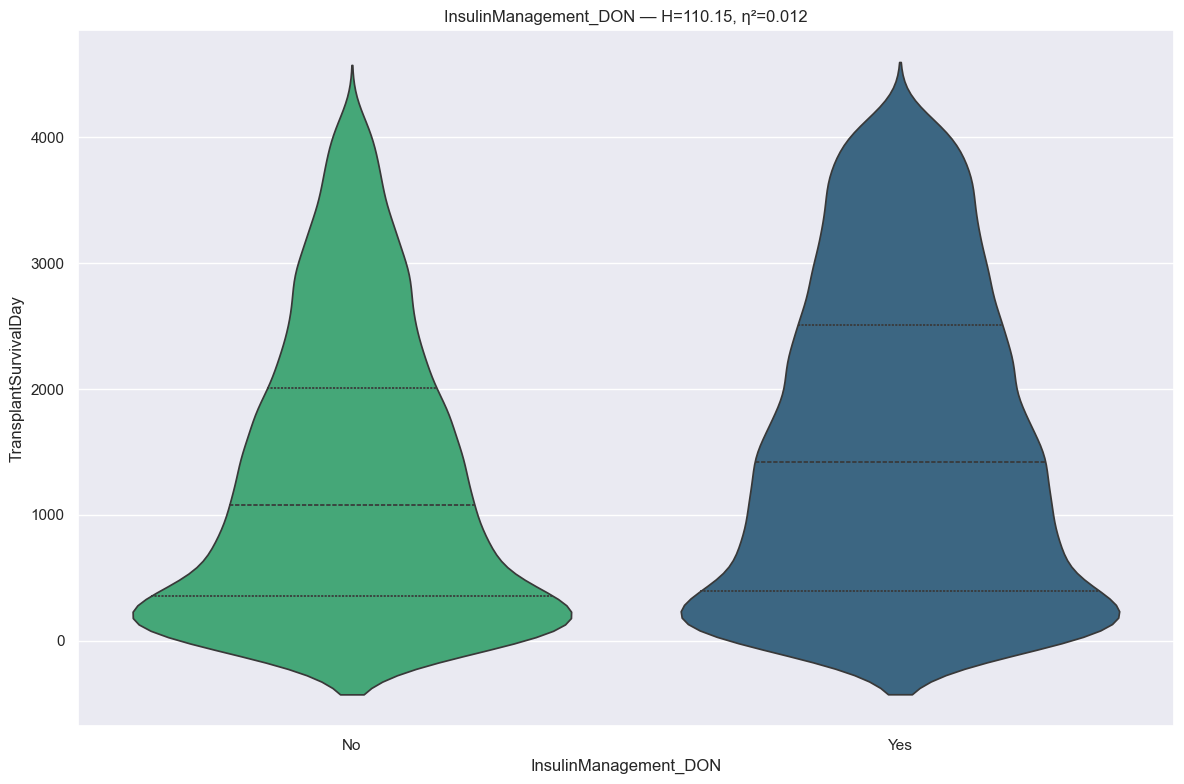

RANKING REPORT: InsulinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3498 records
 * Yes                                               :   5417 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     18 records
--------------------------------------------------------------------------------
Kruskal H: 110.1479 | P-value: 9.094497e-26 | Effect η²: 0.0122
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=9.0949e-26 | thr=0.0500 | r= 0.131 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

InsulinManagement_DON  mean_survival_days  me

In [182]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [183]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HBV NAT Result
* HBV NAT (Nucleic Acid Testing) for identifying Hepatitis B virus DNA in blood, plasma, or organs. A positive NAT result indicates the presence of HBV DNA, signaling active infection (often during the window period before antibodies appear). 

In [184]:
# info
feature = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
HBV_NAT_Result_DON  8933      4  Negative  5716

:::: NaN Count:
HBV_NAT_Result_DON    0 



{'HBV_NAT_Result_DON': CategoricalDtype(categories=['Negative', 'Not Done', 'Positive', 'Unknown'], ordered=False, categories_dtype=object)}

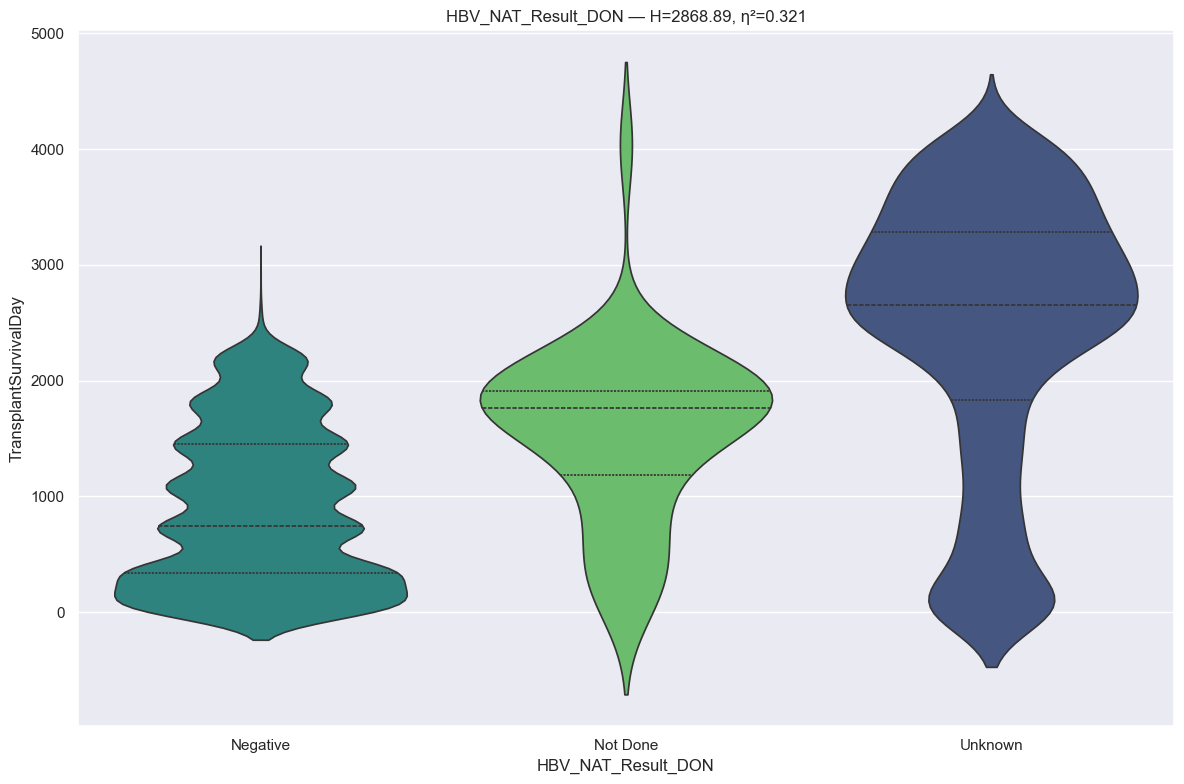

RANKING REPORT: HBV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   5716 records
 * Not Done                                          :     40 records
 * Unknown                                           :   3175 records
BYPASSED CATEGORIES (n < min_n):
 * Positive                                          :      2 records
--------------------------------------------------------------------------------
Kruskal H: 2868.8914 | P-value: 0.000000e+00 | Effect η²: 0.3211
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Unknown      | p=0.0000e+00 | thr=0.0167 | r= 0.683 | *Sig*
Not Done     vs Unknown      | p=1.1439e-08 | thr=0.0167 | r= 0.524 | *Sig*
Negative     vs Not Done     | p=7.4355e-08 | thr=0.0167 | r= 0.493 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::

In [185]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [186]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HCV NAT Result
* An HCV NAT (Nucleic Acid Test/PCR) result confirms active hepatitis C infection by detecting the virus's genetic material (RNA). A positive result means current infection (usually 1-2 weeks after exposure) requiring treatment. A negative result indicates no current virus in the blood (no active infection).

In [187]:
# info
feature = u.get_feature_info(df, 'HCV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
HCV_NAT_Result_DON  8933      4  Negative  5522

:::: NaN Count:
HCV_NAT_Result_DON    0 



{'HCV_NAT_Result_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Positive',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

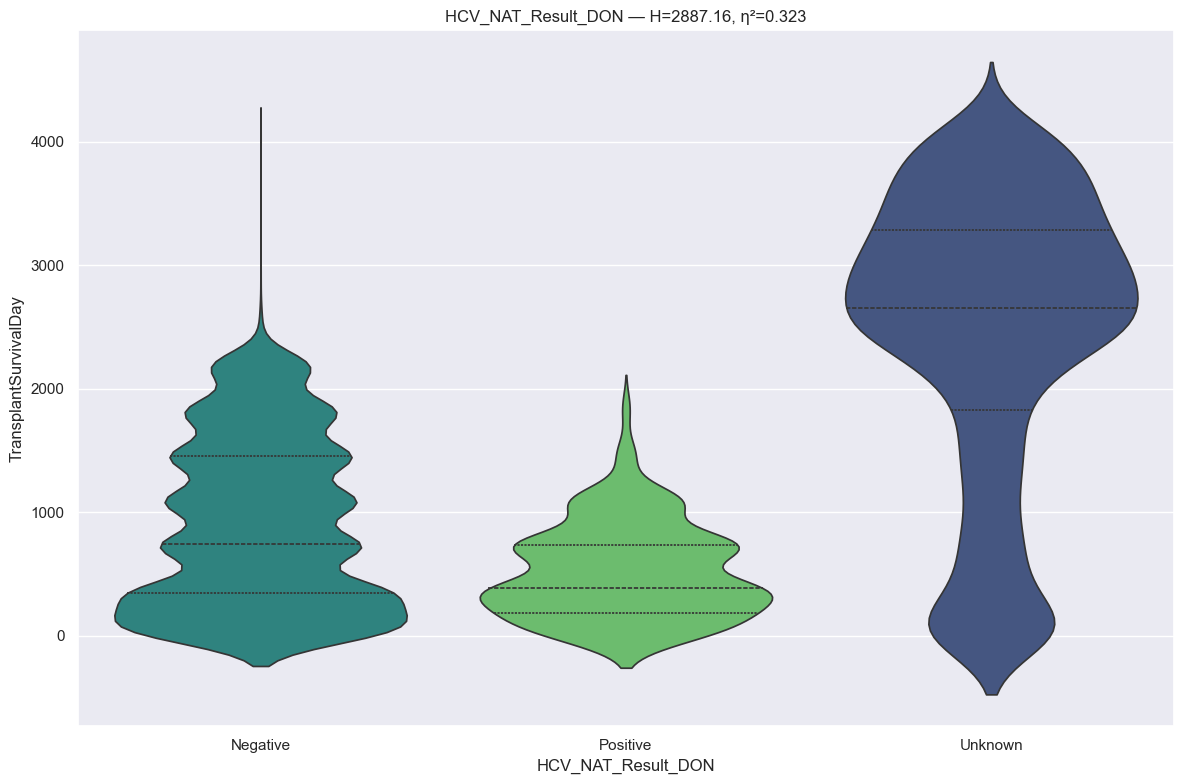

RANKING REPORT: HCV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   5522 records
 * Positive                                          :    229 records
 * Unknown                                           :   3174 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      8 records
--------------------------------------------------------------------------------
Kruskal H: 2887.1568 | P-value: 0.000000e+00 | Effect η²: 0.3234
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Unknown      | p=0.0000e+00 | thr=0.0167 | r= 0.679 | *Sig*
Positive     vs Unknown      | p=2.5837e-81 | thr=0.0167 | r= 0.755 | *Sig*
Negative     vs Positive     | p=5.1958e-15 | thr=0.0167 | r=-0.305 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::

In [188]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [189]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HIV NAT Result
* An HIV Nucleic Acid Test (NAT) (or RNA test) detects the virus directly in the blood, often within 10–33 days of exposure. A negative result after the window period means you are likely not living with HIV. A positive NAT (often used for confirmation or early detection) detects the presence of the virus (viral load).

In [190]:
# info
feature = u.get_feature_info(df, 'HIV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
HIV_NAT_Result_DON  8933      3  Negative  5735

:::: NaN Count:
HIV_NAT_Result_DON    0 



{'HIV_NAT_Result_DON': CategoricalDtype(categories=['Negative', 'Not Done', 'Unknown'], ordered=False, categories_dtype=object)}

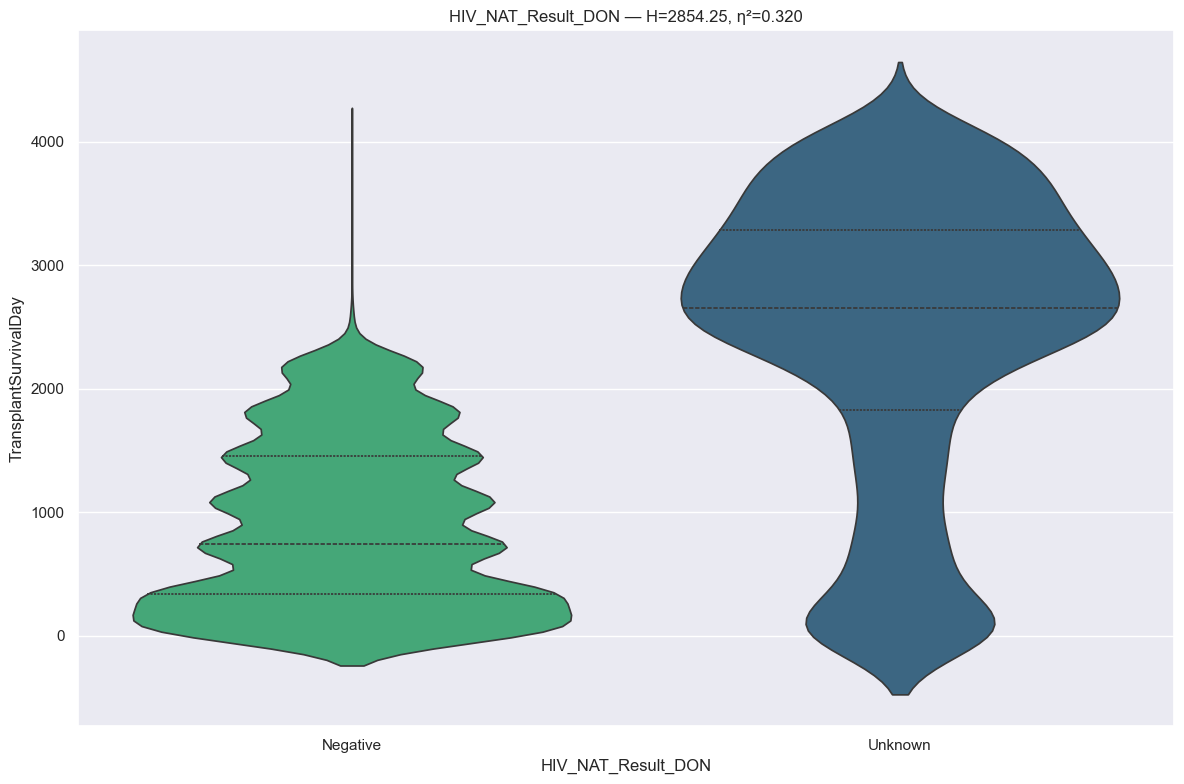

RANKING REPORT: HIV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   5735 records
 * Unknown                                           :   3174 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :     24 records
--------------------------------------------------------------------------------
Kruskal H: 2854.2468 | P-value: 0.000000e+00 | Effect η²: 0.3203
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Unknown      | p=0.0000e+00 | thr=0.0500 | r= 0.682 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

>>> Group_2 (1 categories)
  - Unknown

>>> Other (1 categories)
  - Not Done

HIV_NAT_Result_DON  mean_survival_da

In [191]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [192]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Allocation Type

In [193]:
# info
feature = u.get_feature_info(df, 'AllocationType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique    top  freq
AllocationType_DON  8933      4  Local  4042

:::: NaN Count:
AllocationType_DON    0 



{'AllocationType_DON': CategoricalDtype(categories=['Foreign Donor', 'Local', 'National', 'Regional'], ordered=False, categories_dtype=object)}

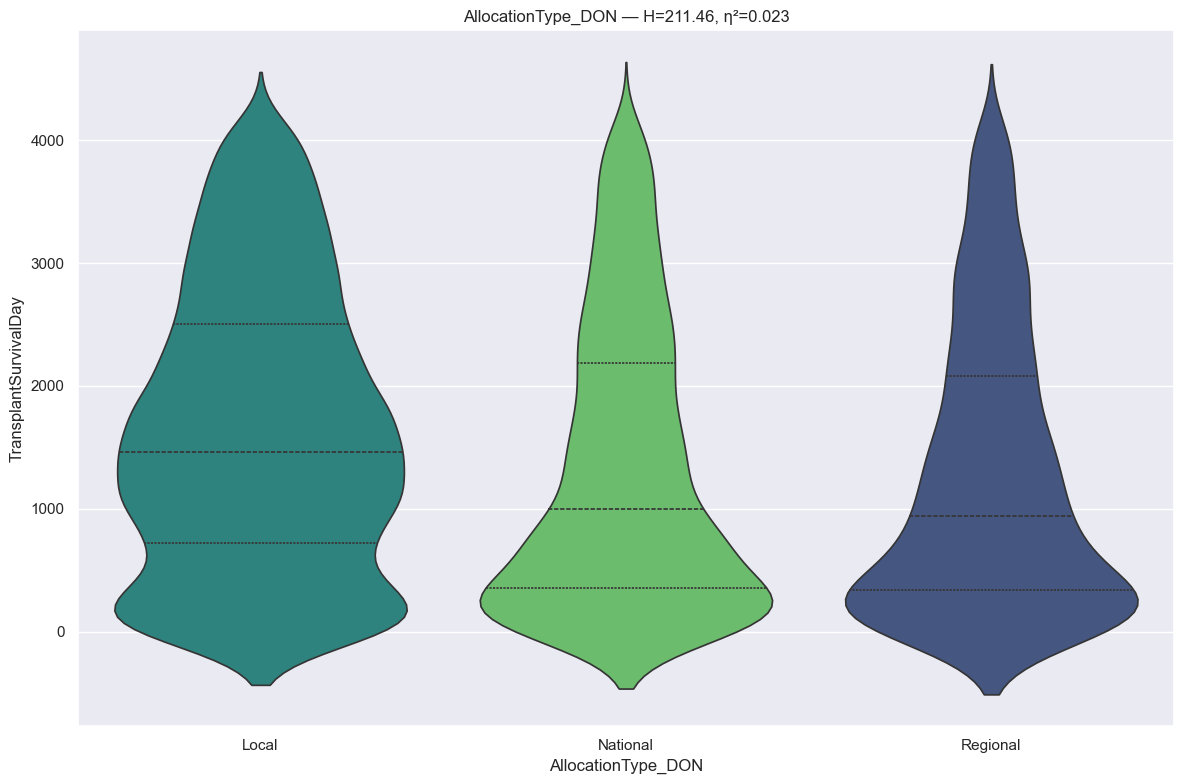

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :   4042 records
 * National                                          :   3141 records
 * Regional                                          :   1741 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :      9 records
--------------------------------------------------------------------------------
Kruskal H: 211.4575 | P-value: 1.209456e-46 | Effect η²: 0.0235
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Local        vs National     | p=2.1115e-33 | thr=0.0167 | r=-0.165 | *Sig*
Local        vs Regional     | p=5.1898e-33 | thr=0.0167 | r=-0.198 | *Sig*
National     vs Regional     | p=6.3662e-02 | thr=0.0167 | r=-0.032 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::

In [194]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [195]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04,"suppress_pairwise": False }  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :   4042 records
 * National                                          :   3141 records
 * Regional                                          :   1741 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :      9 records
--------------------------------------------------------------------------------
Kruskal H: 211.4575 | P-value: 1.209456e-46 | Effect η²: 0.0235
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
Local        vs National     | p=2.1115e-33 | fdr_alpha=0.05 | r=-0.165 | *Sig*
Local        vs Regional     | p=5.1898e-33 | fdr_alpha=0.05 | r=-0.198 | *Sig*
National     vs Regional     | p=6.3662e-02 | fdr_alpha=0.05 | r=-0.032 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::

In [196]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Urine Protein
* Urine protein (proteinuria) is an excess of protein, usually albumin, in the urine, with normal levels being less than 150 mg per day. It is often a sign of kidney damage or disease (e.g., diabetes, high blood pressure). It is usually diagnosed via a urinalysis (dipstick or lab test) and often causes no symptoms early on, though foamy urine or swelling (edema) in hands/feet can occur.

In [197]:
# info
feature = u.get_feature_info(df, 'UrineProtein', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique top  freq
UrineProtein_DON  8933      3  No  4976

:::: NaN Count:
UrineProtein_DON    0 



{'UrineProtein_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

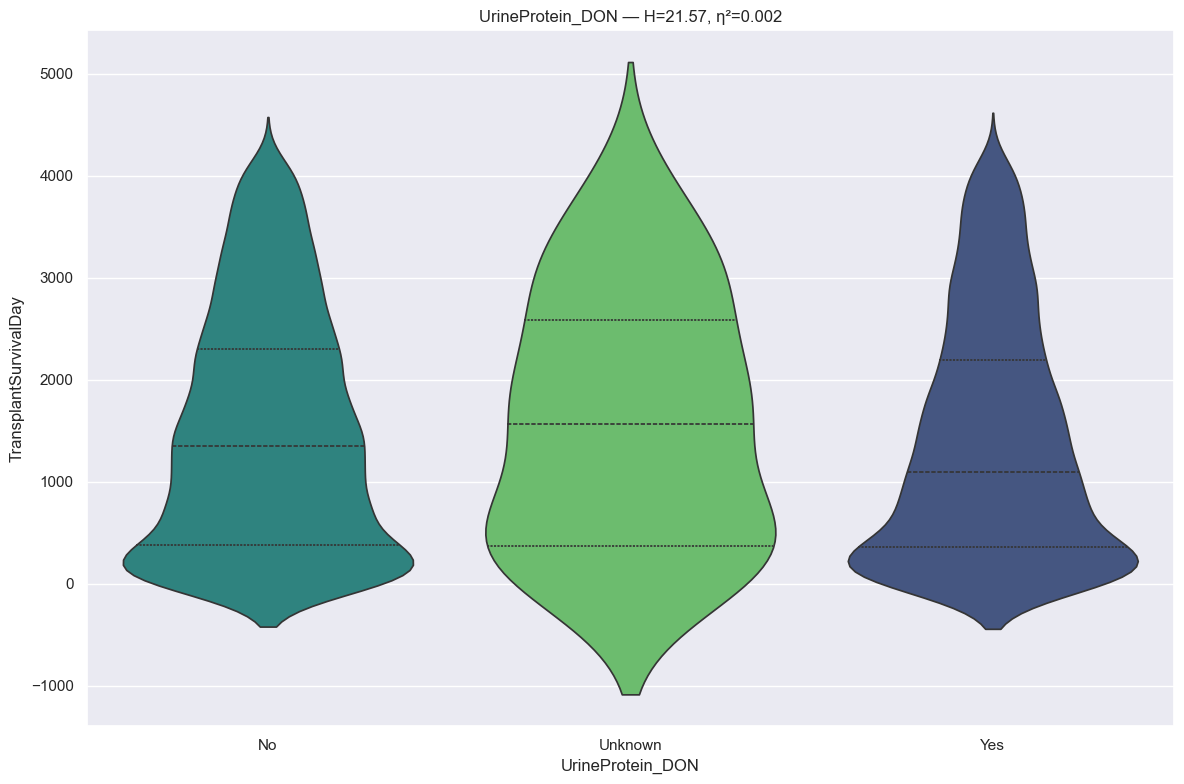

RANKING REPORT: UrineProtein_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4976 records
 * Unknown                                           :     56 records
 * Yes                                               :   3901 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 21.5716 | P-value: 2.069102e-05 | Effect η²: 0.0022
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.7368e-06 | thr=0.0167 | r=-0.056 | *Sig*
Unknown      vs Yes          | p=1.7093e-01 | thr=0.0167 | r=-0.106 | Not Sig
No           vs Unknown      | p=4.6759e-01 | thr=0.0167 | r= 0.056 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1

In [198]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [199]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cardiac Arrest

In [200]:
# info
feature = u.get_feature_info(df, 'CardiacArrest', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique top  freq
CardiacArrest_DON  8933      3  No  8172

:::: NaN Count:
CardiacArrest_DON    0 



{'CardiacArrest_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

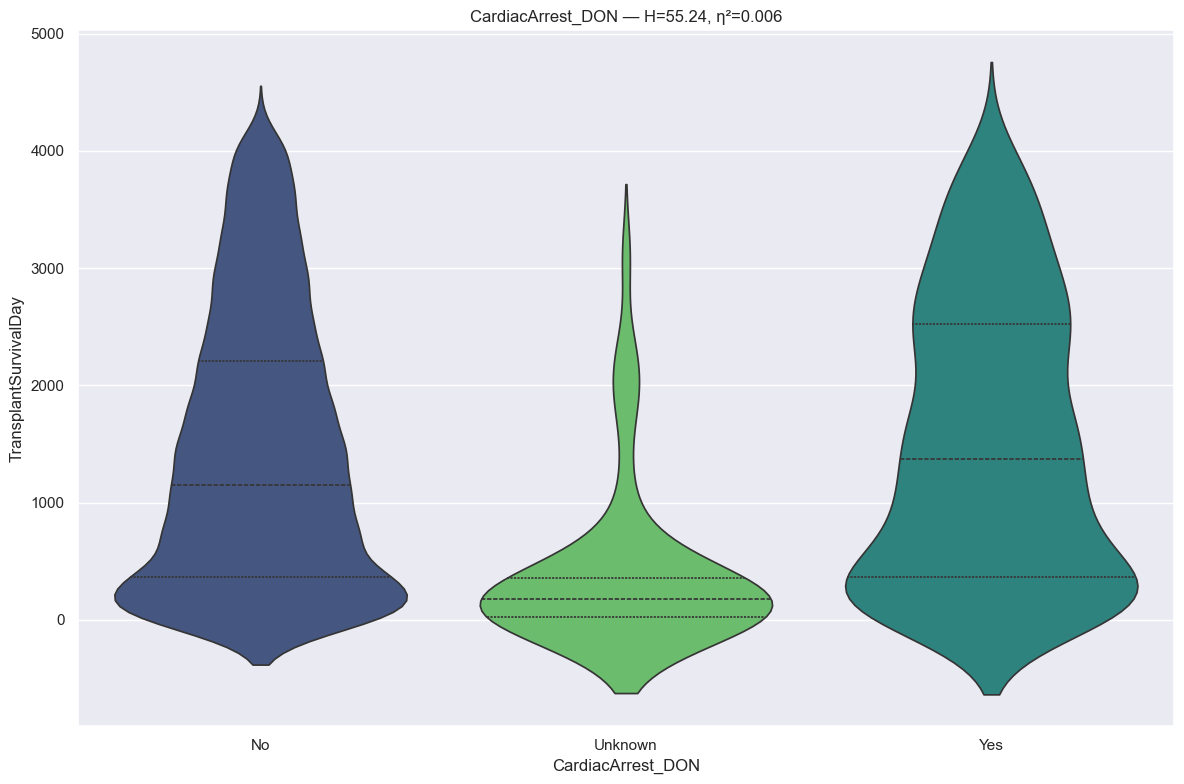

RANKING REPORT: CardiacArrest_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8172 records
 * Unknown                                           :     50 records
 * Yes                                               :    711 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 55.2356 | P-value: 1.013296e-12 | Effect η²: 0.0060
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.4877e-13 | thr=0.0167 | r=-0.605 | *Sig*
Unknown      vs Yes          | p=1.0875e-12 | thr=0.0167 | r= 0.602 | *Sig*
No           vs Yes          | p=4.0987e-01 | thr=0.0167 | r= 0.019 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 

In [201]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [202]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CardiacArrest_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8172 records
 * Unknown                                           :     50 records
 * Yes                                               :    711 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 55.2356 | P-value: 1.013296e-12 | Effect η²: 0.0060
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Group_2 (1 categories)
  - Unknown



In [203]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Myocardial Infarction History

In [204]:
# info
feature = u.get_feature_info(df, 'MyocardialInfarctionHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                count unique top  freq
MyocardialInfarctionHistory_DON  8933      3  No  8802

:::: NaN Count:
MyocardialInfarctionHistory_DON    0 



{'MyocardialInfarctionHistory_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

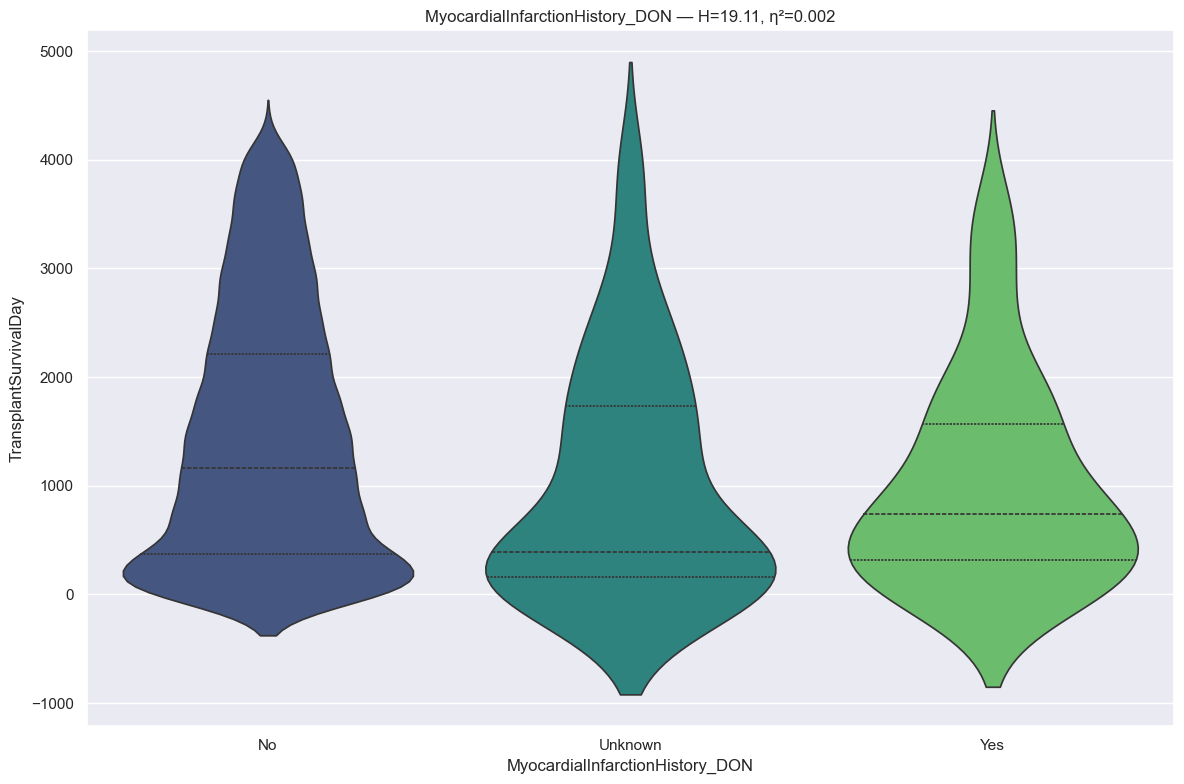

RANKING REPORT: MyocardialInfarctionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8802 records
 * Unknown                                           :     71 records
 * Yes                                               :     60 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 19.1068 | P-value: 7.096071e-05 | Effect η²: 0.0019
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=6.2333e-04 | thr=0.0167 | r=-0.235 | *Sig*
No           vs Yes          | p=6.0488e-03 | thr=0.0167 | r=-0.205 | *Sig*
Unknown      vs Yes          | p=5.2681e-01 | thr=0.0167 | r= 0.065 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

In [205]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [206]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: MyocardialInfarctionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8802 records
 * Unknown                                           :     71 records
 * Yes                                               :     60 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 19.1068 | P-value: 7.096071e-05 | Effect η²: 0.0019
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Unknown

>>> Group_3 (1 categories)
  - Yes



In [207]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### LV Ejection Fraction Medthod

In [208]:
# info
feature = u.get_feature_info(df, 'LV_EjectionFractionMedthod', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                               count unique   top  freq
LV_EjectionFractionMedthod_DON  8933      3  Echo  8697

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0 



{'LV_EjectionFractionMedthod_DON': CategoricalDtype(categories=['Angiogram', 'Echo', 'Unknown'], ordered=False, categories_dtype=object)}

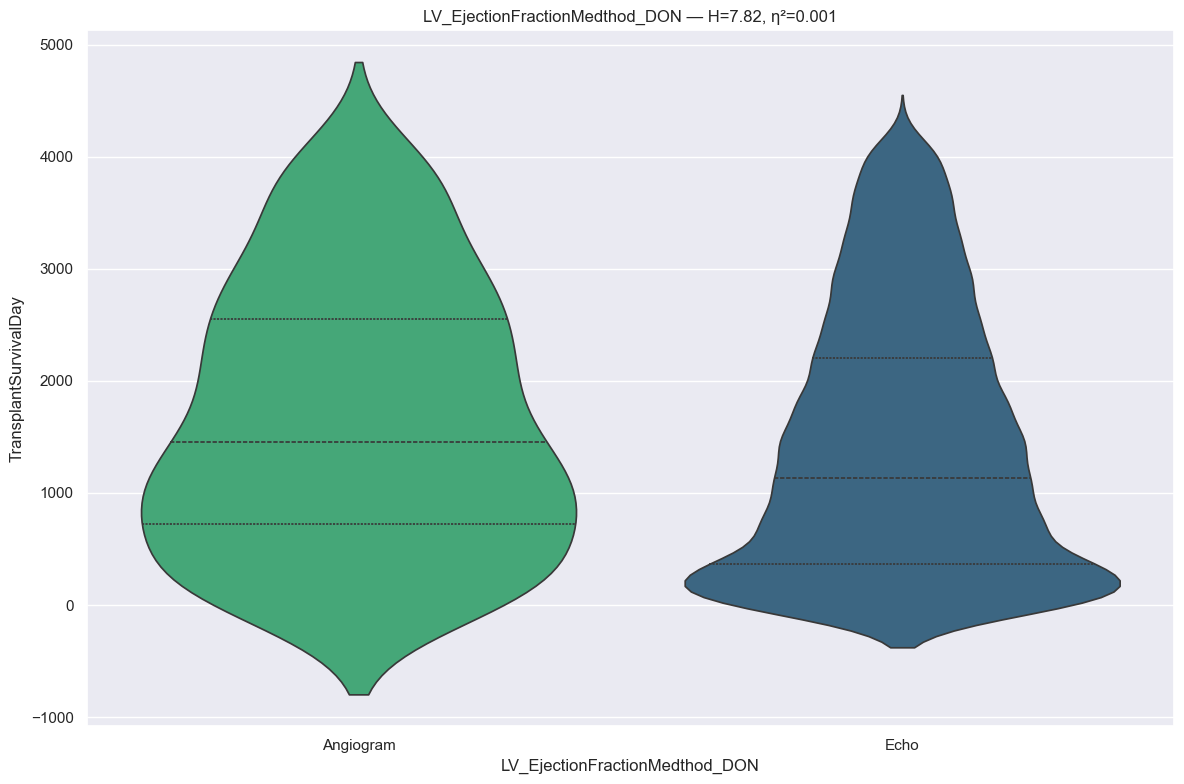

RANKING REPORT: LV_EjectionFractionMedthod_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Angiogram                                         :    224 records
 * Echo                                              :   8697 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 7.8184 | P-value: 5.171563e-03 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Angiogram    vs Echo         | p=5.1718e-03 | thr=0.0500 | r=-0.109 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Angiogram

>>> Group_2 (1 categories)
  - Echo

>>> Other (1 categories)
  - Unknown

LV_EjectionFractionMedthod_DON

In [209]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [210]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Coronary Angiogram

In [211]:
# info
feature = u.get_feature_info(df, 'CoronaryAngiogram', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top  freq
CoronaryAngiogram_DON  8933      4  No  5282

:::: NaN Count:
CoronaryAngiogram_DON    0 



{'CoronaryAngiogram_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes, normal', 'Yes, not normal'], ordered=False, categories_dtype=object)}

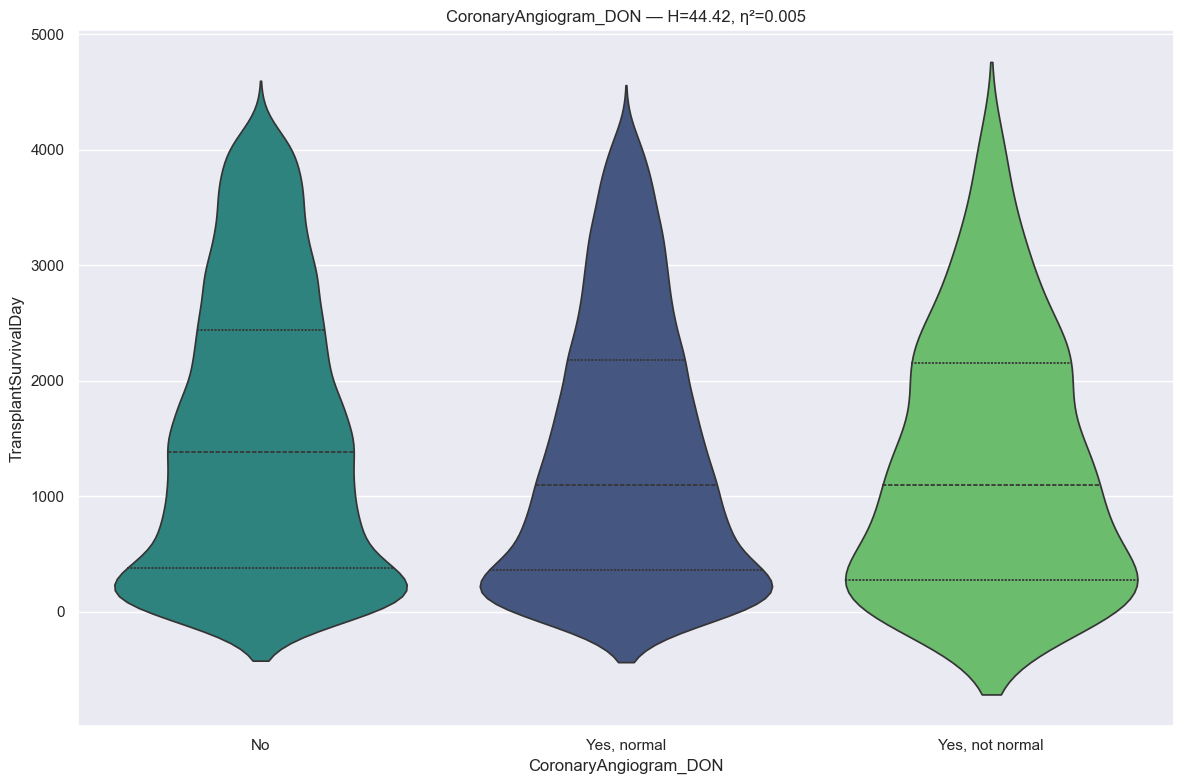

RANKING REPORT: CoronaryAngiogram_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5282 records
 * Yes, normal                                       :   3394 records
 * Yes, not normal                                   :    243 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 44.4209 | P-value: 2.260061e-10 | Effect η²: 0.0048
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes, normal  | p=6.5023e-10 | thr=0.0167 | r=-0.078 | *Sig*
No           vs Yes, not normal | p=1.0272e-03 | thr=0.0167 | r=-0.124 | *Sig*
Yes, normal  vs Yes, not normal | p=2.1790e-01 | thr=0.0167 | r=-0.047 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::

In [212]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [213]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CoronaryAngiogram_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5282 records
 * Yes, normal                                       :   3394 records
 * Yes, not normal                                   :    243 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 44.4209 | P-value: 2.260061e-10 | Effect η²: 0.0048
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
No           vs Yes, normal  | p=6.5023e-10 | fdr_alpha=0.05 | r=-0.078 | *Sig*
No           vs Yes, not normal | p=1.0272e-03 | fdr_alpha=0.05 | r=-0.124 | *Sig*
Yes, normal  vs Yes, not normal | p=2.1790e-01 | fdr_alpha=0.05 | r=-0.047 | Not Sig
::::: Collapsed into 3 groups (excluding 'Other') :::

In [214]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Biopsy

In [215]:
# info
feature = u.get_feature_info(df, 'Biopsy', cat=False)
# dtype
{col: df[col].dtype for col in feature}

           count unique              top  freq
Biopsy_DON  8933      4  Biopsy not done  8910

:::: NaN Count:
Biopsy_DON    0 



{'Biopsy_DON': CategoricalDtype(categories=['Biopsy not done', 'Unknown', 'Yes, rejection confirmed',
                   'Yes, rejection not confirmed'],
 , ordered=False, categories_dtype=object)}

In [216]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

[WARNING] Cannot perform statistical comparison for Biopsy_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Biopsy not done

                  Biopsy_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             Biopsy not done         1439.884063                1141.5                 4174.0                    0.0          8910
                     Unknown         1212.352941                1063.0                 3093.0                    8.0            17
Yes, rejection not confirmed         2557.000000                2721.5                 2929.0                 1856.0             4
    Yes, rejection confirmed          927.500000                 927.5                 1824.0                   31.0             2


In [217]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** Unable to determine statistical significance due to the negligible effect sizes of groups, remove the feature.

#### Tatoos

In [218]:
# info
feature = u.get_feature_info(df, 'Tatoos', cat=False)
# dtype
{col: df[col].dtype for col in feature}

           count unique  top  freq
Tatoos_DON  8933      3  Yes  4952

:::: NaN Count:
Tatoos_DON    0 



{'Tatoos_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

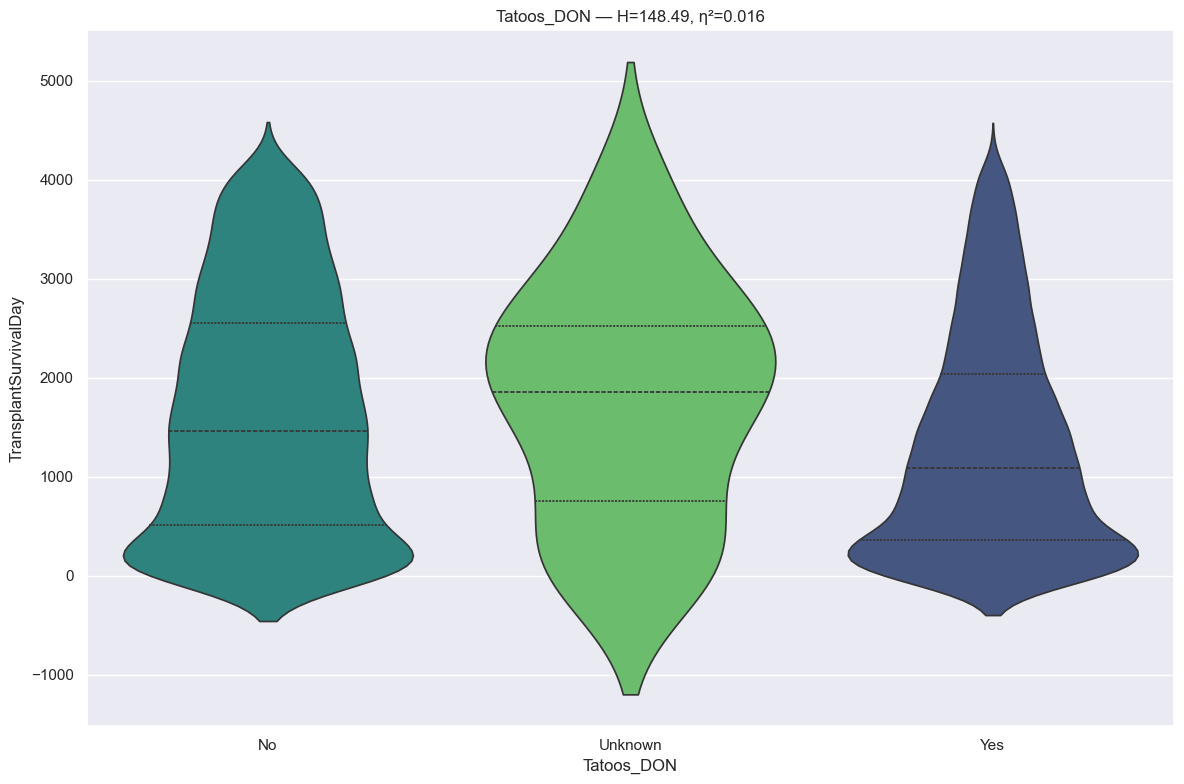

RANKING REPORT: Tatoos_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3950 records
 * Unknown                                           :     31 records
 * Yes                                               :   4952 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 148.4855 | P-value: 5.711932e-33 | Effect η²: 0.0164
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.3635e-33 | thr=0.0167 | r=-0.149 | *Sig*
Unknown      vs Yes          | p=2.4833e-02 | thr=0.0167 | r=-0.233 | Not Sig
No           vs Unknown      | p=4.2809e-01 | thr=0.0167 | r= 0.083 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 c

In [219]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [220]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antibody Result HBSAB
* A positive or reactive HBsAb (Hepatitis B surface antibody) test indicates immunity to Hepatitis B, resulting from either vaccination or recovery from a past infection. A level of 
 10 mIU/mL is typically considered protective against future infections. If negative, you may not be protected and may need to be vaccinated.

In [221]:
# info
feature = u.get_feature_info(df, 'AntibodyResultHBSAB', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique       top  freq
AntibodyResultHBSAB_DON  8933      6  Not Done  7602

:::: NaN Count:
AntibodyResultHBSAB_DON    0 



{'AntibodyResultHBSAB_DON': CategoricalDtype(categories=['Cannot Disclose', 'Indeterminate', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

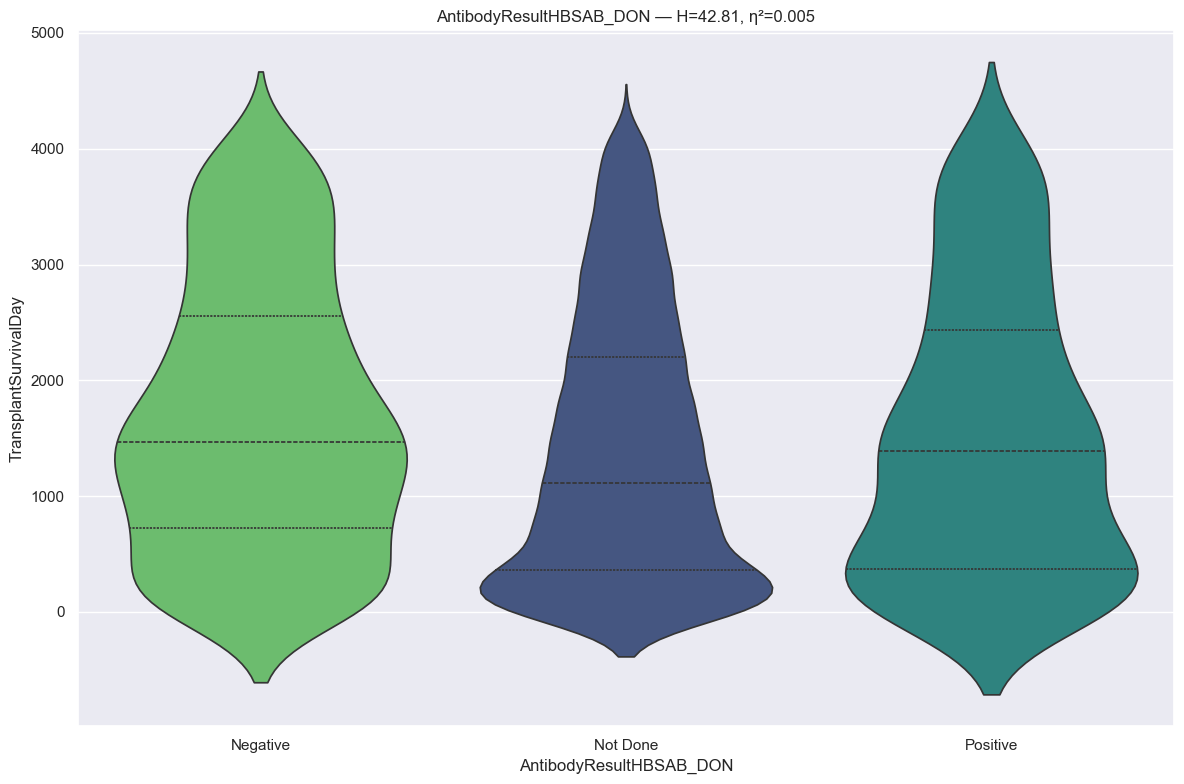

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :    833 records
 * Not Done                                          :   7602 records
 * Positive                                          :    462 records
BYPASSED CATEGORIES (n < min_n):
 * Cannot Disclose                                   :      2 records
 * Indeterminate                                     :     22 records
 * Unknown                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 42.8116 | P-value: 5.053288e-10 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=9.3151e-11 | thr=0.0167 | r=-0.137 | *Sig*
Negative     vs Positive     | p=6.7796e-03 | thr=0.0167 | r=-0.091 | *Sig*
Not Do

In [222]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [223]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :    833 records
 * Not Done                                          :   7602 records
 * Positive                                          :    462 records
BYPASSED CATEGORIES (n < min_n):
 * Cannot Disclose                                   :      2 records
 * Indeterminate                                     :     22 records
 * Unknown                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 42.8116 | P-value: 5.053288e-10 | Effect η²: 0.0046
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=9.3151e-11 | fdr_alpha=0.05 | r=-0.137 | *Sig*
Negative     vs Positive     | p=6.7796e-03 | fdr_alpha=0.05 | r=-0.091 | *Sig*

In [224]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Epstein-Barr IGG
* EBV IgG tests detect IgG-class antibodies to the Epstein-Barr virus (EBV), indicating either past infection, immunity, or recent infection, depending on the specific antigen (VCA or EBNA). Positive VCA-IgG and negative EBNA suggest recent infection, while positive EBNA-IgG usually indicates infection from months or years ago, as over 90% of adults are infected.

In [225]:
# info
feature = u.get_feature_info(df, 'EpsteinBarr_IGG', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top  freq
EpsteinBarr_IGG_DON  8933      6  Positive  8147

:::: NaN Count:
EpsteinBarr_IGG_DON    0 



{'EpsteinBarr_IGG_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

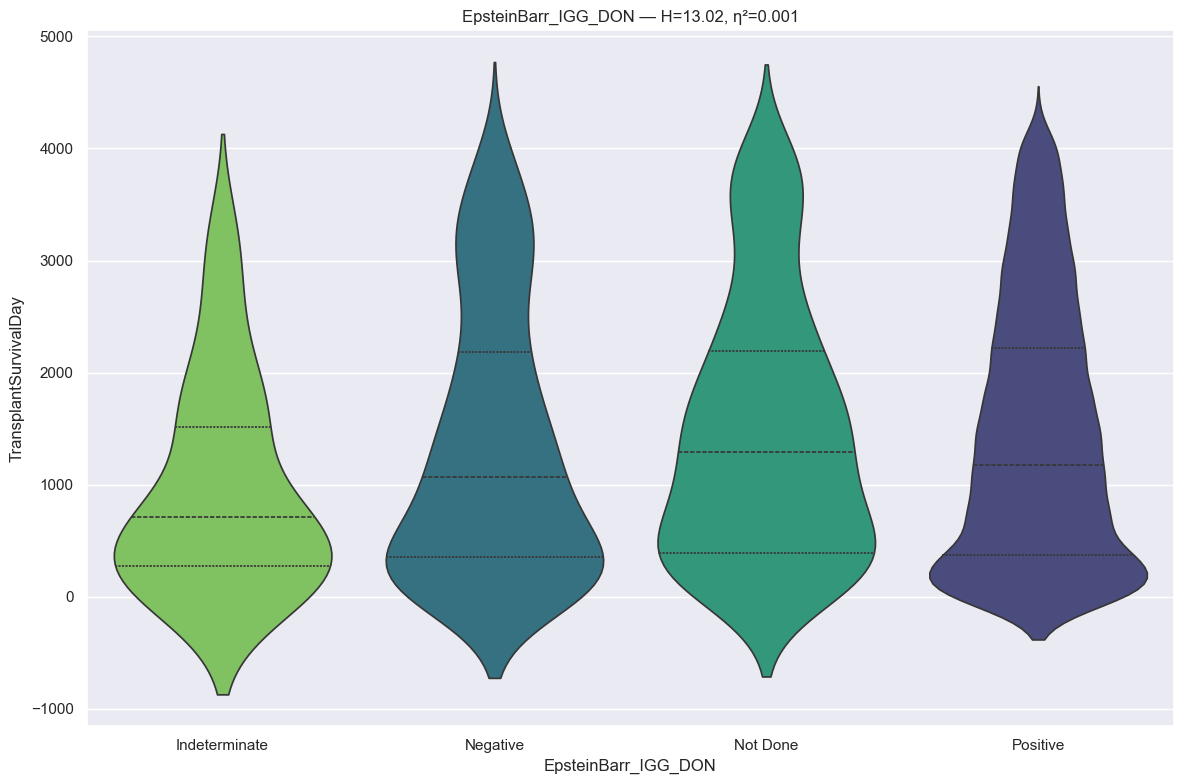

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     44 records
 * Negative                                          :    378 records
 * Not Done                                          :    356 records
 * Positive                                          :   8147 records
BYPASSED CATEGORIES (n < min_n):
 * Pending                                           :      1 records
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 13.0237 | P-value: 4.585684e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=2.0732e-03 | thr=0.0083 | r= 0.285 | *Sig*
Indeterminate vs Positive     | p=5.4107e-03 | thr=0.0083 | r= 0.243 | *Sig*
Negative

In [226]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [227]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     44 records
 * Negative                                          :    378 records
 * Not Done                                          :    356 records
 * Positive                                          :   8147 records
BYPASSED CATEGORIES (n < min_n):
 * Pending                                           :      1 records
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 13.0237 | P-value: 4.585684e-03 | Effect η²: 0.0011
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=2.0732e-03 | fdr_alpha=0.05 | r= 0.285 | *Sig*
Indeterminate vs Positive     | p=5.4107e-03 | fdr_alpha=0.05 | r= 0.243 | *Sig*
N

In [228]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Epstein-Barr IGM
* Epstein-Barr Virus (EBV) VCA IgM is a blood test detecting antibodies that appear early in an EBV infection, indicating a recent or acute primary infection. These antibodies usually disappear within 4 to 6 weeks but can last up to 3 months. A positive result often diagnoses infectious mononucleosis, which causes fatigue, fever, and swollen lymph nodes.

In [229]:
# info
feature = u.get_feature_info(df, 'EpsteinBarr_IGM', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top  freq
EpsteinBarr_IGM_DON  8933      6  Negative  7171

:::: NaN Count:
EpsteinBarr_IGM_DON    0 



{'EpsteinBarr_IGM_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

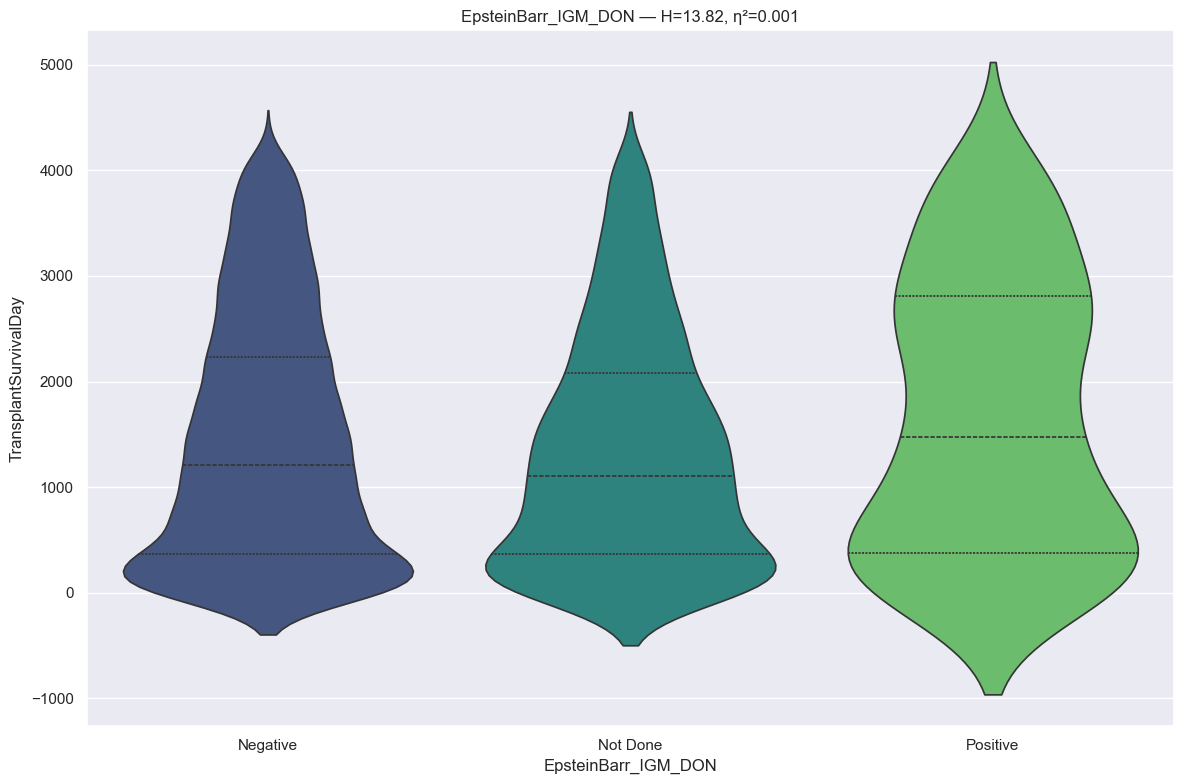

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   7171 records
 * Not Done                                          :   1580 records
 * Positive                                          :    146 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :     26 records
 * Pending                                           :      1 records
 * Unknown                                           :      9 records
--------------------------------------------------------------------------------
Kruskal H: 13.8171 | P-value: 9.991926e-04 | Effect η²: 0.0013
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=9.7724e-04 | thr=0.0167 | r=-0.053 | *Sig*
Not Done     vs Positive     | p=1.2681e-02 | thr=0.0167 | r= 0.125 | *Sig*
Negative  

In [230]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [231]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   7171 records
 * Not Done                                          :   1580 records
 * Positive                                          :    146 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :     26 records
 * Pending                                           :      1 records
 * Unknown                                           :      9 records
--------------------------------------------------------------------------------
Kruskal H: 13.8171 | P-value: 9.991926e-04 | Effect η²: 0.0013
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::

In [232]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HIV Risk

In [233]:
# info
feature = u.get_feature_info(df, 'HIV_Risk', cat=False)
# dtype
{col: df[col].dtype for col in feature}

             count unique top  freq
HIV_Risk_DON  8933      3  No  6941

:::: NaN Count:
HIV_Risk_DON    0 



{'HIV_Risk_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

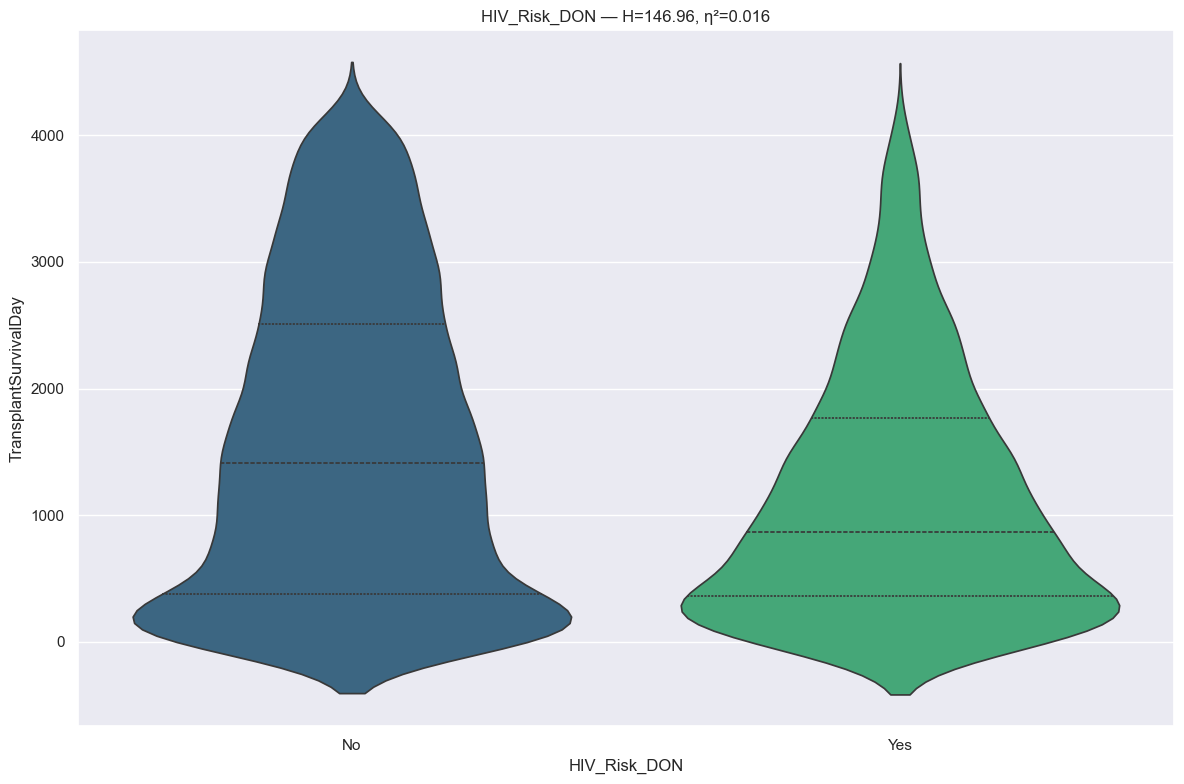

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6941 records
 * Yes                                               :   1990 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 146.9647 | P-value: 7.988160e-34 | Effect η²: 0.0163
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.9886e-34 | thr=0.0500 | r=-0.178 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

HIV_Risk_DON  mean_survival_days  median_survival_days

In [234]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [235]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Inotropic Agent

In [236]:
# info
feature = u.get_feature_info(df, 'InotropicAgent', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique      top  freq
InotropicAgent_DON  8933      7  Unknown  5267

:::: NaN Count:
InotropicAgent_DON    0 



{'InotropicAgent_DON': CategoricalDtype(categories=['Dobutamine', 'Dopamine', 'Epinephrine', 'Levophed',
                   'Neosynephrine', 'Other, specify', 'Unknown'],
 , ordered=False, categories_dtype=object)}

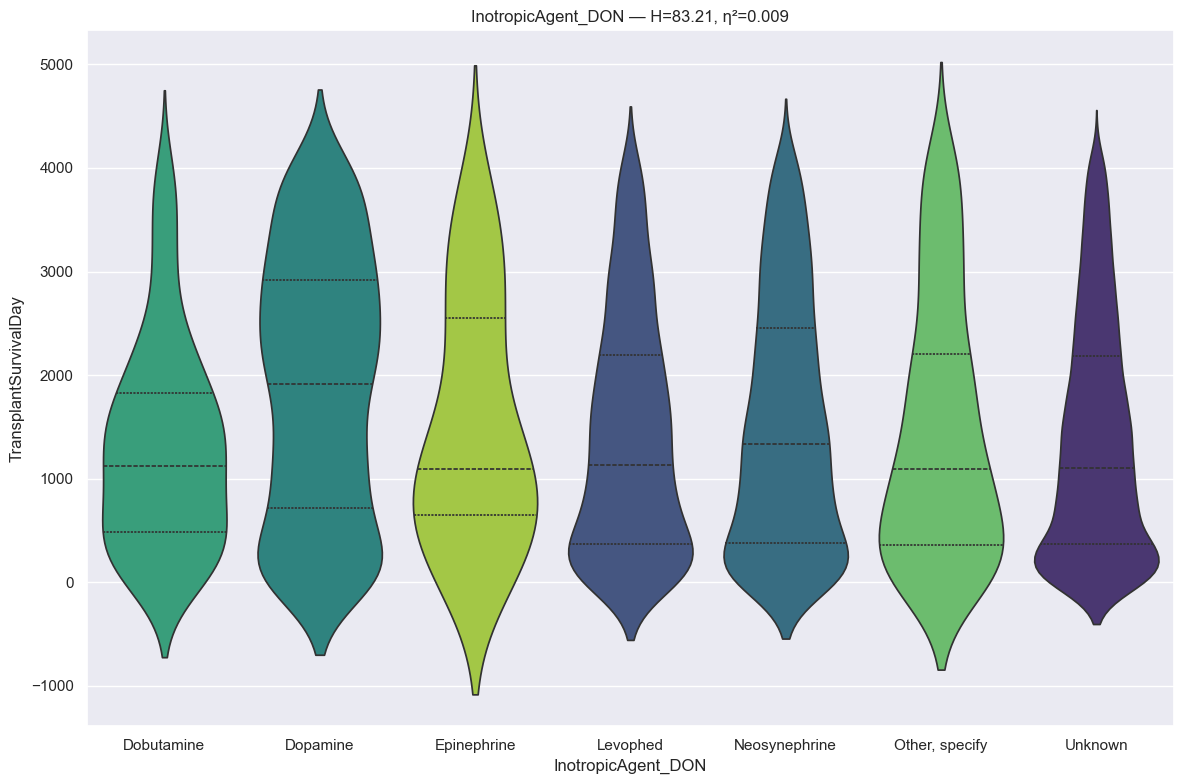

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    160 records
 * Dopamine                                          :    632 records
 * Epinephrine                                       :     39 records
 * Levophed                                          :   1094 records
 * Neosynephrine                                     :   1526 records
 * Other, specify                                    :    215 records
 * Unknown                                           :   5267 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 83.2113 | P-value: 7.745390e-16 | Effect η²: 0.0087
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Dopamine     vs Unknown      | p=6.6916e-19 | thr=0.0024 | r=-0.216 | *Sig*
Dopamine     vs Levophed

In [237]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [238]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    160 records
 * Dopamine                                          :    632 records
 * Epinephrine                                       :     39 records
 * Levophed                                          :   1094 records
 * Neosynephrine                                     :   1526 records
 * Other, specify                                    :    215 records
 * Unknown                                           :   5267 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 83.2113 | P-value: 7.745390e-16 | Effect η²: 0.0087
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::

In [239]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    160 records
 * Dopamine                                          :    632 records
 * Epinephrine                                       :     39 records
 * Levophed                                          :   1094 records
 * Neosynephrine                                     :   1526 records
 * Other, specify                                    :    215 records
 * Unknown                                           :   5267 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 83.2113 | P-value: 7.745390e-16 | Effect η²: 0.0087
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

::

In [240]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Kidney Allocation

In [241]:
# info
feature = u.get_feature_info(df, 'KidneyAllocation', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
KidneyAllocation_DON  8933      3  No  8548

:::: NaN Count:
KidneyAllocation_DON    0 



{'KidneyAllocation_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

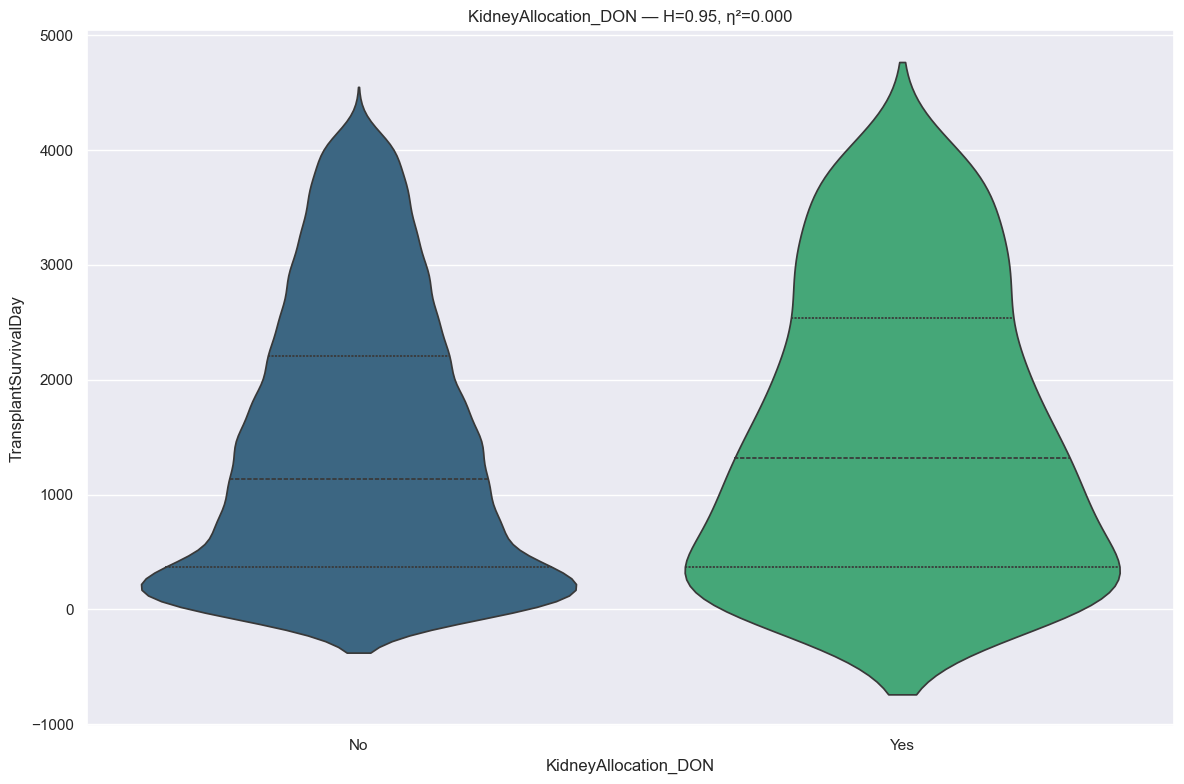

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8548 records
 * Yes                                               :    384 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 0.9472 | P-value: 3.304430e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.3045e-01 | thr=0.0500 | r= 0.029 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Unknown

KidneyAllocation_DON  mean_survival_days  median_survival_days  maximum_su

In [242]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [243]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8548 records
 * Yes                                               :    384 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 0.9472 | P-value: 3.304430e-01 | Effect η²: 0.0000
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Unknown



In [244]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is not statistically significant, and Unknown has a sample size of 1; remove the feature.

#### Inotropic Medication Procurement

In [245]:
# info
feature = u.get_feature_info(df, 'InotropicMedicationProcurement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                   count unique top  freq
InotropicMedicationProcurement_DON  8933      3  No  5234

:::: NaN Count:
InotropicMedicationProcurement_DON    0 



{'InotropicMedicationProcurement_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

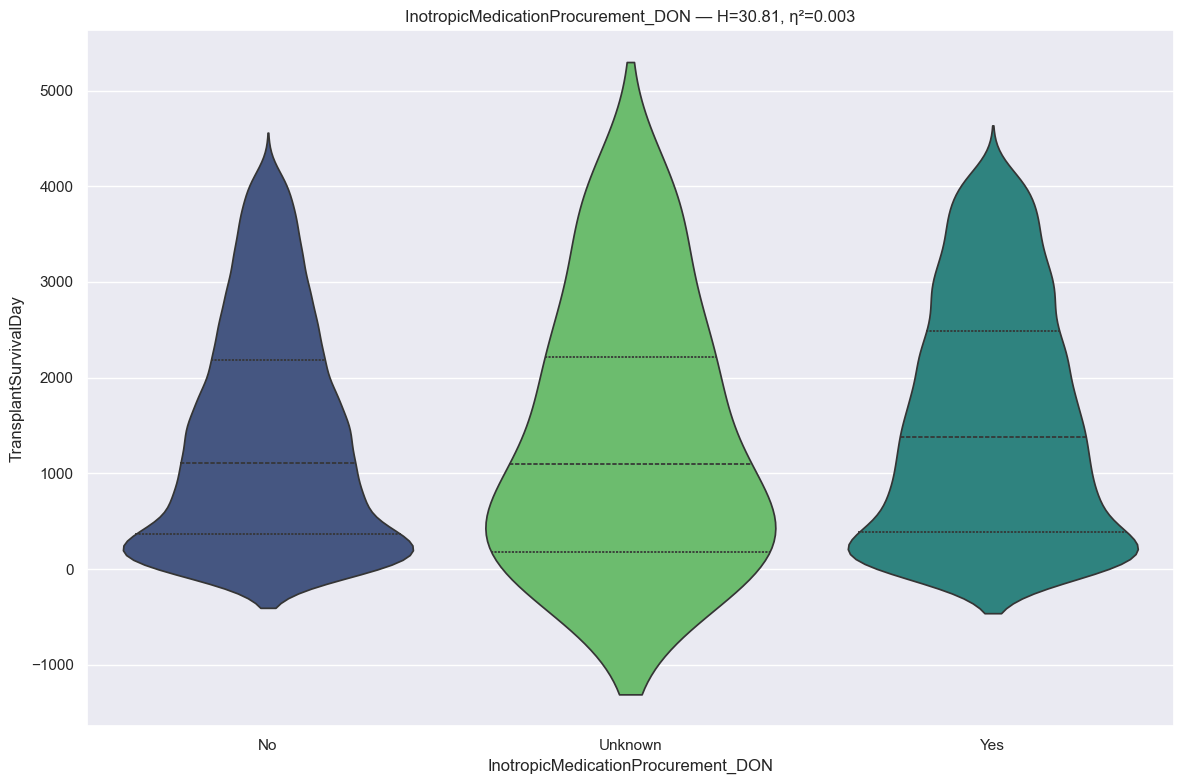

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5234 records
 * Unknown                                           :     33 records
 * Yes                                               :   3666 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 30.8070 | P-value: 2.043337e-07 | Effect η²: 0.0032
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.2793e-08 | thr=0.0167 | r= 0.069 | *Sig*
Unknown      vs Yes          | p=3.7551e-01 | thr=0.0167 | r= 0.089 | Not Sig
No           vs Unknown      | p=7.4340e-01 | thr=0.0167 | r=-0.033 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES :::::::::::::::::::::::::

In [246]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [247]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5234 records
 * Unknown                                           :     33 records
 * Yes                                               :   3666 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 30.8070 | P-value: 2.043337e-07 | Effect η²: 0.0032
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Group_2 (1 categories)
  - Yes



In [248]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5234 records
 * Unknown                                           :     33 records
 * Yes                                               :   3666 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 30.8070 | P-value: 2.043337e-07 | Effect η²: 0.0032
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Group_2 (1 categories)
  - Yes



In [249]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Transfusion Number

In [250]:
# info
feature = u.get_feature_info(df, 'TransfusionNumber', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique   top  freq
TransfusionNumber_DON  8933      5  NONE  3977

:::: NaN Count:
TransfusionNumber_DON    0 



{'TransfusionNumber_DON': CategoricalDtype(categories=['1 - 5', '6 - 10', 'GREATER THAN 10', 'NONE', 'Unknown'], ordered=False, categories_dtype=object)}

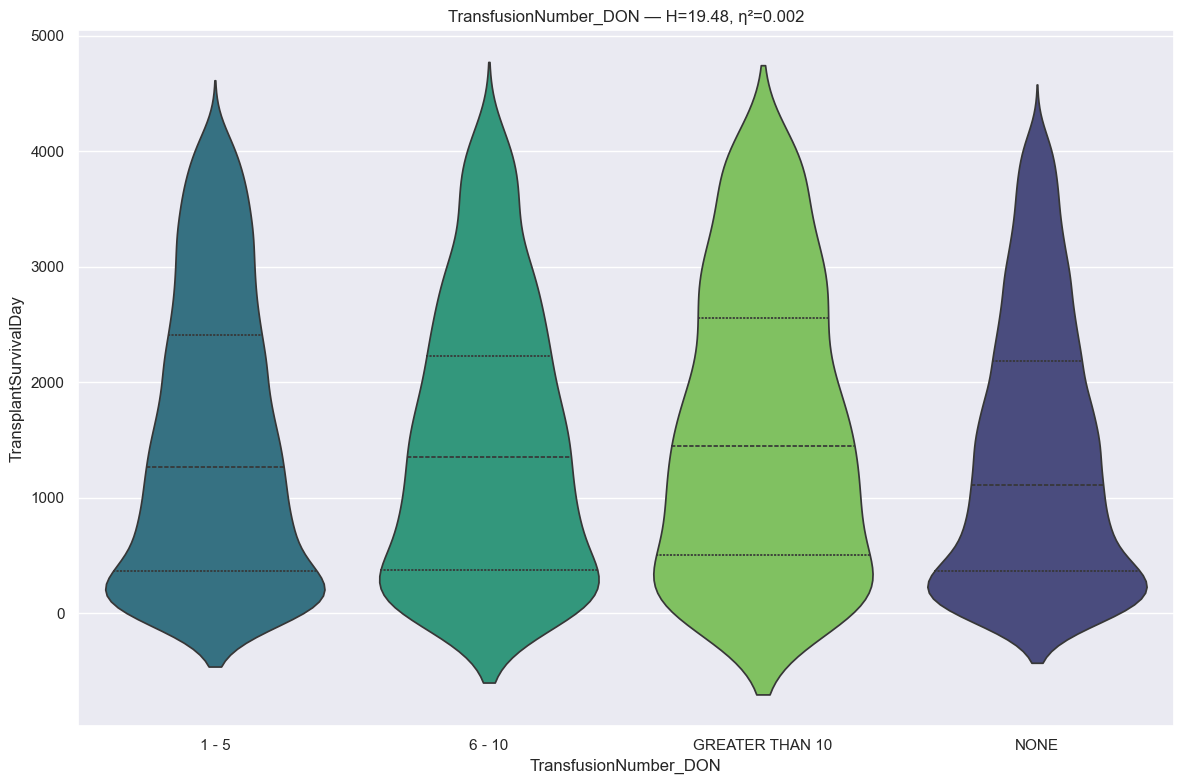

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   3612 records
 * 6 - 10                                            :    834 records
 * GREATER THAN 10                                   :    500 records
 * NONE                                              :   3977 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 19.4795 | P-value: 2.175710e-04 | Effect η²: 0.0018
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
GREATER THAN 10 vs NONE         | p=3.1842e-04 | thr=0.0083 | r=-0.099 | *Sig*
1 - 5        vs NONE         | p=1.5946e-03 | thr=0.0083 | r=-0.042 | *Sig*
6 - 10       vs NONE         | p=4.1553e-02 | thr=0.0083 | r=-0.045 | Not S

In [251]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [252]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   3612 records
 * 6 - 10                                            :    834 records
 * GREATER THAN 10                                   :    500 records
 * NONE                                              :   3977 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 19.4795 | P-value: 2.175710e-04 | Effect η²: 0.0018
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - 1 - 5
  - 6 - 10

>>>

In [253]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.04, "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   3612 records
 * 6 - 10                                            :    834 records
 * GREATER THAN 10                                   :    500 records
 * NONE                                              :   3977 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 19.4795 | P-value: 2.175710e-04 | Effect η²: 0.0018
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.04)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - 1 - 5
  - 6 - 10

>

In [254]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### LungPO2 Done

In [255]:
# info
feature = u.get_feature_info(df, 'LungPO2_Done_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique      top  freq
LungPO2_Done_DON  8933      3  Unknown  5716

:::: NaN Count:
LungPO2_Done_DON    0 



{'LungPO2_Done_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

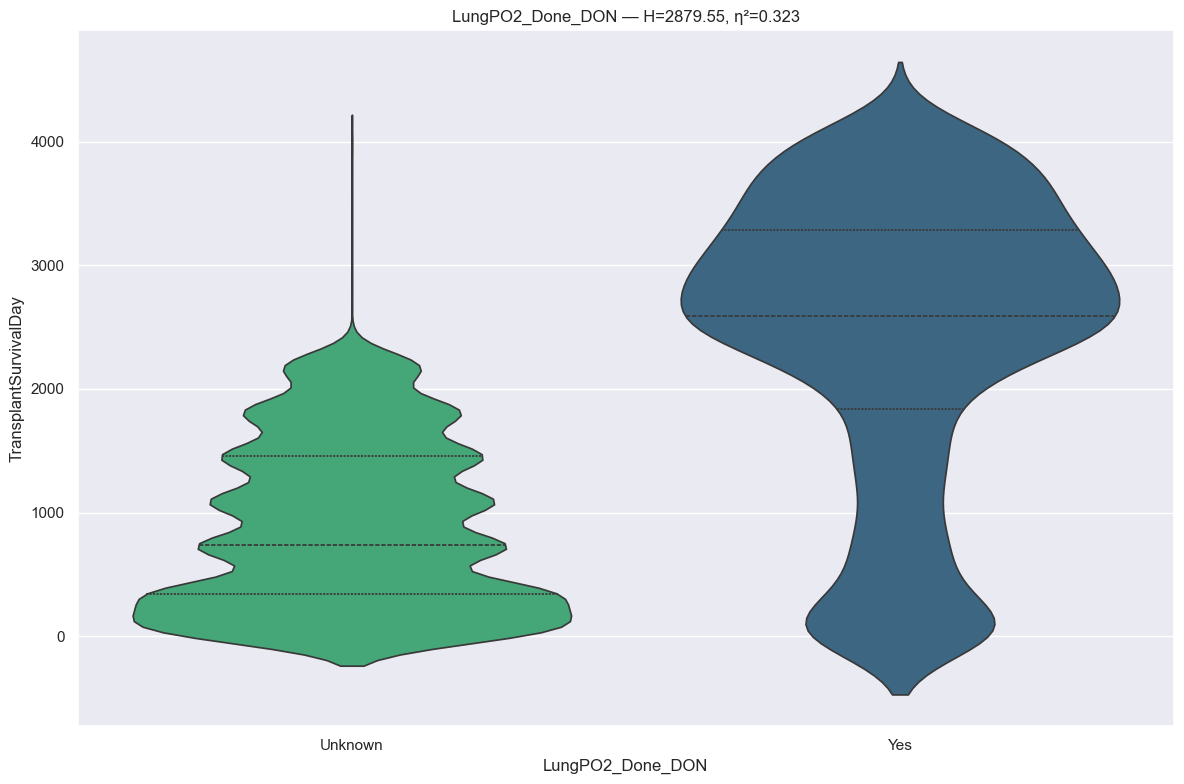

RANKING REPORT: LungPO2_Done_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Unknown                                           :   5716 records
 * Yes                                               :   3206 records
BYPASSED CATEGORIES (n < min_n):
 * No                                                :     11 records
--------------------------------------------------------------------------------
Kruskal H: 2879.5488 | P-value: 0.000000e+00 | Effect η²: 0.3227
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=0.0000e+00 | thr=0.0500 | r= 0.684 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Unknown

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - No

LungPO2_Done_DON  mean_survival_days  median_surv

In [256]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [257]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Pulmonary Catheter

In [258]:
# info
feature = u.get_feature_info(df, 'PulmonaryCatheter', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top  freq
PulmonaryCatheter_DON  8933      3  No  8243

:::: NaN Count:
PulmonaryCatheter_DON    0 



{'PulmonaryCatheter_DON': CategoricalDtype(categories=['No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

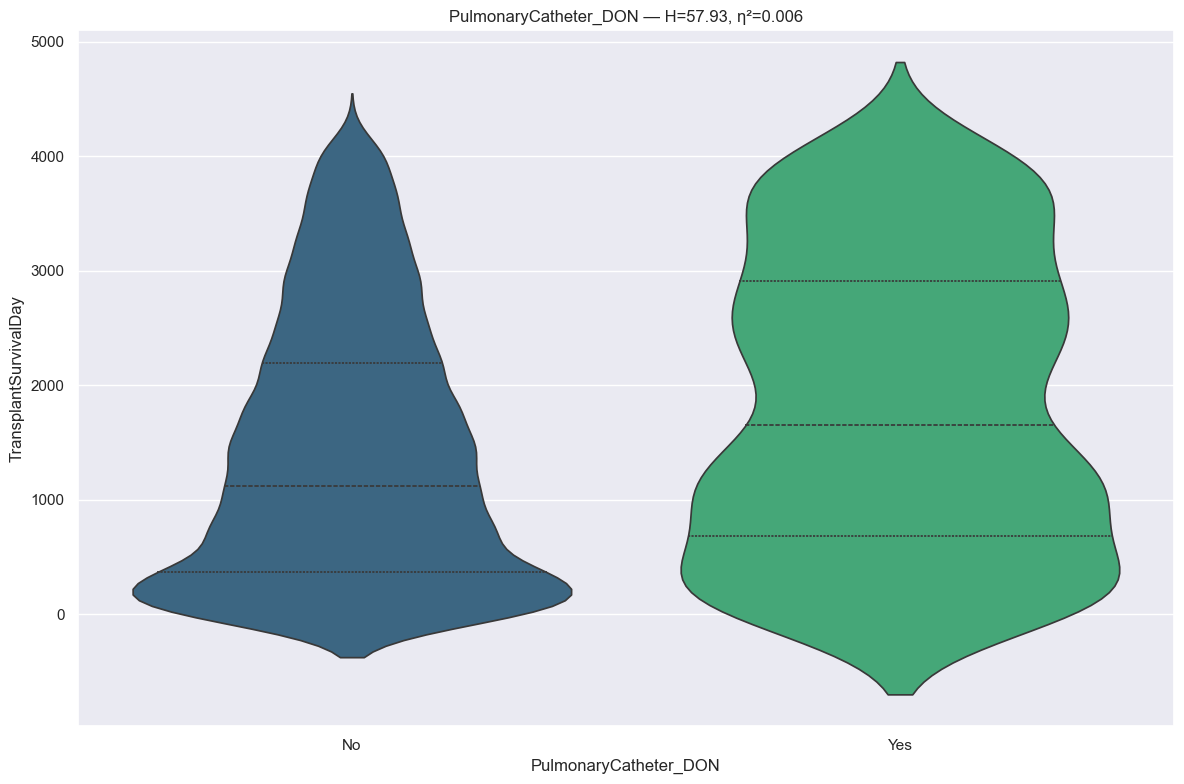

RANKING REPORT: PulmonaryCatheter_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8243 records
 * Yes                                               :    676 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 57.9305 | P-value: 2.715458e-14 | Effect η²: 0.0064
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.7156e-14 | thr=0.0500 | r= 0.176 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Unknown

PulmonaryCatheter_DON  mean_survival_days  med

In [259]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [260]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Bronchoscopy Left

In [261]:
# info
feature = u.get_feature_info(df, 'BronchoscopyLeft', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique     top  freq
BronchoscopyLeft_DON  8933      9  Unknwn  4241

:::: NaN Count:
BronchoscopyLeft_DON    0 



{'BronchoscopyLeft_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'No Bronchoscopy', 'Normal',
                   'Unknown', 'Unknown if bronchoscopy performed', 'Unknwn'],
 , ordered=False, categories_dtype=object)}

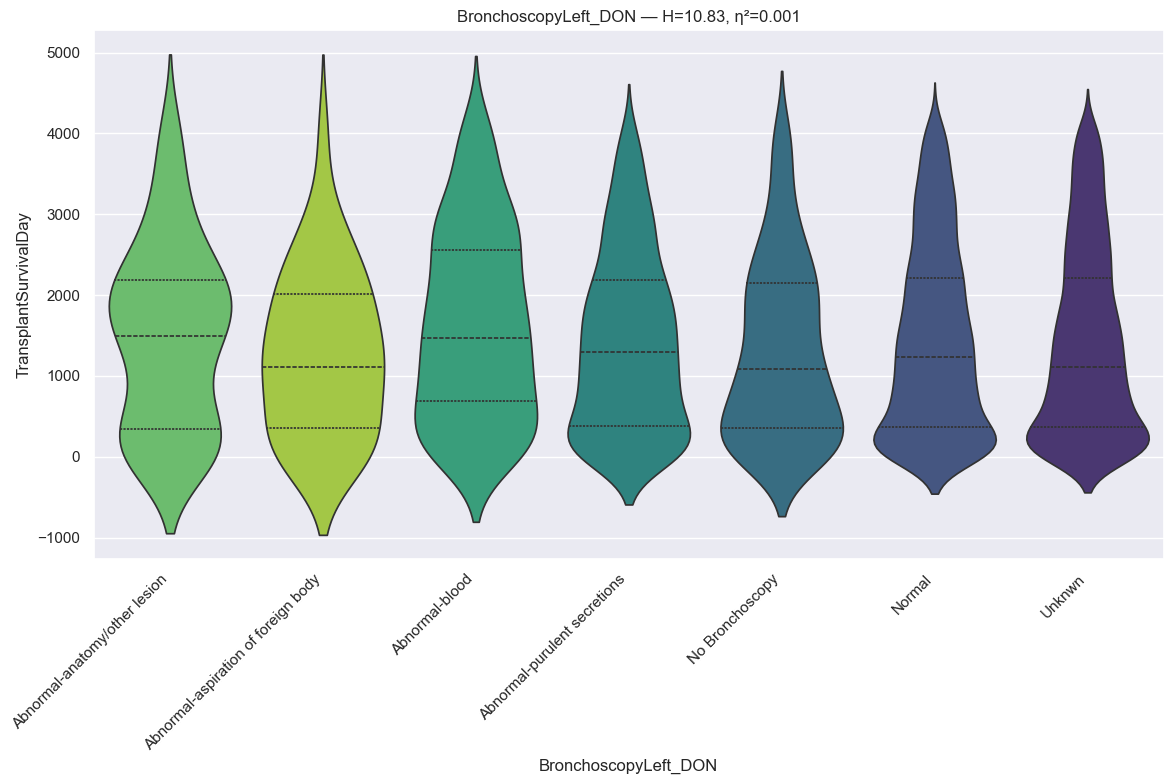

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     73 records
 * Abnormal-aspiration of foreign body               :     39 records
 * Abnormal-blood                                    :    213 records
 * Abnormal-purulent secretions                      :    706 records
 * No Bronchoscopy                                   :    238 records
 * Normal                                            :   3390 records
 * Unknwn                                            :   4241 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
 * Unknown if bronchoscopy performed                 :      5 records
--------------------------------------------------------------------------------
Kruskal H: 10.8347 | P-value: 9.362239e-02 | Effect η²: 0.0005
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [262]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [263]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, and mean survival days are non-informative except for small-sized groups. Remove the feature.

#### Bronchoscopy Right

In [264]:
# info
feature = u.get_feature_info(df, 'BronchoscopyRight', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique     top  freq
BronchoscopyRight_DON  8933      9  Unknwn  4281

:::: NaN Count:
BronchoscopyRight_DON    0 



{'BronchoscopyRight_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'No Bronchoscopy', 'Normal',
                   'Unknown', 'Unknown if bronchoscopy performed', 'Unknwn'],
 , ordered=False, categories_dtype=object)}

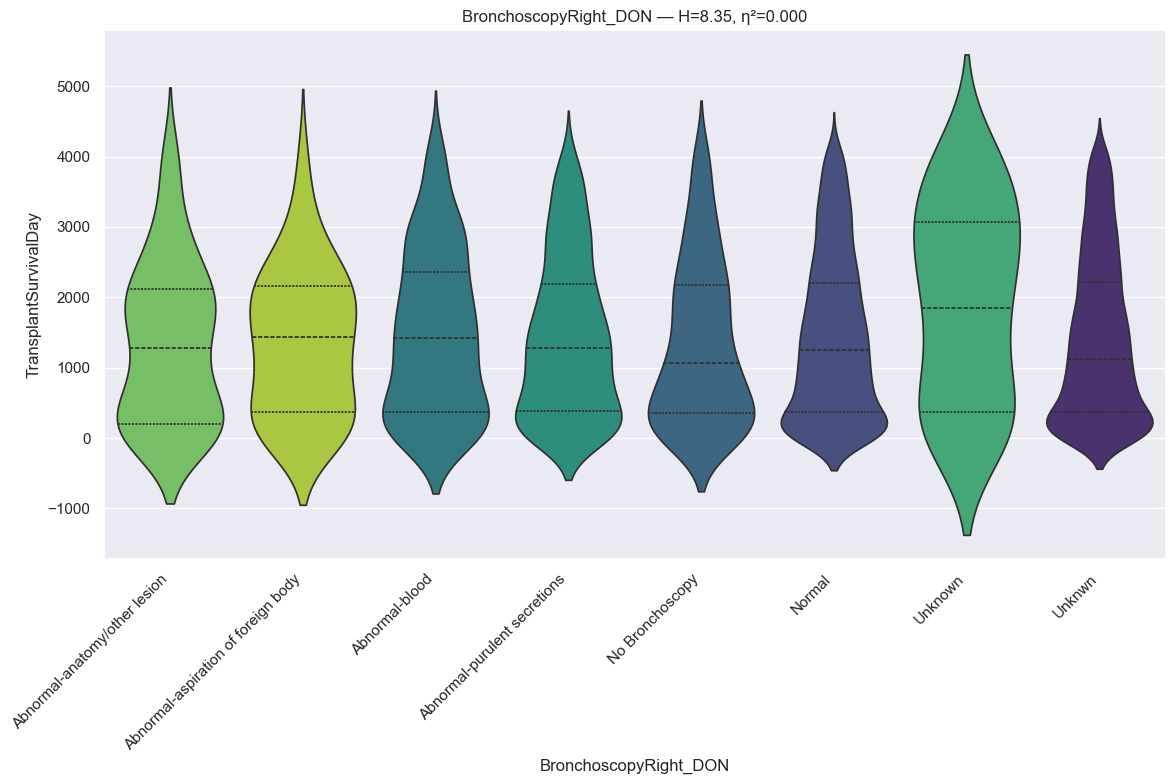

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     78 records
 * Abnormal-aspiration of foreign body               :     47 records
 * Abnormal-blood                                    :    218 records
 * Abnormal-purulent secretions                      :    775 records
 * No Bronchoscopy                                   :    250 records
 * Normal                                            :   3247 records
 * Unknown                                           :     33 records
 * Unknwn                                            :   4281 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown if bronchoscopy performed                 :      4 records
--------------------------------------------------------------------------------
Kruskal H: 8.3458 | P-value: 3.030907e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0018 | r_threshold: 0.10)
--------------------------------

In [265]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [266]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, and mean survival days are non-informative except for small-sized groups. Remove the feature.

#### Chest Xray

In [267]:
# info
feature = u.get_feature_info(df, 'ChestXray', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique            top  freq
ChestXray_DON  8933      6  Abnormal-both  4745

:::: NaN Count:
ChestXray_DON    0 



{'ChestXray_DON': CategoricalDtype(categories=['Abnormal-both', 'Abnormal-left', 'Abnormal-right',
                   'No chest x-ray', 'Normal', 'Unknown',
                   'Unknown if chest x-ray performed'],
 , ordered=False, categories_dtype=object)}

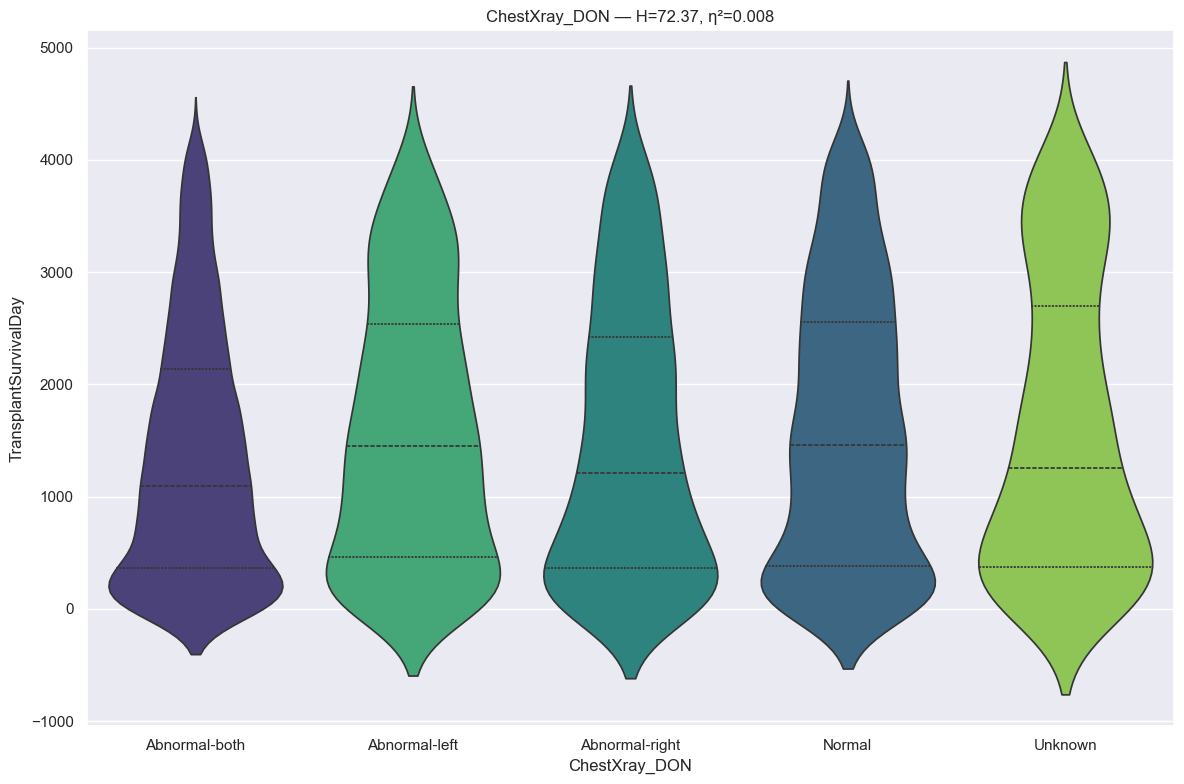

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4745 records
 * Abnormal-left                                     :    935 records
 * Abnormal-right                                    :    874 records
 * Normal                                            :   1924 records
 * Unknown                                           :    453 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :      2 records
--------------------------------------------------------------------------------
Kruskal H: 72.3666 | P-value: 7.180411e-15 | Effect η²: 0.0077
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=7.2088e-13 | thr=0.0050 | r= 0.112 | *Sig*
Abnormal-both vs Abnormal-left | p=3.9714e-08 | thr=0.0050 | r= 0.113 | *Sig*
Abnormal-both

In [268]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [269]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.04, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4745 records
 * Abnormal-left                                     :    935 records
 * Abnormal-right                                    :    874 records
 * Normal                                            :   1924 records
 * Unknown                                           :    453 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :      2 records
--------------------------------------------------------------------------------
Kruskal H: 72.3666 | P-value: 7.180411e-15 | Effect η²: 0.0077
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.04)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=7.2088e-13 | fdr_alpha=0.05 | r= 0.112 | *Sig*
Abnormal-both vs Abnormal-left | p=3.9714e-08 | fdr_alpha=0.05 | r= 0.113 | *Sig*
Abnorm

In [270]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "r_thresh": 0.05, "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4745 records
 * Abnormal-left                                     :    935 records
 * Abnormal-right                                    :    874 records
 * Normal                                            :   1924 records
 * Unknown                                           :    453 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :      2 records
--------------------------------------------------------------------------------
Kruskal H: 72.3666 | P-value: 7.180411e-15 | Effect η²: 0.0077
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=7.2088e-13 | thr=0.0050 | r= 0.112 | *Sig*
Abnormal-both vs Abnormal-left | p=3.9714e-08 | thr=0.0056 | r= 0.113 | *Sig*
Abnormal-bot

In [271]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### CrossMatchDone

In [272]:
# info
feature = u.get_feature_info(df, 'CrossMatchDone', cat=True)

               count unique  top  freq
CrossMatchDone  8933      3  Yes  8224

:::: NaN Count:
CrossMatchDone    0 

--- CrossMatchDone ---
dtype: category
Categories: ['No', 'Unknown', 'Yes']
Ordered: False



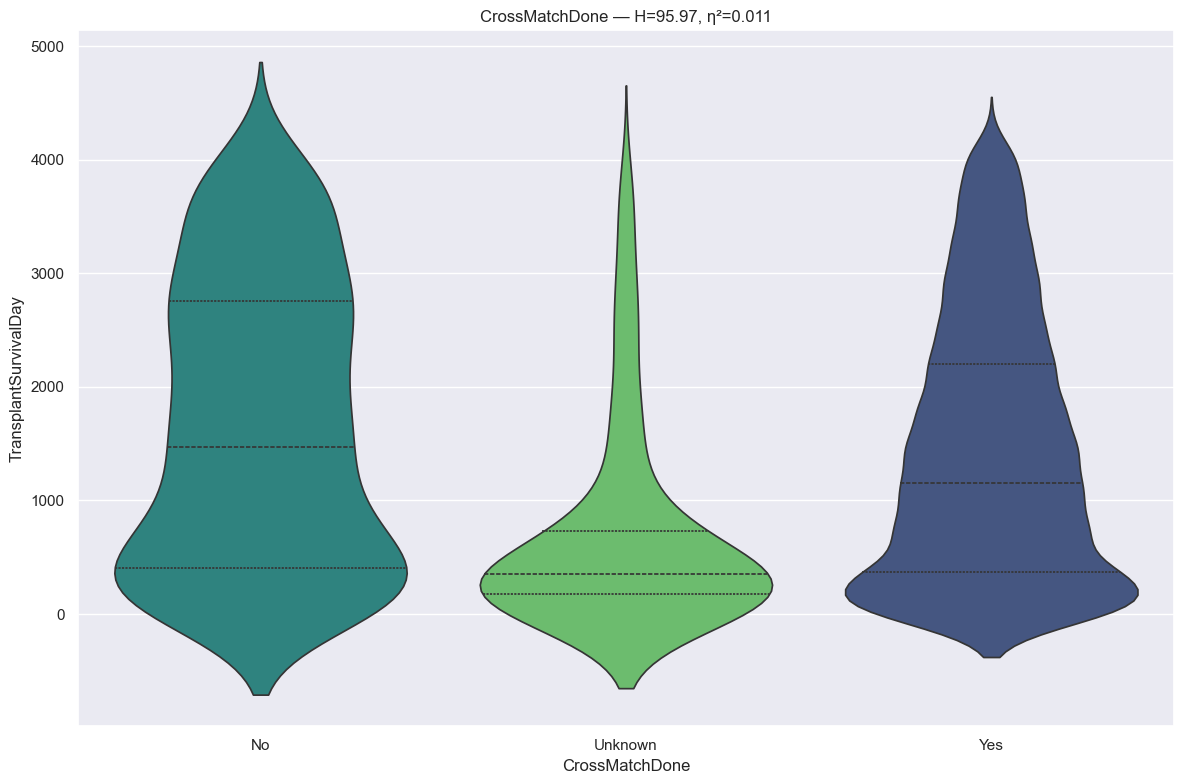

RANKING REPORT: CrossMatchDone (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    548 records
 * Unknown                                           :    161 records
 * Yes                                               :   8224 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 95.9687 | P-value: 1.447644e-21 | Effect η²: 0.0105
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=1.6832e-19 | thr=0.0167 | r= 0.415 | *Sig*
No           vs Unknown      | p=2.0825e-19 | thr=0.0167 | r=-0.467 | *Sig*
No           vs Yes          | p=2.7598e-04 | thr=0.0167 | r=-0.093 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 ca

In [273]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "min_n": 30,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [274]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### MismatchLevel_AMIS

In [275]:
# info
feature = u.get_feature_info(df, 'MismatchLevel_AMIS', cat=True)

                   count unique top  freq
MismatchLevel_AMIS  8933      4   2  4099

:::: NaN Count:
MismatchLevel_AMIS    0 

--- MismatchLevel_AMIS ---
dtype: category
Categories: ['0', '1', '2', 'Unknown']
Ordered: False



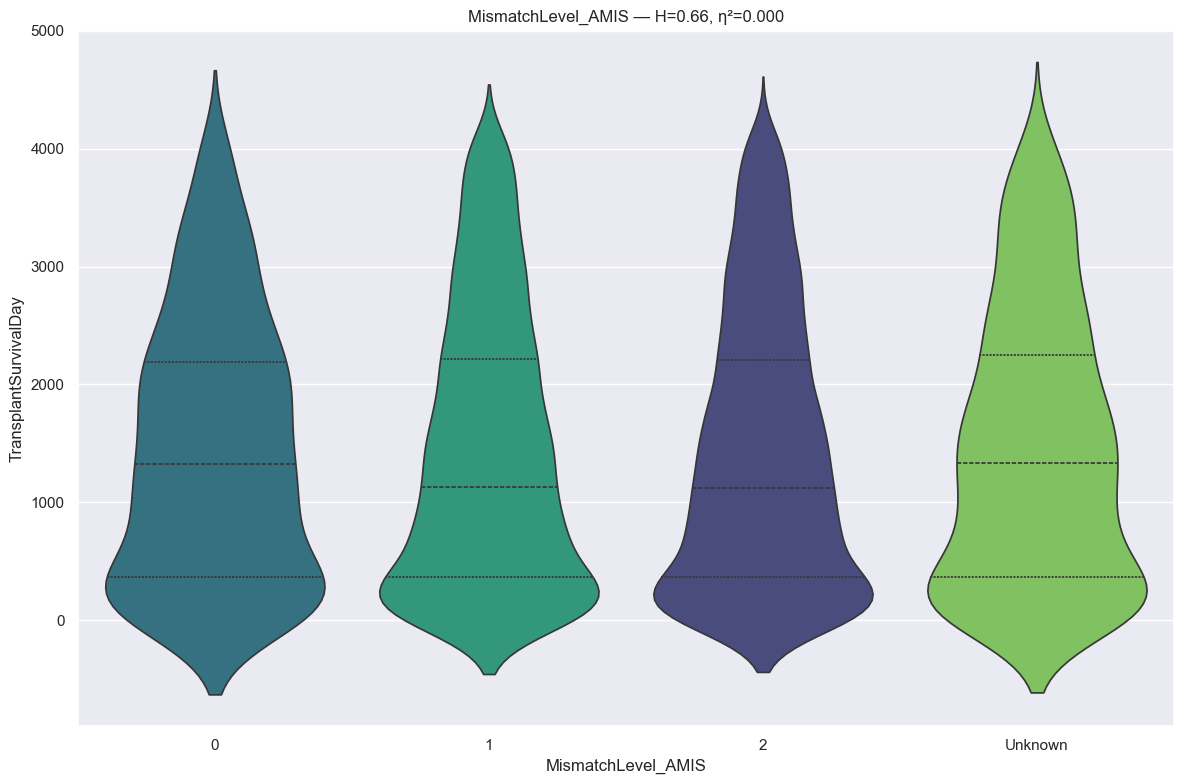

RANKING REPORT: MismatchLevel_AMIS (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :    560 records
 * 1                                                 :   3483 records
 * 2                                                 :   4099 records
 * Unknown                                           :    791 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 0.6647 | P-value: 8.814814e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
2            vs Unknown      | p=4.8465e-01 | thr=0.0083 | r= 0.016 | Not Sig
0            vs 2            | p=5.9998e-01 | thr=0.0083 | r=-0.014 | Not Sig
1            vs Unknown      | p=6.5468e-01 | thr=0.0083 | r= 0.010 | Not Sig
1            vs 2            | p=7.1392e-01 | thr=0.0083 | r=-0.005 | Not Sig

In [276]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "min_n": 30,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [277]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is not statistically significant and uninformative for survival.

#### MismatchLevel_BMIS

In [278]:
# info
feature = u.get_feature_info(df, 'MismatchLevel_BMIS', cat=True)

                   count unique top  freq
MismatchLevel_BMIS  8933      4   2  5833

:::: NaN Count:
MismatchLevel_BMIS    0 

--- MismatchLevel_BMIS ---
dtype: category
Categories: ['0', '1', '2', 'Unknown']
Ordered: False



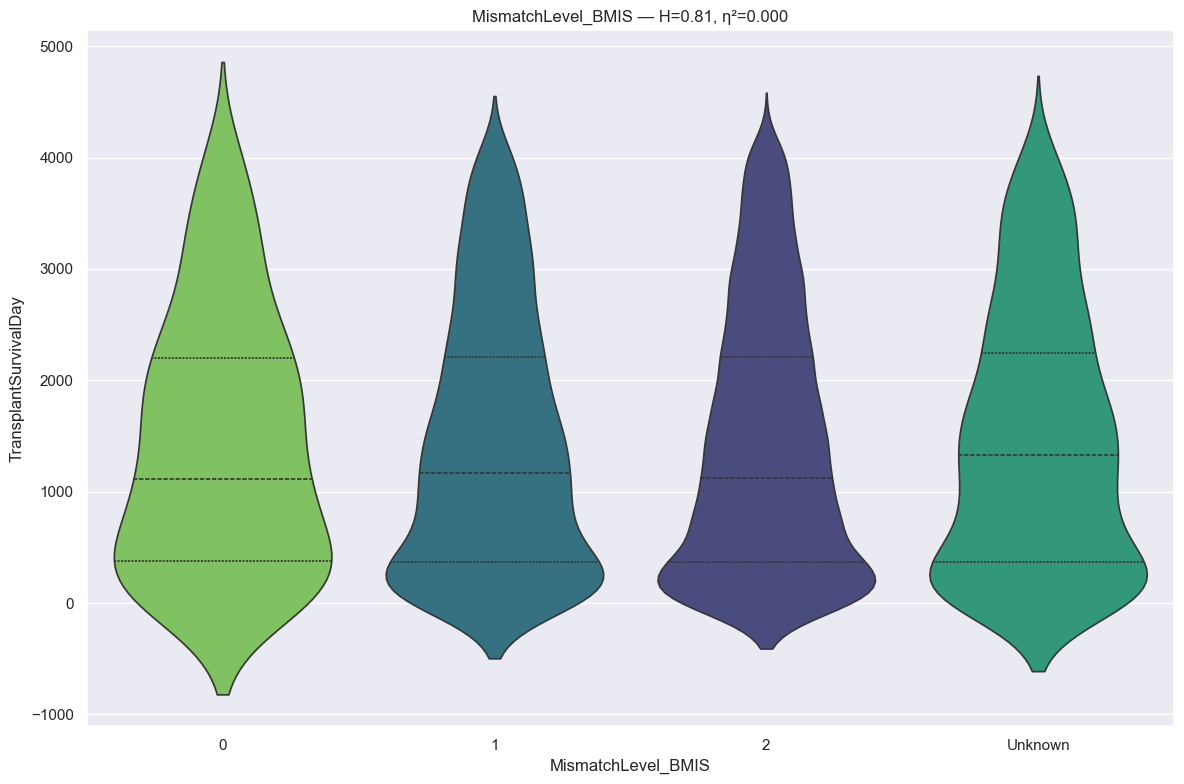

RANKING REPORT: MismatchLevel_BMIS (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :    165 records
 * 1                                                 :   2144 records
 * 2                                                 :   5833 records
 * Unknown                                           :    791 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 0.8146 | P-value: 8.459684e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
2            vs Unknown      | p=4.9246e-01 | thr=0.0083 | r= 0.015 | Not Sig
1            vs 2            | p=4.9559e-01 | thr=0.0083 | r=-0.010 | Not Sig
1            vs Unknown      | p=8.0870e-01 | thr=0.0083 | r= 0.006 | Not Sig
0            vs 2            | p=8.3322e-01 | thr=0.0083 | r=-0.010 | Not Sig

In [279]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "min_n": 30,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [280]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is not statistically significant and uninformative for survival.

#### MismatchLevel_DRMIS

In [281]:
# info
feature = u.get_feature_info(df, 'MismatchLevel_DRMIS', cat=True)

                    count unique top  freq
MismatchLevel_DRMIS  8933      4   2  4434

:::: NaN Count:
MismatchLevel_DRMIS    0 

--- MismatchLevel_DRMIS ---
dtype: category
Categories: ['0', '1', '2', 'Unknown']
Ordered: False



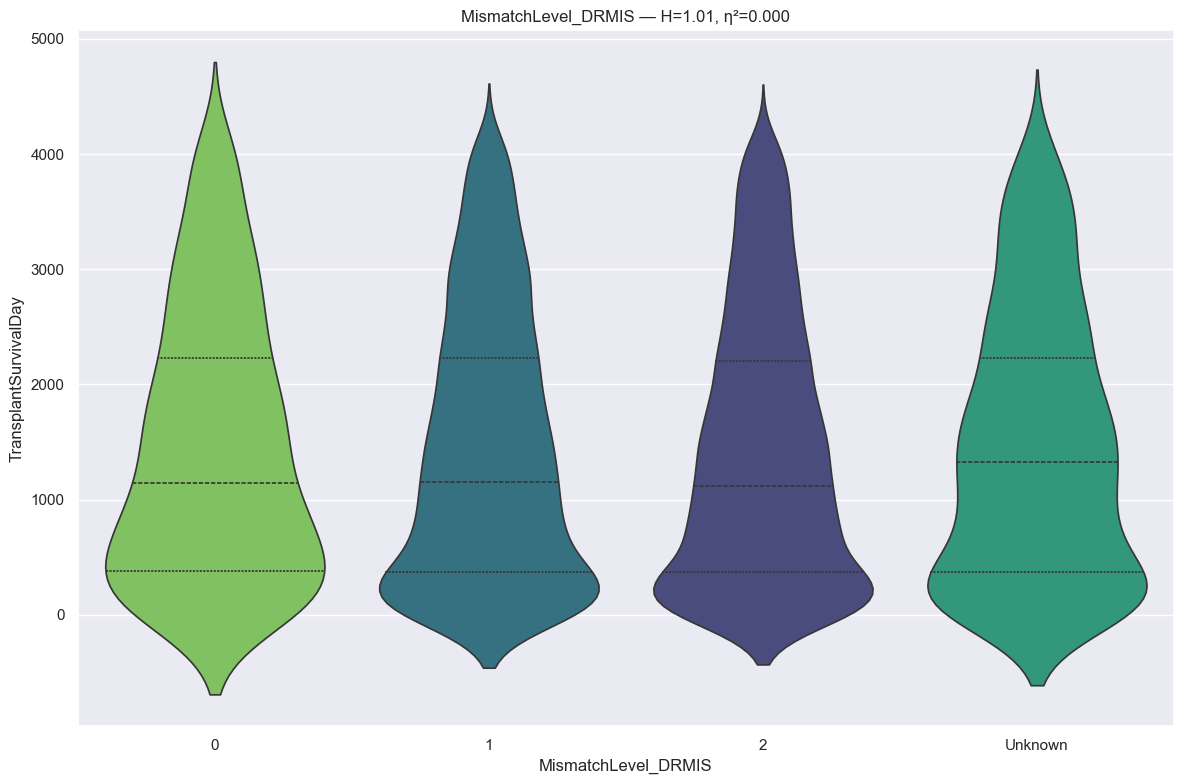

RANKING REPORT: MismatchLevel_DRMIS (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :    415 records
 * 1                                                 :   3291 records
 * 2                                                 :   4434 records
 * Unknown                                           :    793 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 1.0096 | P-value: 7.989379e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
1            vs 2            | p=4.5344e-01 | thr=0.0083 | r=-0.010 | Not Sig
2            vs Unknown      | p=4.7576e-01 | thr=0.0083 | r= 0.016 | Not Sig
0            vs 2            | p=5.7119e-01 | thr=0.0083 | r=-0.017 | Not Sig
1            vs Unknown      | p=7.9610e-01 | thr=0.0083 | r= 0.006 | Not Si

In [282]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "min_n": 30,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [283]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is not statistically significant and uninformative for survival.

#### MismatchLevel_HLAMIS

In [284]:
# info
feature = u.get_feature_info(df, 'MismatchLevel_HLAMIS', cat=True)

                     count unique top  freq
MismatchLevel_HLAMIS  8933      8   5  3005

:::: NaN Count:
MismatchLevel_HLAMIS    0 

--- MismatchLevel_HLAMIS ---
dtype: category
Categories: ['0', '1', '2', '3', '4', '5', '6', 'Unknown']
Ordered: False



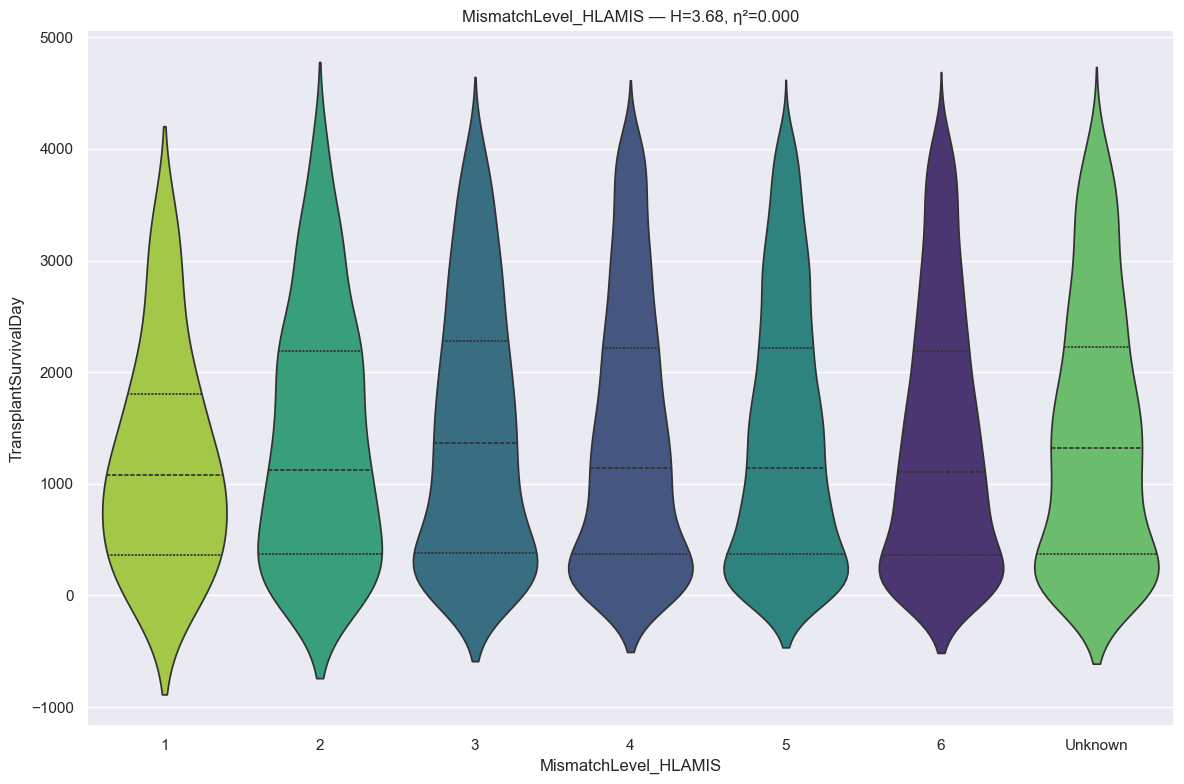

RANKING REPORT: MismatchLevel_HLAMIS (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     44 records
 * 2                                                 :    235 records
 * 3                                                 :    889 records
 * 4                                                 :   2158 records
 * 5                                                 :   3005 records
 * 6                                                 :   1801 records
 * Unknown                                           :    793 records
BYPASSED CATEGORIES (n < min_n):
 * 0                                                 :      8 records
--------------------------------------------------------------------------------
Kruskal H: 3.6770 | P-value: 7.202890e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
3            vs 6     

In [285]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "min_n": 30,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [286]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is not statistically significant and uninformative for survival only for a small sample.

#### BloodGroupMatchLevel

In [287]:
# info
feature = u.get_feature_info(df, 'BloodGroupMatchLevel', cat=True)

                     count unique        top  freq
BloodGroupMatchLevel  8933      2  Identical  7586

:::: NaN Count:
BloodGroupMatchLevel    0 

--- BloodGroupMatchLevel ---
dtype: category
Categories: ['Compatible', 'Identical', 'Incompatible']
Ordered: False



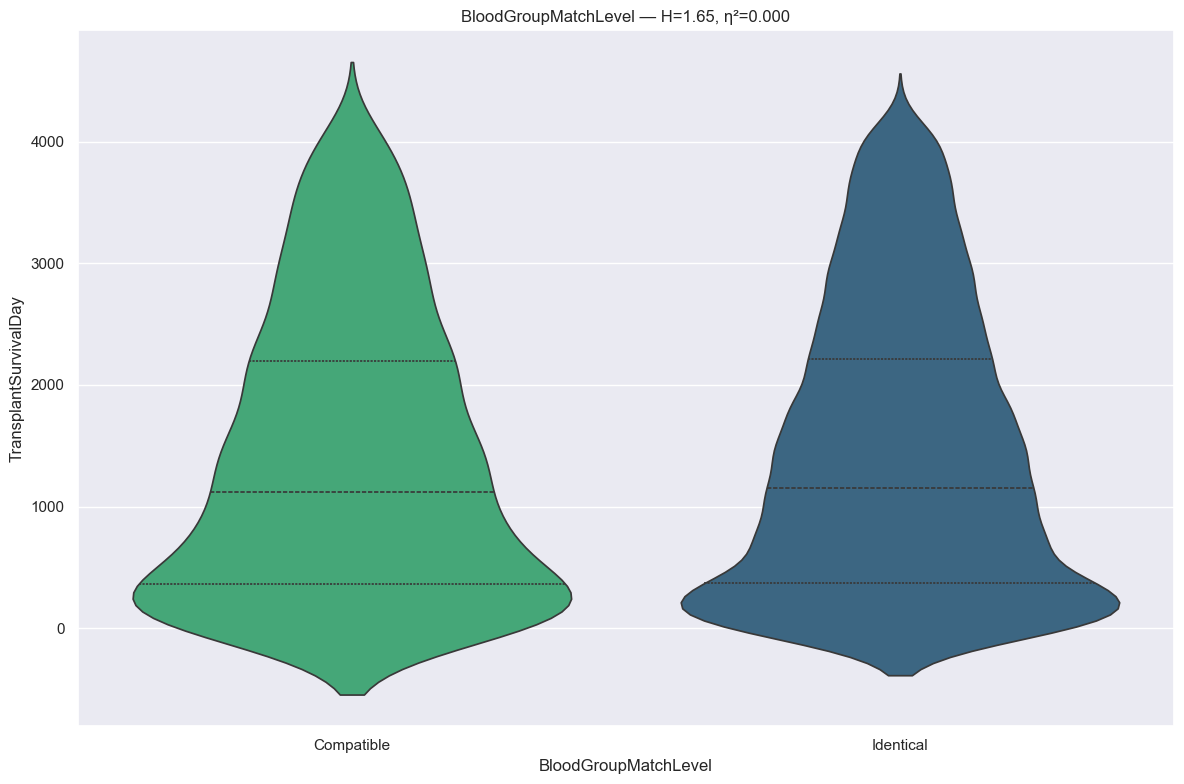

RANKING REPORT: BloodGroupMatchLevel (n ≥ 30)
INCLUDED CATEGORIES:
 * Compatible                                        :   1347 records
 * Identical                                         :   7586 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 1.6538 | P-value: 1.984449e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Compatible   vs Identical    | p=1.9845e-01 | thr=0.0500 | r= 0.022 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - Compatible
  - Identical

BloodGroupMatchLevel  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Identical         1445.689560            

In [288]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "min_n": 30,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [289]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** The feature is not statistically significant and uninformative for survival.

#### Meds_DON

In [290]:
# info
feature = u.get_feature_info(df, 'Meds', cat=False)
# dtype
{col: df[col].dtype for col in feature}

         count unique top freq
Meds_DON  8933   7679      220

:::: NaN Count:
Meds_DON    0 



{'Meds_DON': dtype('O')}

#### Clean Up

In [291]:
# add to remove list
remove_cols.extend(feature)

# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

# removed all unused categories
for col in df.select_dtypes(include="category"):
    df[col] = df[col].cat.remove_unused_categories()

# shape
print(df.shape)

# info
df.info(max_cols=df.shape[1])

(8933, 89)
<class 'pandas.core.frame.DataFrame'>
Index: 8933 entries, 3 to 30294
Data columns (total 89 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   DeceasedRetyped_DON                   8933 non-null   category
 1   AntigenDA2_DON                        8933 non-null   category
 2   AntigenDB1_DON                        8933 non-null   category
 3   AntigenDB2_DON                        8933 non-null   category
 4   AntigenDDR1_DON                       8933 non-null   category
 5   AntigenDDR2_DON                       8933 non-null   category
 6   Citizenship_DON                       8933 non-null   category
 7   PastCocaineUse_DON                    8933 non-null   category
 8   Age_DON                               8933 non-null   int64   
 9   Ethnicity_DON                         8933 non-null   category
 10  Hepatitis_B_CoreAntibody_DON          8933 non-null   category
 1

#### Write to Disk

In [292]:
# save data: heart dataset
u.write_to_file(df, 'Female_DON_Heart_PreML',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Female_DON_Heart_Mapping',path='../Data/', format='pkl')

8,933 records written to ../Data/Female_DON_Heart_PreML.pkl
56 records written to ../Data/Female_DON_Heart_Mapping.pkl
